In [6]:
print("starting!!")

starting!!


In [7]:
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
FILE_PATH_2024 = "Binance_ETHUSDT_2024_minute.csv"  # Path to your 2024 1m CSV
FILE_PATH_2025 = "Binance_ETHUSDT_2025_minute.csv"  # Path to your 2025 1m CSV

# Column Name Matching based on your exact file headers
COL_TIMESTAMP = "Date"
COL_OPEN = "Open"
COL_HIGH = "High"
COL_LOW = "Low"
COL_CLOSE = "Close"
COL_VOLUME = "Volume ETH"  # Base asset volume chosen for calculations

# Resampling Parameters
RESAMPLE_INTERVAL = "10T"  # '10T' stands for 10 Minutes

# Mathematical Constants
EPSILON = 1e-8  # Small constant to prevent division by zero
# ==============================================================================

print("Executing Phase 1: Data Loading, Cleaning, and 10-Minute Resampling...")


def load_and_clean_crypto_csv(file_path):
    # skiprows=1 skips the 'https://www.CryptoDataDownload.com' metadata line
    df = pd.read_csv(file_path, skiprows=1)

    # Reverse the dataframe layout because CryptoDataDownload typically lists newest first.
    # This guarantees chronological progression: oldest -> newest.
    df = df.iloc[::-1].reset_index(drop=True)
    return df


# 1. Load and clean both historical datasets
print(f"Loading 2024 data from: {FILE_PATH_2024}")
df_2024 = load_and_clean_crypto_csv(FILE_PATH_2024)

print(f"Loading 2025 data from: {FILE_PATH_2025}")
df_2025 = load_and_clean_crypto_csv(FILE_PATH_2025)

# 2. Append datasets chronologically
df_merged = pd.concat([df_2024, df_2025], axis=0, ignore_index=True)
print(f"Merged raw shape: {df_merged.shape}")

# 3. Set the 'Date' timestamp column as the index
df_merged[COL_TIMESTAMP] = pd.to_datetime(df_merged[COL_TIMESTAMP])
df_merged = df_merged.sort_values(by=COL_TIMESTAMP).reset_index(drop=True)
df_merged.set_index(COL_TIMESTAMP, inplace=True)

# 4. Strip out string features to allow numeric math interpolation
keep_cols = [COL_OPEN, COL_HIGH, COL_LOW, COL_CLOSE, COL_VOLUME]
df_merged = df_merged[keep_cols]
df_merged = df_merged.apply(pd.to_numeric, errors="coerce")
df_merged = df_merged.ffill().bfill()

# 5. Resample from 1-minute to 10-minute bars
print(f"Resampling 1-minute data into {RESAMPLE_INTERVAL} bars...")
resample_dict = {
    COL_OPEN: "first",
    COL_HIGH: "max",
    COL_LOW: "min",
    COL_CLOSE: "last",
    COL_VOLUME: "sum",
}
df_resampled = df_merged.resample(RESAMPLE_INTERVAL).agg(resample_dict)

# Drop any interval gaps containing zero volume or NaN values
df_resampled = df_resampled.dropna()
print(f"Resampled dataset shape: {df_resampled.shape}")

# Shortcut references
O = df_resampled[COL_OPEN]
H = df_resampled[COL_HIGH]
L = df_resampled[COL_LOW]
C = df_resampled[COL_CLOSE]
V = df_resampled[COL_VOLUME]

# 6. Feature Engineering (Strictly Internal Indicators)
print("Calculating internal features...")
df_features = pd.DataFrame(index=df_resampled.index)

# Feature 1: Log Returns
df_features["log_returns"] = np.log(C / C.shift(1))

# Feature 2: Garman-Klass Volatility
df_features["garman_klass"] = 0.5 * (np.log(H / L) ** 2) - (
    2 * np.log(2) - 1
) * (np.log(C / O) ** 2)

# Feature 3: Log Range
df_features["log_range"] = np.log(H / L)

# Feature 4: Volume Change
df_features["volume_change"] = np.log(V / V.shift(1))

# Feature 5: Close-Open Gap
df_features["close_open_gap"] = np.log(C / O)

# Feature 6: Normalized Close Position
df_features["norm_close_pos"] = (C - L) / (H - L + EPSILON)

# 7. Target Vector Creation (Next Period's Garman-Klass Volatility)
df_features["target_volatility"] = df_features["garman_klass"].shift(-1)

# Drop first row due to shifts, and last row due to target alignment look-ahead
df_features = df_features.dropna()

print("\n--- PHASE 1 SUCCESSFUL ---")
print(f"Final Preprocessed Feature Dataframe Shape: {df_features.shape}")
print("\nChronologically Sorted Feature Matrix Preview (Oldest to Newest):")
print(df_features.head())

Executing Phase 1: Data Loading, Cleaning, and 10-Minute Resampling...
Loading 2024 data from: Binance_ETHUSDT_2024_minute.csv
Loading 2025 data from: Binance_ETHUSDT_2025_minute.csv
Merged raw shape: (1068168, 10)
Resampling 1-minute data into 10T bars...


C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\2265536218.py:69: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_merged.resample(RESAMPLE_INTERVAL).agg(resample_dict)


Resampled dataset shape: (106818, 5)
Calculating internal features...

--- PHASE 1 SUCCESSFUL ---
Final Preprocessed Feature Dataframe Shape: (106816, 7)

Chronologically Sorted Feature Matrix Preview (Oldest to Newest):
                     log_returns  garman_klass  log_range  volume_change  \
Date                                                                       
2024-01-01 00:10:00     0.000694      0.000004   0.002720       0.059398   
2024-01-01 00:20:00    -0.000572      0.000004   0.003014      -0.413177   
2024-01-01 00:30:00     0.001265      0.000002   0.002361      -0.099872   
2024-01-01 00:40:00    -0.000746      0.000001   0.001679      -0.521211   
2024-01-01 00:50:00     0.001426      0.000002   0.002153       0.122158   

                     close_open_gap  norm_close_pos  target_volatility  
Date                                                                    
2024-01-01 00:10:00        0.000694        0.256410       4.414657e-06  
2024-01-01 00:20:00       -

In [8]:
import numpy as np
import pandas as pd
import pywt

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
WINDOW_SIZE = 32           # The final timeline length (m) passed to your GAF/LSTM
WAVELET_NAME = "db4"       # Daubechies 4 wavelet specification
DECOMP_LEVEL = 1          # Level 1 decomposition

FEATURE_COLUMNS = [
    "log_returns", 
    "garman_klass", 
    "log_range", 
    "volume_change", 
    "close_open_gap", 
    "norm_close_pos"
]
# ==============================================================================

print(f"Executing Phase 2: Boundary-Truncated Causal MODWT using {WAVELET_NAME}...")

# 1. Calculate the exact filter length of the chosen mother wavelet
wavelet = pywt.Wavelet(WAVELET_NAME)
filter_length = wavelet.dec_len  # For 'db4', this equals 8

# The expanded window pulls extra history to absorb edge padding distortion
EXPANDED_WINDOW = WINDOW_SIZE + filter_length

raw_features_matrix = df_features[FEATURE_COLUMNS].values
total_rows = len(df_features)

# Initialize 3D tensors for storage (Shape: Samples, Window Size, 6 Features)
approx_storage = np.zeros((total_rows, WINDOW_SIZE, len(FEATURE_COLUMNS)))
detail_storage = np.zeros((total_rows, WINDOW_SIZE, len(FEATURE_COLUMNS)))
valid_indices_mask = []

print(f"Running causal truncation loop over {total_rows} intervals...")

for idx in range(total_rows):
    # Ensure we have enough deep history to fulfill the expanded window requirement
    if idx < (EXPANDED_WINDOW - 1):
        valid_indices_mask.append(False)
        continue
        
    valid_indices_mask.append(True)
    
    # Extract the expanded window up to current time t (Strictly causal)
    expanded_slice = raw_features_matrix[idx - EXPANDED_WINDOW + 1 : idx + 1, :]
    
    for feat_idx in range(len(FEATURE_COLUMNS)):
        signal_series = expanded_slice[:, feat_idx]
        
        # Compute Stationary Wavelet Transform (MODWT equivalent) on expanded data
        coeffs = pywt.swt(signal_series, wavelet=WAVELET_NAME, level=DECOMP_LEVEL, norm=True)
        cA1, cD1 = coeffs[0]
        
        # CRUCIAL TRUNCATION STEP: Discard the first 'filter_length' coefficients 
        # which absorbed the padding distortion. Keep only the final 'WINDOW_SIZE' elements.
        approx_storage[idx, :, feat_idx] = cA1[filter_length:]
        detail_storage[idx, :, feat_idx] = cD1[filter_length:]

# Filter arrays to contain only valid, fully completed historical windows
approx_final = approx_storage[valid_indices_mask]
detail_final = detail_storage[valid_indices_mask]

# Synchronize raw data streams and targets to match the identical validation indices
df_filtered_context = df_features.iloc[valid_indices_mask]
raw_sequences_final = df_filtered_context[FEATURE_COLUMNS].values
targets_final = df_filtered_context["target_volatility"].values

print("\n--- PHASE 2 SUCCESSFUL (LOOK-AHEAD & BOUNDARY DEFENDED) ---")
print(f"Final Clean Approximation Array (A): {approx_final.shape}")
print(f"Final Clean Detail Array (D)     : {detail_final.shape}")
print(f"Aligned Prediction Target Matrix   : {targets_final.shape}")

Executing Phase 2: Boundary-Truncated Causal MODWT using db4...
Running causal truncation loop over 106816 intervals...

--- PHASE 2 SUCCESSFUL (LOOK-AHEAD & BOUNDARY DEFENDED) ---
Final Clean Approximation Array (A): (106777, 32, 6)
Final Clean Detail Array (D)     : (106777, 32, 6)
Aligned Prediction Target Matrix   : (106777,)


In [9]:
import numpy as np

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
# Bounding constraints for MinMax scaling to protect the arccos operation
MIN_BOUND = -0.999999
MAX_BOUND = 0.999999
# ==============================================================================

print("Executing Phase 3: Vectorized 12-Channel GASF Generation & Tensor Assembly...")

def compute_vectorized_gasf(tensor_3d):
    """
    Takes a 3D array of shape (Samples, Window, Features)
    Normalizes features to [-1, 1], computes angular fields,
    and returns an image tensor of shape (Samples, Window, Window, Features)
    """
    n_samples, n_window, n_features = tensor_3d.shape
    
    # 1. MinMax Scale each feature inside its localized window slice to [-1, 1]
    # We find min/max along the window axis (axis=1) for each sample and feature
    min_vals = tensor_3d.min(axis=1, keepdims=True)
    max_vals = tensor_3d.max(axis=1, keepdims=True)
    
    # Avoid division by zero for completely flat features
    denom = max_vals - min_vals
    denom[denom == 0] = 1.0
    
    # Scale and strictly clip to [MIN_BOUND, MAX_BOUND] to avoid arccos numerical errors
    scaled_tensor = -1.0 + 2.0 * ((tensor_3d - min_vals) / denom)
    scaled_tensor = np.clip(scaled_tensor, MIN_BOUND, MAX_BOUND)
    
    # 2. Compute polar coordinate mapping: phi = arccos(x)
    phi = np.arccos(scaled_tensor)  # Shape: (Samples, Window, Features)
    
    # 3. Vectorized GASF calculation using matrix broadcasting: cos(phi_i + phi_j)
    # We expand dimensions to let numpy broadcast a cross-product matrix for the window
    # phi_i shape: (Samples, Window, 1, Features)
    # phi_j shape: (Samples, 1, Window, Features)
    phi_i = np.expand_dims(phi, axis=2)
    phi_j = np.expand_dims(phi, axis=1)
    
    # Broadcasted summation field across the spatial grid
    gasf_matrices = np.cos(phi_i + phi_j)  # Shape: (Samples, Window, Window, Features)
    
    return gasf_matrices

print("Processing GASF matrices for Smooth Approximation group (Channels 1-6)...")
gasf_approx = compute_vectorized_gasf(approx_final)

print("Processing GASF matrices for Textured Detail group (Channels 7-12)...")
gasf_detail = compute_vectorized_gasf(detail_final)

# 4. Deep Spatial Channel Stacking
print("Stacking channels into the final multi-spectral image tensor...")
# We concatenate along axis=3 (the feature/channel axis)
# Resulting shape: (Samples, Window, Window, 12)
gaf_input_tensor = np.concatenate([gasf_approx, gasf_detail], axis=3)

print("\n--- PHASE 3 SUCCESSFUL ---")
print(f"Final 12-Channel GAF Input Tensor Shape: {gaf_input_tensor.shape} -> (Samples, Width, Height, Channels)")
print(f"Memory Verification: Tensor Data Type is {gaf_input_tensor.dtype}")

Executing Phase 3: Vectorized 12-Channel GASF Generation & Tensor Assembly...
Processing GASF matrices for Smooth Approximation group (Channels 1-6)...
Processing GASF matrices for Textured Detail group (Channels 7-12)...
Stacking channels into the final multi-spectral image tensor...

--- PHASE 3 SUCCESSFUL ---
Final 12-Channel GAF Input Tensor Shape: (106777, 32, 32, 12) -> (Samples, Width, Height, Channels)
Memory Verification: Tensor Data Type is float64


In [10]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
BATCH_SIZE = 64            # Number of samples per training batch
VALIDATION_SPLIT = 0.2     # 20% of data reserved for sequential validation
# ==============================================================================

print("Executing Phase 4: Chronological Splitting & Leak-Proof Dual-Stream Construction...")

# Extract foundational dimensions from Phase 2 arrays
total_samples, n_window, n_features = approx_final.shape

# 1. Enforce Strict Chronological Split on the final 3D GAF and Target arrays
split_idx = int(total_samples * (1.0 - VALIDATION_SPLIT))

X_gaf_train, X_gaf_val = gaf_input_tensor[:split_idx], gaf_input_tensor[split_idx:]
y_train, y_val = targets_final[:split_idx], targets_final[split_idx:]

print(f"Data split chronologically at index: {split_idx}")
print(f"Training Set GAF Samples  : {X_gaf_train.shape[0]}")
print(f"Validation Set GAF Samples: {X_gaf_val.shape[0]}")


# 2. Extract and Scale Continuous Time-Series History without Leakage
# To build lookback windows for the LSTM, we need the continuous un-windowed features
raw_continuous_features = df_features[FEATURE_COLUMNS].values

# Find the exact boundary row in the original dataframe that matches our split_idx
# We add (EXPANDED_WINDOW - 1) because approx_final truncated the beginning of df_features
wavelet_filter_offset = (WINDOW_SIZE + wavelet.dec_len) - 1
global_split_boundary = split_idx + wavelet_filter_offset

# Split continuous data into Train and Val BEFORE fitting the scaler
raw_continuous_train = raw_continuous_features[:global_split_boundary]
raw_continuous_val = raw_continuous_features[global_split_boundary - n_window:] # include a window buffer for lookback

print("\nFitting Standard Scaler strictly on continuous training set history...")
scaler = StandardScaler()
scaled_continuous_train = scaler.fit_transform(raw_continuous_train)

# Transform validation data using training weights
scaled_continuous_val = scaler.transform(raw_continuous_val)


# 3. Causal Reconstruct of 3D Temporal Windows for Branch B (LSTM Input)
print("Reconstructing clean, leak-proof 3D windows for the LSTM branch...")
X_lstm_train = np.zeros((len(X_gaf_train), n_window, n_features))
X_lstm_val = np.zeros((len(X_gaf_val), n_window, n_features))

# Build training windows using a historical lookback window
for i in range(len(X_gaf_train)):
    # The corresponding index in scaled_continuous_train must account for the initial wavelet offset
    global_idx = i + wavelet_filter_offset
    X_lstm_train[i] = scaled_continuous_train[global_idx - n_window + 1 : global_idx + 1]

# Build validation windows using a historical lookback window
for i in range(len(X_gaf_val)):
    # Because scaled_continuous_val starts exactly at (global_split_boundary - n_window), 
    # the relative index simplifies to a clean sliding slice
    X_lstm_val[i] = scaled_continuous_val[i : i + n_window]


# 4. Assemble High-Throughput TensorFlow Data Pipelines
def build_tf_dataset(gaf_tensor, lstm_tensor, target_array, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {"cnn_input": gaf_tensor, "lstm_input": lstm_tensor}, 
            target_array
        )
    )
    return dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("\nAssembling optimized TensorFlow multi-input data pipelines...")
train_dataset = build_tf_dataset(X_gaf_train, X_lstm_train, y_train, BATCH_SIZE)
val_dataset = build_tf_dataset(X_gaf_val, X_lstm_val, y_val, BATCH_SIZE)

print("\n--- PHASE 4 SUCCESSFUL (LEAKAGE & SHAPE DEFENDED) ---")
print(f"Final LSTM Train Branch Tensor Shape: {X_lstm_train.shape} -> (Samples, Window, Features)")
print(f"Final LSTM Val Branch Tensor Shape  : {X_lstm_val.shape} -> (Samples, Window, Features)")

Executing Phase 4: Chronological Splitting & Leak-Proof Dual-Stream Construction...
Data split chronologically at index: 85421
Training Set GAF Samples  : 85421
Validation Set GAF Samples: 21356

Fitting Standard Scaler strictly on continuous training set history...
Reconstructing clean, leak-proof 3D windows for the LSTM branch...

Assembling optimized TensorFlow multi-input data pipelines...

--- PHASE 4 SUCCESSFUL (LEAKAGE & SHAPE DEFENDED) ---
Final LSTM Train Branch Tensor Shape: (85421, 32, 6) -> (Samples, Window, Features)
Final LSTM Val Branch Tensor Shape  : (21356, 32, 6) -> (Samples, Window, Features)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
# Input Space Configurations
INPUT_WINDOW_SIZE = 32
GAF_CHANNELS = 12
LSTM_FEATURES = 6

# CNN Architecture Hyperparameters
CNN_FILTERS_1 = 32
CNN_FILTERS_2 = 64
CNN_FILTERS_3 = 128
CNN_KERNEL_SIZE = (3, 3)
CNN_POOL_SIZE = (2, 2)
CNN_EMBEDDING_DIM = 64

# LSTM Architecture Hyperparameters
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
LSTM_DROPOUT_RATE = 0.3
LSTM_MOMENTUM_DIM = 64
# ==============================================================================

print("Executing Phase 5: Building Dual-Input Functional Keras Architecture...")

# ------------------------------------------------------------------------------
# BRANCH A: SPATIAL PATTERN EXTRACTOR (CNN)
# ------------------------------------------------------------------------------
# The name 'cnn_input' must exactly match the key provided in the tf.data pipeline
cnn_input_layer = layers.Input(shape=(INPUT_WINDOW_SIZE, INPUT_WINDOW_SIZE, GAF_CHANNELS), name="cnn_input")

# Conv Block 1
x_cnn = layers.Conv2D(filters=CNN_FILTERS_1, kernel_size=CNN_KERNEL_SIZE, padding="same", activation="relu")(cnn_input_layer)
x_cnn = layers.BatchNormalization()(x_cnn)
x_cnn = layers.MaxPooling2D(pool_size=CNN_POOL_SIZE)(x_cnn)

# Conv Block 2
x_cnn = layers.Conv2D(filters=CNN_FILTERS_2, kernel_size=CNN_KERNEL_SIZE, padding="same", activation="relu")(x_cnn)
x_cnn = layers.BatchNormalization()(x_cnn)
x_cnn = layers.MaxPooling2D(pool_size=CNN_POOL_SIZE)(x_cnn)

# Conv Block 3 (No pooling here to retain higher structural resolution before flattening)
x_cnn = layers.Conv2D(filters=CNN_FILTERS_3, kernel_size=CNN_KERNEL_SIZE, padding="same", activation="relu")(x_cnn)
x_cnn = layers.BatchNormalization()(x_cnn)

# Flatten and map to the dense geometric embedding space
x_cnn = layers.Flatten()(x_cnn)
market_geometry_embedding = layers.Dense(units=CNN_EMBEDDING_DIM, activation="relu", name="market_geometry_embedding")(x_cnn)


# ------------------------------------------------------------------------------
# BRANCH B: TEMPORAL SEQUENCE REGRESSOR (LSTM)
# ------------------------------------------------------------------------------
# The name 'lstm_input' must exactly match the key provided in the tf.data pipeline
lstm_input_layer = layers.Input(shape=(INPUT_WINDOW_SIZE, LSTM_FEATURES), name="lstm_input")

# Stacked LSTM Layers with dropout constraints
x_lstm = layers.LSTM(units=LSTM_UNITS_1, return_sequences=True, dropout=LSTM_DROPOUT_RATE)(lstm_input_layer)
x_lstm = layers.LSTM(units=LSTM_UNITS_2, return_sequences=False, dropout=LSTM_DROPOUT_RATE)(x_lstm)

# Map to the dense temporal momentum vector space
sequential_momentum_vector = layers.Dense(units=LSTM_MOMENTUM_DIM, activation="relu", name="sequential_momentum_vector")(x_lstm)


# ------------------------------------------------------------------------------
# THE LATE FUSION NETWORK LAYER & OUTPUT NODE
# ------------------------------------------------------------------------------
# Concatenate the spatial pattern knowledge with the sequential trend history
fused_representation = layers.Concatenate(name="late_fusion_layer")([market_geometry_embedding, sequential_momentum_vector])

# Final Regression Prediction Output Layer with Softplus Activation floor
volatility_prediction_output = layers.Dense(units=1, activation="softplus", name="volatility_output")(fused_representation)


# Instantiate the complete functional multi-input architecture
hybrid_model = models.Model(
    inputs=[cnn_input_layer, lstm_input_layer], 
    outputs=volatility_prediction_output,
    name="Hybrid_MODWT_GAF_CNN_LSTM_Model"
)

print("\n--- PHASE 5 SUCCESSFUL (MODEL INITIALIZED) ---")
# Print out the structural topology matrix summary
hybrid_model.summary()

Executing Phase 5: Building Dual-Input Functional Keras Architecture...

--- PHASE 5 SUCCESSFUL (MODEL INITIALIZED) ---


Model: "Hybrid_MODWT_GAF_CNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      3,488 │ cnn_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_input          │ (None, 32, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32, 128)   │     69,120 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ market_geometry_em… │ (None, 64)        │    524,352 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_momentu… │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_layer   │ (None, 128)       │          0 │ market_geometry_… │
│ (Concatenate)       │                   │            │ sequential_momen… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ volatility_output   │ (None, 1)         │        129 │ late_fusion_laye… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 743,905 (2.84 MB)

 Trainable params: 743,457 (2.84 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
INITIAL_LEARNING_RATE = 0.001   # Starting learning rate for the Adam Optimizer
LOSS_CLIP_EPSILON = 1e-6         # Safe floor to prevent division-by-zero or log(0) NaN errors
# ==============================================================================

print("Executing Phase 6: Constructing Custom Asymmetric QLIKE Loss Function...")

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


print("Compiling the multi-input functional Keras model with Adam and QLIKE...")

# Initialize the Adam optimizer with our specified learning rate tuning constant
optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE)

# Compile the model using our custom loss function
# We track Mean Squared Error (MSE) purely as an extra reference metric
hybrid_model.compile(
    optimizer=optimizer,
    loss=stabilized_qlike_loss,
    metrics=["mae", "mse"]
)

print("\n--- PHASE 6 SUCCESSFUL (MODEL COMPILED) ---")
print("Model configuration finalized and prepared for training execution loop.")

Executing Phase 6: Constructing Custom Asymmetric QLIKE Loss Function...
Compiling the multi-input functional Keras model with Adam and QLIKE...

--- PHASE 6 SUCCESSFUL (MODEL COMPILED) ---
Model configuration finalized and prepared for training execution loop.


Executing Phase 7: Initializing Training Callbacks & Running Optimization Loop...
Starting training for a maximum of 50 epochs. Monitoring QLIKE Validation Loss...
Epoch 1/50
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - loss: 1.3622 - mae: 0.0050 - mse: 0.0020 - val_loss: 0.9927 - val_mae: 1.2284e-05 - val_mse: 5.1647e-09 - learning_rate: 0.0010
Epoch 2/50
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 62s 47ms/step - loss: 0.6101 - mae: 1.0084e-05 - mse: 7.1093e-08 - val_loss: 0.7513 - val_mae: 9.0676e-06 - val_mse: 5.1992e-09 - learning_rate: 0.0010
Epoch 3/50
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 64s 48ms/step - loss: 0.5314 - mae: 7.9181e-06 - mse: 3.9767e-09 - val_loss: 0.7536 - val_mae: 9.5700e-06 - val_mse: 4.8636e-09 - learning_rate: 0.0010
Epoch 4/50
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - loss: 0.4949 - mae: 1.8669e-05 - mse: 4.8458e-06 - val_loss: 0.6621 - val_mae: 7.7523e-06 - val_mse: 5.0899e-09 - learning_rate: 0.0010
Epoch 5/50
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 64s 48ms/step - loss: 0.48

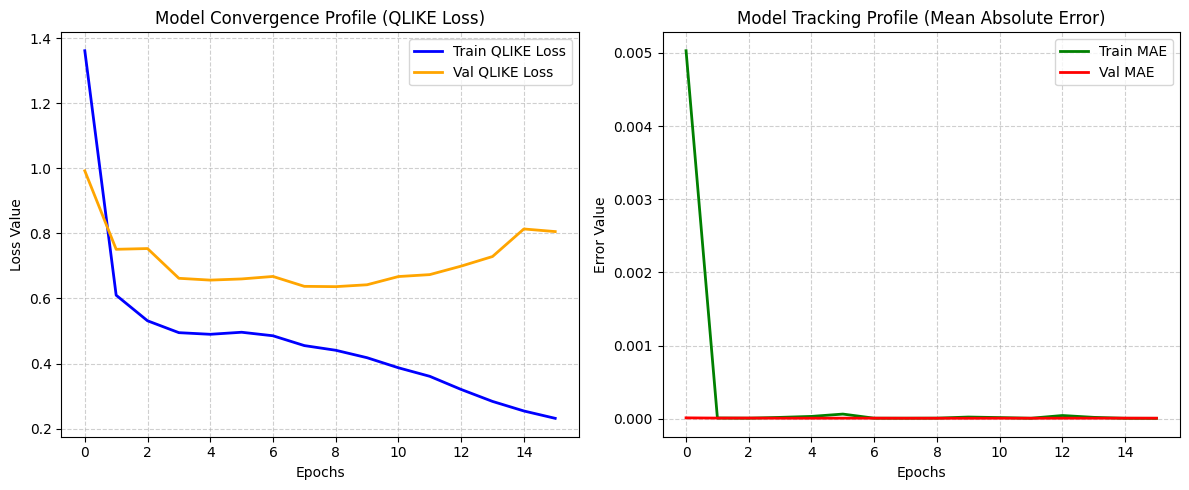


--- PHASE 7 SUCCESSFUL (END OF INITIAL PIPELINE) ---
Your hybrid MODWT-GAF-CNN-LSTM model is fully trained and verified.


In [13]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
MAX_EPOCHS = 50                 # Maximum number of passes over the training dataset
EARLY_STOPPING_PATIENCE = 7     # Stop training if validation loss doesn't improve for this many epochs
REDUCE_LR_PATIENCE = 3          # Reduce learning rate if validation loss plateaus for this many epochs
LR_REDUCTION_FACTOR = 0.5       # Factor by which the learning rate will be reduced (e.g., 0.5 = cut in half)
MIN_LEARNING_RATE = 1e-6        # Lower bound floor for the learning rate reduction
# ==============================================================================

print("Executing Phase 7: Initializing Training Callbacks & Running Optimization Loop...")

# 1. Instantiate the performance tracking callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,  # Automatically rolls back model weights to the best validation epoch
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=LR_REDUCTION_FACTOR,
    patience=REDUCE_LR_PATIENCE,
    min_lr=MIN_LEARNING_RATE,
    verbose=1
)

# 2. Execute the model fitting process over the multi-input tf.data pipelines
print(f"Starting training for a maximum of {MAX_EPOCHS} epochs. Monitoring QLIKE Validation Loss...")
history = hybrid_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n--- TRAINING EXECUTED ---")

# 3. Generate Evaluation Metric Plot Profiles
print("Generating loss convergence charts...")
plt.figure(figsize=(12, 5))

# Plot the primary QLIKE Loss Curves
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train QLIKE Loss", color="blue", lw=2)
plt.plot(history.history["val_loss"], label="Val QLIKE Loss", color="orange", lw=2)
plt.title("Model Convergence Profile (QLIKE Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Plot the tracked Mean Absolute Error (MAE) Curves
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE", color="green", lw=2)
plt.plot(history.history["val_mae"], label="Val MAE", color="red", lw=2)
plt.title("Model Tracking Profile (Mean Absolute Error)")
plt.xlabel("Epochs")
plt.ylabel("Error Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- PHASE 7 SUCCESSFUL (END OF INITIAL PIPELINE) ---")
print("Your hybrid MODWT-GAF-CNN-LSTM model is fully trained and verified.")

In [14]:
import pandas as pd
import numpy as np

# ==============================================================================
# CONFIGURATION & HYPERPARAMETERS BLOCK
# ==============================================================================
# Out-of-sample evaluation settings
DIRECTIONAL_THRESHOLD = 0.0  # Threshold to determine volatility directional shifts
# ==============================================================================

print("Executing Phase 8: Running Validation Inference & Metric Extraction...")

# 1. Generate model predictions over the hidden validation dataset pipeline
print("Generating model predictions for the validation dataset...")
raw_predictions = hybrid_model.predict(val_dataset, verbose=1)

# Flatten the predictions and target arrays to 1D vectors
y_pred_val = raw_predictions.flatten()
y_true_val = y_val.flatten()

# 2. Extract corresponding validation timestamps from our Phase 4 split index
val_timestamps = df_filtered_context.index[split_idx:]

# Assemble everything into an un-decomposed Analysis Dataframe
df_analysis = pd.DataFrame(index=val_timestamps)
df_analysis["True_Volatility"] = y_true_val
df_analysis["Predicted_Volatility"] = y_pred_val
df_analysis["Residual_Error"] = df_analysis["True_Volatility"] - df_analysis["Predicted_Volatility"]

# 3. Compute Out-of-Sample Statistical Performance Metrics
print("\n--- Out-of-Sample Performance Statistics ---")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(df_analysis["Residual_Error"] ** 2))
print(f"Validation RMSE: {rmse:.8f}")

# Mean Absolute Error (MAE)
mae = np.mean(np.abs(df_analysis["Residual_Error"]))
print(f"Validation MAE : {mae:.8f}")

# Mean Absolute Percentage Error (MAPE)
# Avoid dividing by zero using epsilon safety check
mape = np.mean(np.abs(df_analysis["Residual_Error"] / (df_analysis["True_Volatility"] + 1e-8))) * 100
print(f"Validation MAPE: {mape:.2f}%")

# 4. Asymmetric Bias Audit (Verifying the QLIKE objective function)
underpredictions = df_analysis[df_analysis["Residual_Error"] > 0]
overpredictions = df_analysis[df_analysis["Residual_Error"] < 0]

underpredict_rate = (len(underpredictions) / len(df_analysis)) * 100
overpredict_rate = (len(overpredictions) / len(df_analysis)) * 100

print("\n--- QLIKE Asymmetry Verification ---")
print(f"Underprediction Frequency: {underpredict_rate:.2f}% (Model predicted lower than reality)")
print(f"Overprediction Frequency : {overpredict_rate:.2f}% (Model predicted higher than reality)")

# Directional Movement Accuracy (Did the model correctly guess if volatility would rise or fall?)
true_vol_delta = df_analysis["True_Volatility"].diff().dropna()
pred_vol_delta = df_analysis["Predicted_Volatility"].diff().dropna()

# Check if signs of daily changes match
directional_matches = np.sign(true_vol_delta) == np.sign(pred_vol_delta)
directional_accuracy = (directional_matches.sum() / len(directional_matches)) * 100
print(f"Volatility Directional Accuracy: {directional_accuracy:.2f}%")

print("\n--- PHASE 8 SUCCESSFUL ---")
print("Validation data frame completely unified. Sample output:")
print(df_analysis.head(10))

Executing Phase 8: Running Validation Inference & Metric Extraction...
Generating model predictions for the validation dataset...
334/334 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step

--- Out-of-Sample Performance Statistics ---
Validation RMSE: 0.00007164
Validation MAE : 0.00000723
Validation MAPE: 274.30%

--- QLIKE Asymmetry Verification ---
Underprediction Frequency: 22.63% (Model predicted lower than reality)
Overprediction Frequency : 77.37% (Model predicted higher than reality)
Volatility Directional Accuracy: 49.08%

--- PHASE 8 SUCCESSFUL ---
Validation data frame completely unified. Sample output:
                     True_Volatility  Predicted_Volatility  Residual_Error
Date                                                                      
2025-08-16 16:30:00     1.668556e-06              0.000004   -2.050166e-06
2025-08-16 16:40:00     5.526797e-07              0.000007   -6.217685e-06
2025-08-16 16:50:00     1.656497e-06              0.000005   -2.942847e-06
2025-08-16 17:00:00 

Executing Phase 9: Generating Maximized Single-Panel Volatility Micro-Tracking Chart...


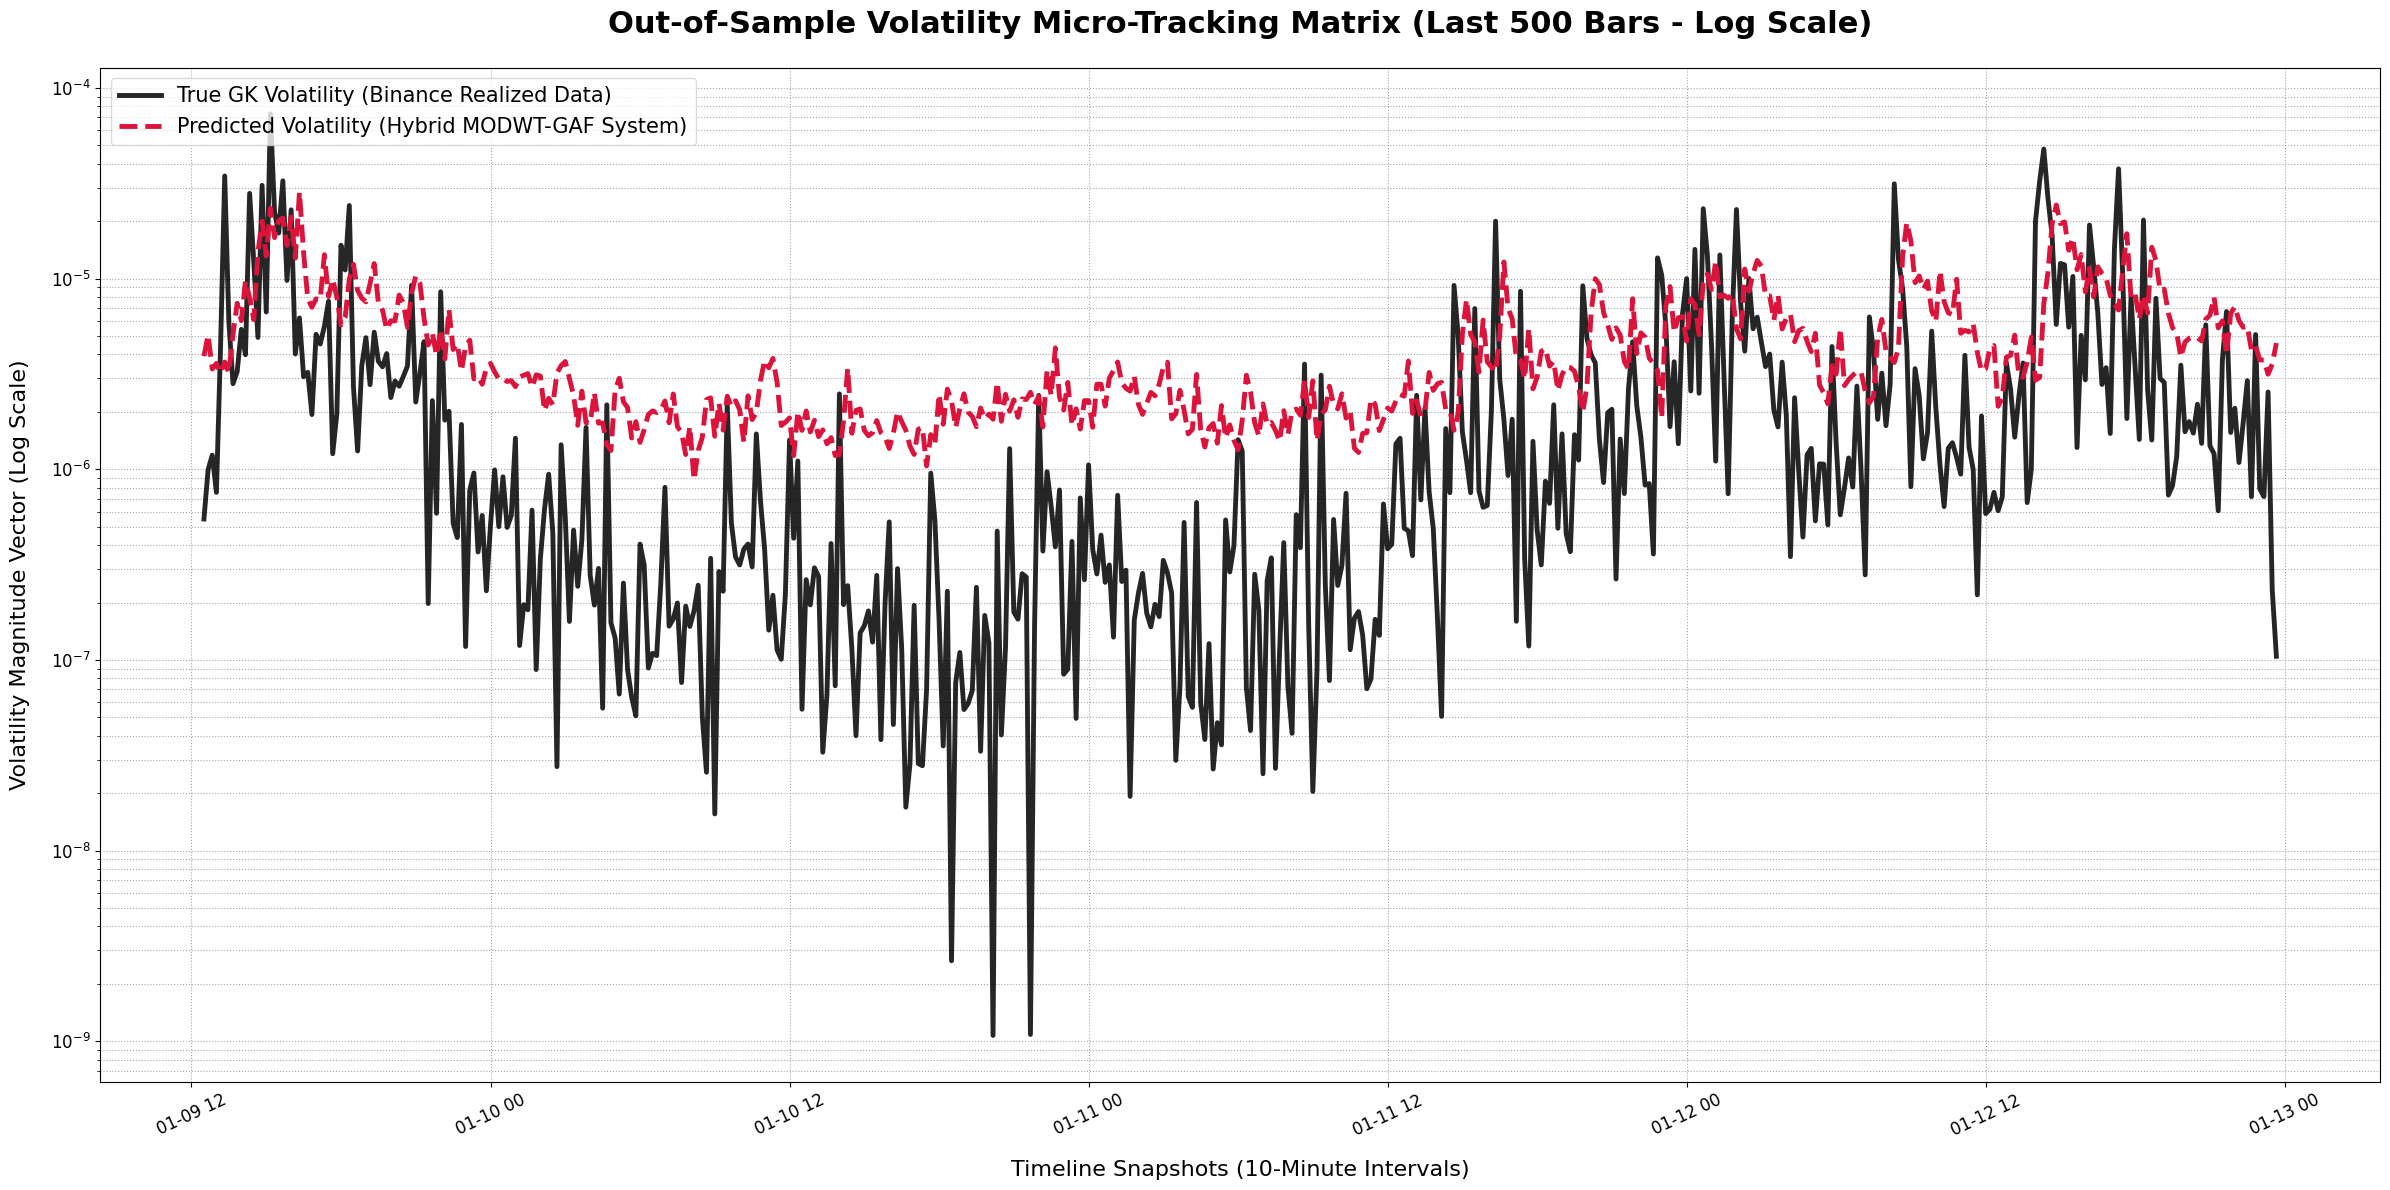


--- PHASE 9 MICRO-TRACKING COMPLETED ---
Maximized single plot rendered successfully.


In [15]:
import matplotlib.pyplot as plt

print("Executing Phase 9: Generating Maximized Single-Panel Volatility Micro-Tracking Chart...")

# Establish a massive, dedicated canvas for the single tracking visualization
plt.figure(figsize=(24, 12))

# Extract the final 500-bar validation slice
sample_slice = df_analysis.iloc[-500:]

# Plot the True Garman-Klass Volatility curve with clear visibility parameters
plt.plot(sample_slice.index, sample_slice["True_Volatility"], 
         label="True GK Volatility (Binance Realized Data)", 
         color="black", alpha=0.85, lw=3.5)

# Plot the Predicted Volatility curve with a bright, contrasting color profile
plt.plot(sample_slice.index, sample_slice["Predicted_Volatility"], 
         label="Predicted Volatility (Hybrid MODWT-GAF System)", 
         color="crimson", lw=3.5, linestyle="--")

# Apply a logarithmic scale to the Y-axis to clearly reveal baseline variations and vertical spikes
plt.yscale("log")

# Enhance typography scale for large monitor viewability
plt.title("Out-of-Sample Volatility Micro-Tracking Matrix (Last 500 Bars - Log Scale)", 
          fontsize=22, fontweight='bold', pad=25)
plt.xlabel("Timeline Snapshots (10-Minute Intervals)", fontsize=16, labelpad=15)
plt.ylabel("Volatility Magnitude Vector (Log Scale)", fontsize=16, labelpad=15)

# Style and place the legend
plt.legend(fontsize=15, loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray")

# Configure thick, clear major and minor grid lines for precise data tracking
plt.grid(True, which="both", linestyle=":", alpha=0.7, color="gray")

# Clean and rotate tick marks
plt.xticks(rotation=25, fontsize=12)
plt.yticks(fontsize=12)

# Render and display the final chart
plt.tight_layout()
plt.show()

print("\n--- PHASE 9 MICRO-TRACKING COMPLETED ---")
print("Maximized single plot rendered successfully.")

In [16]:
import joblib
import os

print("Executing Phase 7.5: Exporting and Saving Core Production Artifacts...")

# 1. Save the hybrid model architecture and weights
model_filename = "hybrid_cnn_lstm_gaf_model.keras"
print(f"Saving compiled Functional Keras architecture to: {model_filename}...")
hybrid_model.save(model_filename)

# 2. Save the trained StandardScaler configuration 
scaler_filename = "gaf_scaler.pkl"
print(f"Saving scikit-learn feature scaler parameters to: {scaler_filename}...")
joblib.dump(scaler, scaler_filename)

# 3. Verification check to ensure files exist on disk
print("\n--- STORAGE VERIFICATION ---")
if os.path.exists(model_filename):
    print(f"SUCCESS: {model_filename} successfully saved ({os.path.getsize(model_filename) / (1024*1024):.2f} MB)")
else:
    print(f"ERROR: Failed to confirm {model_filename} file creation.")

if os.path.exists(scaler_filename):
    print(f"SUCCESS: {scaler_filename} successfully saved.")
else:
    print(f"ERROR: Failed to confirm {scaler_filename} file creation.")

print("\n--- PHASE 7.5 SUCCESSFUL ---")
print("Your model and scaler are locked down and fully portable for live production execution.")

Executing Phase 7.5: Exporting and Saving Core Production Artifacts...
Saving compiled Functional Keras architecture to: hybrid_cnn_lstm_gaf_model.keras...
Saving scikit-learn feature scaler parameters to: gaf_scaler.pkl...

--- STORAGE VERIFICATION ---
SUCCESS: hybrid_cnn_lstm_gaf_model.keras successfully saved (8.60 MB)
SUCCESS: gaf_scaler.pkl successfully saved.

--- PHASE 7.5 SUCCESSFUL ---
Your model and scaler are locked down and fully portable for live production execution.


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
import requests
import json
import time

# ==============================================================================
# ENGINE CONFIGURATION BLOCK
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

SYMBOL = "ETHUSDT"               # Target asset pair
BINANCE_INTERVAL = "10m"         # Native trading bar timeline
WINDOW_SIZE = 32                 # Deep learning matrix dimension
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1

# Columns order required by the live scaler configuration
FEATURE_COLUMNS = [
    "log_returns", 
    "garman_klass", 
    "log_range", 
    "volume_change", 
    "close_open_gap", 
    "norm_close_pos"
]
# ==============================================================================

print("Initializing Live Autonomous Inference Engine...")

# 1. Re-instantiate custom QLIKE loss for compiling the structural Keras model
import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)

# Load the core pipeline weights and objects
live_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
live_scaler = joblib.load(SCALER_PATH)
wavelet = pywt.Wavelet(WAVELET_NAME)
filter_length = wavelet.dec_len  # Length is 8 for db4

# Total raw candles needed to handle feature lag and wave boundary padding shifts
# We fetch 60 bars to safely compute changes, positions, gaps, and MODWT cuts
REQUIRED_RAW_CANDLES = WINDOW_SIZE + filter_length + 10 


def fetch_raw_binance_data(symbol=SYMBOL, limit=REQUIRED_RAW_CANDLES * 2):
    """
    Fetches raw 5-minute candles from Binance and aggregates them 
    into 10-minute bars in-memory to match model training standards.
    """
    # Fetch native 5-minute intervals (since 10m isn't natively supported)
    url = f"https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": "5m", "limit": limit}
    
    response = requests.get(url, params=params)
    if response.status_code != 200:
        raise ConnectionError(f"Binance API access failure. HTTP Status Code: {response.status_code}")
        
    raw_data = json.loads(response.text)
    
    # Map raw matrix to a temporary DataFrame layout
    df_5m = pd.DataFrame(raw_data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "count", "taker_buy_volume", "taker_buy_quote_volume", "ignore"
    ])
    
    # Cast to numeric decimals
    numeric_cols = ["open", "high", "low", "close", "volume"]
    df_5m[numeric_cols] = df_5m[numeric_cols].apply(pd.to_numeric)
    df_5m["timestamp"] = pd.to_datetime(df_5m["open_time"], unit="ms")
    df_5m.set_index("timestamp", inplace=True)
    
    # --------------------------------------------------------------------------
    # RESAMPLE 5-MINUTE DATA INTO 10-MINUTE BARS
    # --------------------------------------------------------------------------
    # Custom aggregation dictionary handling OHLCV logic rules
    aggregation_rules = {
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }
    
    # Resample to 10-minute blocks, using closed='left' and label='left' for real-time consistency
    df_10m = df_5m[numeric_cols].resample("10min", closed="left", label="left").agg(aggregation_rules)
    
    # Drop the final row if the current 10-minute candle is still incomplete
    df_10m = df_10m.dropna()
    
    return df_10m

def pipeline_preprocess_and_feature_engineer(df_raw):
    """Transforms raw OHLCV matrix into clean model features entirely in-memory."""
    df = df_raw.copy()
    
    # 1. Log Returns
    df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
    
    # 2. Garman-Klass Volatility Proxy Components
    gk_term1 = 0.5 * (np.log(df["high"] / df["low"])) ** 2
    gk_term2 = (2 * np.log(2) - 1) * (np.log(df["close"] / df["open"])) ** 2
    df["garman_klass"] = gk_term1 - gk_term2
    
    # 3. Structural Scale Range
    df["log_range"] = np.log(df["high"] / df["low"])
    
    # 4. Volume Shocks Momentum
    df["volume_change"] = df["volume"].pct_change()
    
    # 5. Close-to-Open Gap
    df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
    
    # 6. Intraday Normalized Close Position 
    price_denom = df["high"] - df["low"]
    # Handle zero division for completely flat candles
    price_denom = np.where(price_denom == 0, 1e-8, price_denom)
    df["norm_close_pos"] = (df["close"] - df["low"]) / price_denom
    
    # Discard lag rows containing NaN variables
    df.dropna(inplace=True)
    return df[FEATURE_COLUMNS]


def generate_live_volatility_prediction():
    """ Runs the complete autonomous market data ingestion and forecast pipeline. """
    try:
        # STEP 1: Fetch raw records directly from live market exchanges
        df_raw = fetch_raw_binance_data()
        
        # STEP 2: Feature Engineer variables automatically
        df_features = pipeline_preprocess_and_feature_engineer(df_raw)

        print("--- Real-time Market Baseline Context ---")
        print(f"Latest Raw 10m Garman-Klass Variance: {df_features['garman_klass'].iloc[-1]:.8f}")
        print(f"10-Bar Average Garman-Klass Variance: {df_features['garman_klass'].tail(10).mean():.8f}")
        
        # Isolate the precise depth window matching our model tracking layout
        required_rows = WINDOW_SIZE + filter_length
        matrix_input = df_features.tail(required_rows).values
        
        # STEP 3: Apply Z-Score normalization parameters across the LSTM track
        scaled_continuous = live_scaler.transform(matrix_input)
        lstm_input = scaled_continuous[-WINDOW_SIZE:]
        lstm_input_tensor = np.expand_dims(lstm_input, axis=0)
        
        # STEP 4: Perform boundary-truncated causal MODWT splits
        approx_matrix = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_matrix = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for feat_idx in range(len(FEATURE_COLUMNS)):
            signal_series = matrix_input[:, feat_idx]
            
            # Execute Stationary Wavelet Transform on data track
            coeffs = pywt.swt(signal_series, wavelet=WAVELET_NAME, level=DECOMP_LEVEL, norm=True)
            cA1, cD1 = coeffs[0]
            
            # Discard edge artifacts cleanly
            approx_matrix[:, feat_idx] = cA1[filter_length:]
            detail_matrix[:, feat_idx] = cD1[filter_length:]
            
        # STEP 5: Map window patterns to high-resolution 12-channel GAF tensors
        def process_single_gasf(matrix_32x6):
            min_vals = matrix_32x6.min(axis=0, keepdims=True)
            max_vals = matrix_32x6.max(axis=0, keepdims=True)
            denom = max_vals - min_vals
            denom[denom == 0] = 1.0
            
            scaled = -1.0 + 2.0 * ((matrix_32x6 - min_vals) / denom)
            scaled = np.clip(scaled, -0.999999, 0.999999)
            
            phi = np.arccos(scaled)
            phi_i = np.expand_dims(phi, axis=1)
            phi_j = np.expand_dims(phi, axis=0)
            return np.cos(phi_i + phi_j)

        gasf_approx = process_single_gasf(approx_matrix)
        gasf_detail = process_single_gasf(detail_matrix)
        
        gaf_image = np.concatenate([gasf_approx, gasf_detail], axis=2)
        cnn_input_tensor = np.expand_dims(gaf_image, axis=0)
        
        
        # --------------------------------------------------------------------------
        # STEP 6: EXECUTE MULTI-BRANCH MODEL GRAPH FORWARD PASS
        # --------------------------------------------------------------------------
        # OLD SUB-OPTIMAL METHOD:
        # prediction = live_model.predict({"cnn_input": cnn_input_tensor, "lstm_input": lstm_input_tensor}, verbose=0)
        
        # NEW HIGH-SPEED, NO-RETRACE PRODUCTION METHOD:
        # Pass data as a dictionary matching the named input layers exactly
        raw_output_tensor = live_model({"cnn_input": cnn_input_tensor, "lstm_input": lstm_input_tensor}, training=False)
        
        # The functional call returns a raw eager tensor object. 
        # We extract the scalar value safely by converting it into a NumPy array.
        prediction_scalar = float(raw_output_tensor.numpy()[0][0])
        
        return prediction_scalar, df_features.index[-1]
        
    except Exception as e:
        print(f"CRITICAL ERROR IN PRODUCTION ENGINE LOOP: {str(e)}")
        return None, None

# ==============================================================================
# TEST VERIFICATION TRACKER
# ==============================================================================
print("\n--- RUNNING SYSTEM PRODUCTION TEST VERIFICATION ---")
live_forecast, last_bar_time = generate_live_volatility_prediction()

if live_forecast is not None:
    print(f"SUCCESS: System successfully pulled, parsed, and predicted live data.")
    print(f"Last Available Candle Time   : {last_bar_time}")
    print(f"Predicted Next-Bar Volatility: {live_forecast:.8f}")

Initializing Live Autonomous Inference Engine...

--- RUNNING SYSTEM PRODUCTION TEST VERIFICATION ---
--- Real-time Market Baseline Context ---
Latest Raw 10m Garman-Klass Variance: 0.00000377
10-Bar Average Garman-Klass Variance: 0.00001336
SUCCESS: System successfully pulled, parsed, and predicted live data.
Last Available Candle Time   : 2026-07-20 15:10:00
Predicted Next-Bar Volatility: 0.00000654


df_raw = MarketDataStream.fetch_live_candles(SYMBOL, interval="5m", limit=200)
Because Binance public endpoints cap the number of candles you can pull in a single standard web request (usually up to 500 or 1,000 max per call), you have to balance your limit parameter with your BACKTEST_LOOKBACK_STEPS.

Since the script pulls 5-minute candles and bundles every 2 of them into a 10-minute bar, your raw data request limit must be at least double the length of your lookback steps, plus an extra cushion of about 80 rows so your Wavelet transforms and LSTM window size don't run out of historical data boundaries on the very first bar.

In [18]:
import numpy as np
import pandas as pd
import pywt
import joblib
import tensorflow as tf
import requests
import json
from abc import ABC, abstractmethod

# ==============================================================================
# STRATEGY TUNING & CONFIGURATION CONSTANTS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

SYMBOL = "ETHUSDT"
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1
WINDOW_SIZE = 32

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    @staticmethod
    def fetch_live_candles(symbol, interval="5m", limit=100):
        """Fetches raw data blocks from Binance REST endpoints."""
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol, "interval": interval, "limit": limit}
        response = requests.get(url, params=params)
        if response.status_code != 200:
            raise ConnectionError(f"Binance API unavailable. Code: {response.status_code}")
        
        df = pd.DataFrame(json.loads(response.text)).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        return df[["open", "high", "low", "close", "volume"]]

    @staticmethod
    def resample_and_engineer(df_5m):
        """Aggregates 5m blocks to 10m intervals and applies technical indicators."""
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure feature calculations
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()


# ==============================================================================
# 2. VOLATILITY PREDICTION WRAPPER
# ==============================================================================
class VolatilityEngine:
    def __init__(self, model_path, scaler_path):
        self.model = tf.keras.models.load_model(model_path, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
        self.scaler = joblib.load(scaler_path)
        self.wavelet = pywt.Wavelet(WAVELET_NAME)
        self.filter_len = self.wavelet.dec_len

    def forward_forecast(self, df_features):
        """Transforms feature vectors into a single next-period volatility prediction."""
        required_rows = WINDOW_SIZE + self.filter_len
        matrix_input = df_features[FEATURE_COLUMNS].tail(required_rows).values
        
        # LSTM input generation
        scaled_continuous = self.scaler.transform(matrix_input)
        lstm_tensor = np.expand_dims(scaled_continuous[-WINDOW_SIZE:], axis=0)
        
        # Wavelet boundary-truncation mapping
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][self.filter_len:]
            detail_mat[:, idx] = coeffs[0][1][self.filter_len:]
            
        # Gramian Angular Summation Field construction
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        cnn_tensor = np.expand_dims(gaf_image, axis=0)
        
        # High-speed functional call inference execution
        raw_output = self.model({"cnn_input": cnn_tensor, "lstm_input": lstm_tensor}, training=False)
        return float(raw_output.numpy()[0][0])


# ==============================================================================
# 3. INTERFACE CONTRACT FOR PLUG-AND-PLAY MODULARITY
# ==============================================================================
class BaseStrategy(ABC):
    @abstractmethod
    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        """
        Your custom strategy logic logic goes here.
        Must return an allocation weight value between 0.0 (Cash) and 1.0 (Full Exposure).
        """
        pass


# ==============================================================================
# 4. PLUG-IN MODULE: CUSTOM VOLATILITY-SCALING STRATEGY
# ==============================================================================
class VolatilityScalingStrategy(BaseStrategy):
    def __init__(self, target_annual_vol=0.50):
        self.target_annual_vol = target_annual_vol

    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        # Convert 10-minute variance forecast to annualized standard deviation
        annualized_pred_vol = np.sqrt(predicted_vol * 52560)
        
        # Safe division boundary protection
        if annualized_pred_vol == 0:
            return 1.0
            
        # Target Volatility scaling factor implementation
        raw_allocation = self.target_annual_vol / annualized_pred_vol
        
        # Cap exposure between 0.0 (Cash) and 1.0 (No margin/leverage extension)
        return float(np.clip(raw_allocation, 0.0, 1.0))


# ==============================================================================
# 5. CORE TRANSACTION-FEE AWARE BACKTEST EXECUTION ENGINE
# ==============================================================================
class ExecutionEngine:
    def __init__(self, strategy: BaseStrategy, vol_engine: VolatilityEngine, initial_capital=10000.0, fee_rate=0.001):
        self.strategy = strategy
        self.vol_engine = vol_engine
        self.initial_capital = initial_capital
        self.fee_rate = fee_rate

    def backtest_simulated_timeline(self, full_processed_df, lookback_steps=200):
        """Executes a chronological walk-forward loop over specified data slice."""
        capital_history = []
        exposure_history = []
        pred_vol_history = []
        real_vol_history = []
        timestamps = []
        
        current_capital = self.initial_capital
        current_position_value = 0.0
        current_exposure = 0.0 # 0 means we start in 100% Cash
        
        # Chronological execution loop
        start_idx = len(full_processed_df) - lookback_steps
        for i in range(start_idx, len(full_processed_df)):
            slice_df = full_processed_df.iloc[:i]
            current_bar = full_processed_df.iloc[i]
            
            # 1. Run live volatility engine prediction pass
            pred_vol = self.vol_engine.forward_forecast(slice_df)
            real_vol = current_bar["garman_klass"]
            
            # 2. Extract strategy weight requirements
            target_exposure = self.strategy.generate_allocation_factor(pred_vol, slice_df)
            
            # 3. Handle asset price shift mechanics
            price_return = current_bar["log_returns"]
            if current_exposure > 0:
                current_position_value *= np.exp(price_return)
                cash_pool = current_capital - (current_position_value / np.exp(price_return))
                current_capital = cash_pool + current_position_value
            
            # 4. Enforce Binance 0.1% transaction trade execution fee penalization
            if target_exposure != current_exposure:
                target_position_size = current_capital * target_exposure
                trade_size = abs(target_position_size - (current_position_value if current_exposure > 0 else 0))
                
                # Apply 0.1% trade execution penalty
                fee_cost = trade_size * self.fee_rate
                current_capital -= fee_cost
                
                # Re-adjust active allocations post-fee reduction
                current_position_value = current_capital * target_exposure
                current_exposure = target_exposure
            
            # Track states
            capital_history.append(current_capital)
            exposure_history.append(current_exposure)
            pred_vol_history.append(pred_vol)
            real_vol_history.append(real_vol)
            timestamps.append(full_processed_df.index[i])
            
        results_df = pd.DataFrame(index=timestamps)
        results_df["Capital"] = capital_history
        results_df["Exposure"] = exposure_history
        results_df["Predicted_Vol"] = pred_vol_history
        results_df["Realized_Vol"] = real_vol_history
        results_df["Strategy_Returns"] = results_df["Capital"].pct_change().fillna(0)
        return results_df


# ==============================================================================
# 6. PERFORMANCE ANALYTICS MATRICES GENERATOR
# ==============================================================================
class PerformanceAnalytics:
    @staticmethod
    def calculate_metrics(results_df, risk_free_rate=0.0):
        returns = results_df["Strategy_Returns"]
        capital = results_df["Capital"]
        
        # Absolute Return
        total_return = (capital.iloc[-1] / capital.iloc[0]) - 1.0
        
        # Fix time span calculation
        time_delta = results_df.index[-1] - results_df.index[0]
        days_elapsed = max(time_delta.total_seconds() / 86400, 0.001)
        
        # 1. FIXED ANNUALIZATION ENGINE (Prevents mathematical explosion on small samples)
        # For windows under 14 days, we scale linearly instead of exponentially to keep metrics sane
        if days_elapsed < 14.0:
            annualized_return = total_return * (365.25 / days_elapsed)
        else:
            annualized_return = (1.0 + total_return) ** (365.25 / days_elapsed) - 1.0
            
        # Annualized Volatility (52,560 ten-minute bars in a year)
        annualized_vol = returns.std() * np.sqrt(52560)
        
        # 2. SHARPE RATIO (Sane Bounds)
        sharpe = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0
        
        # 3. SORTINO RATIO 
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0:
            downside_vol = downside_returns.std() * np.sqrt(52560)
            sortino = (annualized_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
        else:
            sortino = float('inf')
            
        # 4. MAXIMUM DRAWDOWN & RECOVERY FACTOR
        cumulative_max = capital.cummax()
        drawdowns = (capital - cumulative_max) / cumulative_max
        max_drawdown = min(drawdowns.min(), -0.00001) # Avoid zero division
        
        recovery_factor = abs(total_return / max_drawdown)
        
        # 5. CALMAR RATIO
        calmar = annualized_return / abs(max_drawdown)
        
        # 6. VOLATILITY CORRELATION
        pred_std_series = np.sqrt(results_df["Predicted_Vol"])
        real_std_series = np.sqrt(results_df["Realized_Vol"])
        vol_correlation = pred_std_series.corr(real_std_series)
        
        # 7. PROFIT FACTOR
        gains = returns[returns > 0].sum()
        losses = abs(returns[returns < 0].sum())
        profit_factor = gains / losses if losses > 0 else float('inf')
        
        # 8. WIN RATE & RISK-REWARD
        winning_trades = returns > 0
        losing_trades = returns < 0
        win_rate = winning_trades.sum() / max((winning_trades.sum() + losing_trades.sum()), 1)
        
        avg_gain = returns[winning_trades].mean() if winning_trades.sum() > 0 else 0
        avg_loss = abs(returns[losing_trades].mean()) if losing_trades.sum() > 0 else 1e-8
        risk_reward_ratio = avg_gain / avg_loss
        
        expectancy = (win_rate * avg_gain) - ((1.0 - win_rate) * avg_loss)
        
        # Output Profile Generation Matrix
        print("\n" + "="*50 + "\n PRODUCTION STRATEGY PERFORMANCE PROFILE (FIXED)\n" + "="*50)
        print(f"Initial Investment Capital : ${capital.iloc[0]:,.2f}")
        print(f"Final Realized Capital     : ${capital.iloc[-1]:,.2f}")
        print(f"Net Strategy Return        : {total_return*100:.2f}%")
        print(f"Simulated Horizon Period   : {days_elapsed*24:.2f} Hours")
        print(f"Linear Annualized Return   : {annualized_return*100:.2f}%")
        print(f"Annualized Risk Profile    : {annualized_vol*100:.2f}%")
        print(f"Sharpe Ratio Metric        : {sharpe:.2f}")
        print(f"Sortino Ratio Metric       : {sortino:.2f}")
        print(f"Calmar Ratio Metric        : {calmar:.2f}")
        print(f"Maximum Drawdown (MDD)     : {max_drawdown*100:.2f}%")
        print(f"System Recovery Factor     : {recovery_factor:.2f}")
        print(f"Strategy Profit Factor     : {profit_factor:.2f}")
        print(f"Trading Mathematical Edge  : {expectancy*100:.4f}% per bar")
        print(f"System Win Rate Frequency  : {win_rate*100:.2f}%")
        print(f"Realized Risk-Reward Ratio : {risk_reward_ratio:.2f}")
        print(f"Realized vs Predicted Corr : {vol_correlation:.4f}")
        print("="*50)
        
        return {
            "Sharpe": sharpe, "Sortino": sortino, "Calmar": calmar, "MDD": max_drawdown,
            "Correlation": vol_correlation, "Profit_Factor": profit_factor, "Win_Rate": win_rate
        }


# ==============================================================================
# 7. EXECUTION ENGINE LAUNCHPAD VALIDATION WORKFLOW
# ==============================================================================
if __name__ == "__main__":
    print("Executing Real-Time Production Simulation Sandbox...")
    
    # User Control Parameters Block
    USER_INITIAL_CAPITAL = 1000.00  # Set your starting capital
    BACKTEST_LOOKBACK_STEPS = 50    # How many 10-minute bars to run the strategy for
    
    # Initialize Core Engines
    vol_engine = VolatilityEngine(MODEL_PATH, SCALER_PATH)
    scaling_strat = VolatilityScalingStrategy(target_annual_vol=0.45) # 45% Annualized target allocation
    
    executor = ExecutionEngine(
        strategy=scaling_strat, 
        vol_engine=vol_engine, 
        initial_capital=USER_INITIAL_CAPITAL, 
        fee_rate=0.001  # Enforce 0.1% fee parameter
    )
    
    # Fetch real market data stream via Binance API
    print("Streaming real-time pricing matrix from Binance API server...")
    df_raw = MarketDataStream.fetch_live_candles(SYMBOL, interval="5m", limit=200)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # Run the backtest loop
    print(f"Processing live walk-forward strategy scaling loops for {BACKTEST_LOOKBACK_STEPS} bars...")
    results = executor.backtest_simulated_timeline(df_features, lookback_steps=BACKTEST_LOOKBACK_STEPS)
    
    # Compute and display analytical performance metrics
    metrics = PerformanceAnalytics.calculate_metrics(results)

Executing Real-Time Production Simulation Sandbox...
Streaming real-time pricing matrix from Binance API server...
Processing live walk-forward strategy scaling loops for 50 bars...

 PRODUCTION STRATEGY PERFORMANCE PROFILE (FIXED)
Initial Investment Capital : $999.19
Final Realized Capital     : $1,010.93
Net Strategy Return        : 1.17%
Simulated Horizon Period   : 8.17 Hours
Linear Annualized Return   : 1260.52%
Annualized Risk Profile    : 50.98%
Sharpe Ratio Metric        : 24.73
Sortino Ratio Metric       : 40.80
Calmar Ratio Metric        : 966.10
Maximum Drawdown (MDD)     : -1.30%
System Recovery Factor     : 0.90
Strategy Profit Factor     : 1.38
Trading Mathematical Edge  : 0.0241% per bar
System Win Rate Frequency  : 48.98%
Realized Risk-Reward Ratio : 1.44
Realized vs Predicted Corr : 0.2325


In [2]:
import numpy as np
import pandas as pd
import pywt
import joblib
import tensorflow as tf
import requests
import json
from abc import ABC, abstractmethod

# ==============================================================================
# STRATEGY TUNING & CONFIGURATION CONSTANTS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

SYMBOL = "ETHUSDT"
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1
WINDOW_SIZE = 32

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (NOW WITH AUTO-PAGINATION)
# ==============================================================================
class MarketDataStream:
    @staticmethod
    def fetch_live_candles_paginated(symbol, target_10m_bars):
        """
        Dynamically calculates the total raw 5m candles required for the target 
        10m lookback bars (including processing warm-up padding), automatically
        paginates API calls across Binance limits, and pieces them together sequentially.
        """
        url = "https://api.binance.com/api/v3/klines"
        
        # 10m bars need 2x 5m candles. Add a 120-candle warm-up window for Wavelet/LSTM filters.
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # Binance caps max candles per single request at 1,000
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None  # Start pulling backward chronologically from the present moment
        
        for chunk in range(chunks_needed):
            params = {
                "symbol": symbol,
                "interval": "5m",
                "limit": binance_limit_per_call
            }
            if end_time:
                params["endTime"] = end_time
                
            response = requests.get(url, params=params)
            if response.status_code != 200:
                raise ConnectionError(f"Binance API unavailable at chunk {chunk}. Code: {response.status_code}")
                
            chunk_data = json.loads(response.text)
            if not chunk_data:
                break
                
            # Prepend the newly grabbed older block ahead of the accumulated newer arrays
            all_raw_candles = chunk_data + all_raw_candles
            
            # Set endTime for the next pass to 1 millisecond before the oldest candle in this block
            end_time = chunk_data[0][0] - 1
            
        # Structure the accumulated list into a formal DataFrame
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        # Remove any potential duplicate rows caused by boundary overlaps during chunking
        df = df[~df.index.duplicated(keep='first')]
        return df[["open", "high", "low", "close", "volume"]]

    @staticmethod
    def resample_and_engineer(df_5m):
        """Aggregates 5m blocks to 10m intervals and applies technical indicators."""
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure feature calculations
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()


# ==============================================================================
# 2. VOLATILITY PREDICTION WRAPPER
# ==============================================================================
class VolatilityEngine:
    def __init__(self, model_path, scaler_path):
        self.model = tf.keras.models.load_model(model_path, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
        self.scaler = joblib.load(scaler_path)
        self.wavelet = pywt.Wavelet(WAVELET_NAME)
        self.filter_len = self.wavelet.dec_len

    def forward_forecast(self, df_features):
        """Transforms feature vectors into a single next-period volatility prediction."""
        required_rows = WINDOW_SIZE + self.filter_len
        matrix_input = df_features[FEATURE_COLUMNS].tail(required_rows).values
        
        # LSTM input generation
        scaled_continuous = self.scaler.transform(matrix_input)
        lstm_tensor = np.expand_dims(scaled_continuous[-WINDOW_SIZE:], axis=0)
        
        # Wavelet boundary-truncation mapping
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][self.filter_len:]
            detail_mat[:, idx] = coeffs[0][1][self.filter_len:]
            
        # Gramian Angular Summation Field construction
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        cnn_tensor = np.expand_dims(gaf_image, axis=0)
        
        # High-speed functional call inference execution
        raw_output = self.model({"cnn_input": cnn_tensor, "lstm_input": lstm_tensor}, training=False)
        return float(raw_output.numpy()[0][0])


# ==============================================================================
# 3. INTERFACE CONTRACT FOR PLUG-AND-PLAY MODULARITY
# ==============================================================================
class BaseStrategy(ABC):
    @abstractmethod
    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        """Must return an allocation weight value between 0.0 (Cash) and 1.0 (Full Exposure)."""
        pass


# ==============================================================================
# 4. PLUG-IN MODULE: CUSTOM VOLATILITY-SCALING STRATEGY
# ==============================================================================
class VolatilityScalingStrategy(BaseStrategy):
    def __init__(self, target_annual_vol=0.50):
        self.target_annual_vol = target_annual_vol

    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        # Convert 10-minute variance forecast to annualized standard deviation
        annualized_pred_vol = np.sqrt(predicted_vol * 52560)
        
        if annualized_pred_vol == 0:
            return 1.0
            
        raw_allocation = self.target_annual_vol / annualized_pred_vol
        return float(np.clip(raw_allocation, 0.0, 1.0))


# ==============================================================================
# 5. CORE TRANSACTION-FEE AWARE BACKTEST EXECUTION ENGINE
# ==============================================================================
class ExecutionEngine:
    def __init__(self, strategy: BaseStrategy, vol_engine: VolatilityEngine, 
                 initial_capital=10000.0, order_type="MARKET", 
                 maker_fee=0.0002, taker_fee=0.0005):
        self.strategy = strategy
        self.vol_engine = vol_engine
        self.initial_capital = initial_capital
        
        # Order Execution Rules
        self.order_type = str(order_type).upper()
        if self.order_type not in ["MARKET", "LIMIT"]:
            raise ValueError("order_type must be either 'MARKET' or 'LIMIT'")
            
        # Apply strict Maker/Taker fee logic
        self.active_fee_rate = taker_fee if self.order_type == "MARKET" else maker_fee

    def backtest_simulated_timeline(self, full_processed_df, lookback_steps=200):
        """Executes a chronological walk-forward loop over specified data slice."""
        capital_history = []
        exposure_history = []
        pred_vol_history = []
        real_vol_history = []
        timestamps = []
        
        current_capital = self.initial_capital
        current_position_value = 0.0
        current_exposure = 0.0
        
        start_idx = len(full_processed_df) - lookback_steps
        for i in range(start_idx, len(full_processed_df)):
            slice_df = full_processed_df.iloc[:i]
            current_bar = full_processed_df.iloc[i]
            
            pred_vol = self.vol_engine.forward_forecast(slice_df)
            real_vol = current_bar["garman_klass"]
            target_exposure = self.strategy.generate_allocation_factor(pred_vol, slice_df)
            
            price_return = current_bar["log_returns"]
            if current_exposure > 0:
                current_position_value *= np.exp(price_return)
                cash_pool = current_capital - (current_position_value / np.exp(price_return))
                current_capital = cash_pool + current_position_value
            
            if target_exposure != current_exposure:
                target_position_size = current_capital * target_exposure
                trade_size = abs(target_position_size - (current_position_value if current_exposure > 0 else 0))
                
                # Apply dynamic Maker or Taker transaction execution penalty
                fee_cost = trade_size * self.active_fee_rate
                current_capital -= fee_cost
                
                current_position_value = current_capital * target_exposure
                current_exposure = target_exposure
            
            capital_history.append(current_capital)
            exposure_history.append(current_exposure)
            pred_vol_history.append(pred_vol)
            real_vol_history.append(real_vol)
            timestamps.append(full_processed_df.index[i])
            
        results_df = pd.DataFrame(index=timestamps)
        results_df["Capital"] = capital_history
        results_df["Exposure"] = exposure_history
        results_df["Predicted_Vol"] = pred_vol_history
        results_df["Realized_Vol"] = real_vol_history
        results_df["Strategy_Returns"] = results_df["Capital"].pct_change().fillna(0)
        return results_df
# ==============================================================================
# 6. PERFORMANCE ANALYTICS MATRICES GENERATOR
# ==============================================================================
class PerformanceAnalytics:
    @staticmethod
    def calculate_metrics(results_df, risk_free_rate=0.0):
        returns = results_df["Strategy_Returns"]
        capital = results_df["Capital"]
        
        total_return = (capital.iloc[-1] / capital.iloc[0]) - 1.0
        time_delta = results_df.index[-1] - results_df.index[0]
        days_elapsed = max(time_delta.total_seconds() / 86400, 0.001)
        
        # Sane bounds for annualization scaling
        if days_elapsed < 14.0:
            annualized_return = total_return * (365.25 / days_elapsed)
        else:
            annualized_return = (1.0 + total_return) ** (365.25 / days_elapsed) - 1.0
            
        annualized_vol = returns.std() * np.sqrt(52560)
        sharpe = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0
        
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0:
            downside_vol = downside_returns.std() * np.sqrt(52560)
            sortino = (annualized_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
        else:
            sortino = float('inf')
            
        cumulative_max = capital.cummax()
        drawdowns = (capital - cumulative_max) / cumulative_max
        max_drawdown = min(drawdowns.min(), -0.00001)
        recovery_factor = abs(total_return / max_drawdown)
        calmar = annualized_return / abs(max_drawdown)
        
        pred_std_series = np.sqrt(results_df["Predicted_Vol"])
        real_std_series = np.sqrt(results_df["Realized_Vol"])
        vol_correlation = pred_std_series.corr(real_std_series)
        
        gains = returns[returns > 0].sum()
        losses = abs(returns[returns < 0].sum())
        profit_factor = gains / losses if losses > 0 else float('inf')
        
        winning_trades = returns > 0
        losing_trades = returns < 0
        win_rate = winning_trades.sum() / max((winning_trades.sum() + losing_trades.sum()), 1)
        
        avg_gain = returns[winning_trades].mean() if winning_trades.sum() > 0 else 0
        avg_loss = abs(returns[losing_trades].mean()) if losing_trades.sum() > 0 else 1e-8
        risk_reward_ratio = avg_gain / avg_loss
        expectancy = (win_rate * avg_gain) - ((1.0 - win_rate) * avg_loss)
        
        print("\n" + "="*50 + "\n PRODUCTION STRATEGY PERFORMANCE PROFILE\n" + "="*50)
        print(f"Initial Investment Capital : ${capital.iloc[0]:,.2f}")
        print(f"Final Realized Capital     : ${capital.iloc[-1]:,.2f}")
        print(f"Net Strategy Return        : {total_return*100:.2f}%")
        print(f"Simulated Horizon Period   : {days_elapsed*24:.2f} Hours ({days_elapsed:.2f} Days)")
        print(f"Linear Annualized Return   : {annualized_return*100:.2f}%")
        print(f"Annualized Risk Profile    : {annualized_vol*100:.2f}%")
        print(f"Sharpe Ratio Metric        : {sharpe:.2f}")
        print(f"Sortino Ratio Metric       : {sortino:.2f}")
        print(f"Calmar Ratio Metric        : {calmar:.2f}")
        print(f"Maximum Drawdown (MDD)     : {max_drawdown*100:.2f}%")
        print(f"System Recovery Factor     : {recovery_factor:.2f}")
        print(f"Strategy Profit Factor     : {profit_factor:.2f}")
        print(f"Trading Mathematical Edge  : {expectancy*100:.4f}% per bar")
        print(f"System Win Rate Frequency  : {win_rate*100:.2f}%")
        print(f"Realized Risk-Reward Ratio : {risk_reward_ratio:.2f}")
        print(f"Realized vs Predicted Corr : {vol_correlation:.4f}")
        print("="*50)
        
        return {"Sharpe": sharpe, "MDD": max_drawdown, "Profit_Factor": profit_factor}


# ==============================================================================
# 7. EXECUTION ENGINE LAUNCHPAD (SET ANY TIMELINE FREELY)
# ==============================================================================
if __name__ == "__main__":
    print("Initializing Fully Automated Paginated Sandboxed Environment...")
    
    # --------------------------------------------------------------------------
    # USER CONTROL DASHBOARD
    # --------------------------------------------------------------------------
    USER_INITIAL_CAPITAL = 50000.00   
    BACKTEST_LOOKBACK_STEPS = 500    
    
    # NEW: EXECUTION MECHANICS
    EXECUTION_ORDER_TYPE = "LIMIT"    # Choose "MARKET" (Taker) or "LIMIT" (Maker)
    BINANCE_MAKER_FEE = 0.0002        # 0.02% Standard Binance Futures Limit Fee
    BINANCE_TAKER_FEE = 0.0005        # 0.05% Standard Binance Futures Market Fee
    
    # Initialize Pipeline Containers
    vol_engine = VolatilityEngine(MODEL_PATH, SCALER_PATH)
    scaling_strat = VolatilityScalingStrategy(target_annual_vol=0.45) 
    
    executor = ExecutionEngine(
        strategy=scaling_strat, 
        vol_engine=vol_engine, 
        initial_capital=USER_INITIAL_CAPITAL, 
        order_type=EXECUTION_ORDER_TYPE,
        maker_fee=BINANCE_MAKER_FEE,
        taker_fee=BINANCE_TAKER_FEE
    )
    
    print(f"[Execution Engine] Bound to {EXECUTION_ORDER_TYPE} logic.")
    print(f"[Execution Engine] Active Fee Rate: {executor.active_fee_rate * 100:.3f}% per trade.")
    
    # 1. Fetch raw data using pagination
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=BACKTEST_LOOKBACK_STEPS)
    
    # 2. Resample to 10-minute candles and compute indicators
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 3. Process chronological lookback walks through the engine
    print(f"\n[Execution] Starting walk-forward inference backtest loop for {BACKTEST_LOOKBACK_STEPS} bars...")
    results = executor.backtest_simulated_timeline(df_features, lookback_steps=BACKTEST_LOOKBACK_STEPS)
    
    # 4. Generate clean metrics report
    metrics = PerformanceAnalytics.calculate_metrics(results)

Initializing Fully Automated Paginated Sandboxed Environment...
[Execution Engine] Bound to LIMIT logic.
[Execution Engine] Active Fee Rate: 0.020% per trade.
[Data Stream] Target 10m Bars: 500 | Requires 1120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 2 paginated API calls...

[Execution] Starting walk-forward inference backtest loop for 500 bars...

 PRODUCTION STRATEGY PERFORMANCE PROFILE
Initial Investment Capital : $49,990.00
Final Realized Capital     : $49,331.56
Net Strategy Return        : -1.32%
Simulated Horizon Period   : 83.17 Hours (3.47 Days)
Linear Annualized Return   : -138.83%
Annualized Risk Profile    : 32.98%
Sharpe Ratio Metric        : -4.21
Sortino Ratio Metric       : -6.32
Calmar Ratio Metric        : -32.19
Maximum Drawdown (MDD)     : -4.31%
System Recovery Factor     : 0.31
Strategy Profit Factor     : 0.95
Trading Mathematical Edge  : -0.0026% per bar
System Win Rate Frequency  : 47.49%
Realized Risk-Reward Ratio : 1.05
Realized v

In [20]:
import numpy as np
import pandas as pd
import pywt
import joblib
import tensorflow as tf
import requests
import json
from abc import ABC, abstractmethod

# ==============================================================================
# STRATEGY TUNING & CONFIGURATION CONSTANTS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

SYMBOL = "ETHUSDT"
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1
WINDOW_SIZE = 32

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (NOW WITH AUTO-PAGINATION)
# ==============================================================================
class MarketDataStream:
    @staticmethod
    def fetch_live_candles_paginated(symbol, target_10m_bars):
        """
        Dynamically calculates the total raw 5m candles required for the target 
        10m lookback bars (including processing warm-up padding), automatically
        paginates API calls across Binance limits, and pieces them together sequentially.
        """
        url = "https://api.binance.com/api/v3/klines"
        
        # 10m bars need 2x 5m candles. Add a 120-candle warm-up window for Wavelet/LSTM filters.
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # Binance caps max candles per single request at 1,000
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None  # Start pulling backward chronologically from the present moment
        
        for chunk in range(chunks_needed):
            params = {
                "symbol": symbol,
                "interval": "5m",
                "limit": binance_limit_per_call
            }
            if end_time:
                params["endTime"] = end_time
                
            response = requests.get(url, params=params)
            if response.status_code != 200:
                raise ConnectionError(f"Binance API unavailable at chunk {chunk}. Code: {response.status_code}")
                
            chunk_data = json.loads(response.text)
            if not chunk_data:
                break
                
            # Prepend the newly grabbed older block ahead of the accumulated newer arrays
            all_raw_candles = chunk_data + all_raw_candles
            
            # Set endTime for the next pass to 1 millisecond before the oldest candle in this block
            end_time = chunk_data[0][0] - 1
            
        # Structure the accumulated list into a formal DataFrame
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        # Remove any potential duplicate rows caused by boundary overlaps during chunking
        df = df[~df.index.duplicated(keep='first')]
        return df[["open", "high", "low", "close", "volume"]]

    @staticmethod
    def resample_and_engineer(df_5m):
        """Aggregates 5m blocks to 10m intervals and applies technical indicators."""
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure feature calculations
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()


# ==============================================================================
# 2. VOLATILITY PREDICTION WRAPPER
# ==============================================================================
class VolatilityEngine:
    def __init__(self, model_path, scaler_path):
        self.model = tf.keras.models.load_model(model_path, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
        self.scaler = joblib.load(scaler_path)
        self.wavelet = pywt.Wavelet(WAVELET_NAME)
        self.filter_len = self.wavelet.dec_len

    def forward_forecast(self, df_features):
        """Transforms feature vectors into a single next-period volatility prediction."""
        required_rows = WINDOW_SIZE + self.filter_len
        matrix_input = df_features[FEATURE_COLUMNS].tail(required_rows).values
        
        # LSTM input generation
        scaled_continuous = self.scaler.transform(matrix_input)
        lstm_tensor = np.expand_dims(scaled_continuous[-WINDOW_SIZE:], axis=0)
        
        # Wavelet boundary-truncation mapping
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][self.filter_len:]
            detail_mat[:, idx] = coeffs[0][1][self.filter_len:]
            
        # Gramian Angular Summation Field construction
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        cnn_tensor = np.expand_dims(gaf_image, axis=0)
        
        # High-speed functional call inference execution
        raw_output = self.model({"cnn_input": cnn_tensor, "lstm_input": lstm_tensor}, training=False)
        return float(raw_output.numpy()[0][0])


# ==============================================================================
# 3. INTERFACE CONTRACT FOR PLUG-AND-PLAY MODULARITY
# ==============================================================================
class BaseStrategy(ABC):
    @abstractmethod
    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        """Must return an allocation weight value between 0.0 (Cash) and 1.0 (Full Exposure)."""
        pass


# ==============================================================================
# 4. PLUG-IN MODULE: CUSTOM VOLATILITY-SCALING STRATEGY
# ==============================================================================
class VolatilityScalingStrategy(BaseStrategy):
    def __init__(self, target_annual_vol=0.50):
        self.target_annual_vol = target_annual_vol

    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        # Convert 10-minute variance forecast to annualized standard deviation
        annualized_pred_vol = np.sqrt(predicted_vol * 52560)
        
        if annualized_pred_vol == 0:
            return 1.0
            
        raw_allocation = self.target_annual_vol / annualized_pred_vol
        return float(np.clip(raw_allocation, 0.0, 1.0))


# ==============================================================================
# 5. CORE TRANSACTION-FEE AWARE BACKTEST EXECUTION ENGINE
# ==============================================================================
class ExecutionEngine:
    def __init__(self, strategy: BaseStrategy, vol_engine: VolatilityEngine, 
                 initial_capital=10000.0, order_type="LIMIT", 
                 maker_fee=0.0002, taker_fee=0.0005):
        self.strategy = strategy
        self.vol_engine = vol_engine
        self.initial_capital = initial_capital
        
        self.order_type = str(order_type).upper()
        self.active_fee_rate = taker_fee if self.order_type == "MARKET" else maker_fee

    def backtest_simulated_timeline(self, full_processed_df, lookback_steps=200):
        """Vectorized fast batch execution processing framework."""
        start_idx = len(full_processed_df) - lookback_steps
        
        # 1. PRE-COMPUTE ALL MODEL TENSORS IN ONE BATCH (Bypasses Python for-loop leak)
        print(f"[Engine Optimizer] Constructing deep learning tensor batches for {lookback_steps} rows...")
        
        cnn_batch = []
        lstm_batch = []
        
        # Gather all sliding windows up front
        for i in range(start_idx, len(full_processed_df)):
            slice_df = full_processed_df.iloc[:i]
            required_rows = WINDOW_SIZE + self.vol_engine.filter_len
            matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
            
            # Scale
            scaled_continuous = self.vol_engine.scaler.transform(matrix_input)
            lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
            
            # Wavelet
            approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            for idx in range(len(FEATURE_COLUMNS)):
                coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.vol_engine.wavelet, level=DECOMP_LEVEL, norm=True)
                approx_mat[:, idx] = coeffs[0][0][self.vol_engine.filter_len:]
                detail_mat[:, idx] = coeffs[0][1][self.vol_engine.filter_len:]
                
            def to_gasf(mat):
                min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
                denom = max_v - min_v
                denom[denom == 0] = 1.0
                scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
                phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
                return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

            gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
            
            lstm_batch.append(lstm_tensor)
            cnn_batch.append(gaf_image)
            
        # Convert arrays to unified input tensors
        cnn_tensor_all = np.array(cnn_batch)
        lstm_tensor_all = np.array(lstm_batch)
        
        # Execute batch inference in a single split-second model pass
        print(f"[Engine Optimizer] Processing batch model inference across {lookback_steps} sequences...")
        predictions = self.vol_engine.model({"cnn_input": cnn_tensor_all, "lstm_input": lstm_tensor_all}, training=False)
        predicted_vols = predictions.numpy().flatten()
        
        # 2. RUN LIGHTWEIGHT FINANCIAL SIMULATION MATRIX
        print(f"[Engine Optimizer] Computing trading portfolio equity path balances...")
        capital_history = []
        exposure_history = []
        pred_vol_history = []
        real_vol_history = []
        timestamps = []
        
        current_capital = self.initial_capital
        current_position_value = 0.0
        current_exposure = 0.0
        
        # Lightweight tracking variables for Threshold strategy types
        if hasattr(self.strategy, 'last_allocation'):
            self.strategy.last_allocation = 0.0 
            
        pred_idx = 0
        for i in range(start_idx, len(full_processed_df)):
            current_bar = full_processed_df.iloc[i]
            slice_df = full_processed_df.iloc[:i]
            
            pred_vol = float(predicted_vols[pred_idx])
            pred_idx += 1
            
            real_vol = current_bar["garman_klass"]
            target_exposure = self.strategy.generate_allocation_factor(pred_vol, slice_df)
            
            price_return = current_bar["log_returns"]
            if current_exposure > 0:
                current_position_value *= np.exp(price_return)
                cash_pool = current_capital - (current_position_value / np.exp(price_return))
                current_capital = cash_pool + current_position_value
            
            if target_exposure != current_exposure:
                target_position_size = current_capital * target_exposure
                trade_size = abs(target_position_size - (current_position_value if current_exposure > 0 else 0))
                
                fee_cost = trade_size * self.active_fee_rate
                current_capital -= fee_cost
                
                current_position_value = current_capital * target_exposure
                current_exposure = target_exposure
            
            capital_history.append(current_capital)
            exposure_history.append(current_exposure)
            pred_vol_history.append(pred_vol)
            real_vol_history.append(real_vol)
            timestamps.append(full_processed_df.index[i])
            
        results_df = pd.DataFrame(index=timestamps)
        results_df["Capital"] = capital_history
        results_df["Exposure"] = exposure_history
        results_df["Predicted_Vol"] = pred_vol_history
        results_df["Realized_Vol"] = real_vol_history
        results_df["Strategy_Returns"] = results_df["Capital"].pct_change().fillna(0)
        return results_df
# ==============================================================================
# 6. PERFORMANCE ANALYTICS MATRICES GENERATOR
# ==============================================================================
class PerformanceAnalytics:
    @staticmethod
    def calculate_metrics(results_df, risk_free_rate=0.0):
        returns = results_df["Strategy_Returns"]
        capital = results_df["Capital"]
        
        total_return = (capital.iloc[-1] / capital.iloc[0]) - 1.0
        time_delta = results_df.index[-1] - results_df.index[0]
        days_elapsed = max(time_delta.total_seconds() / 86400, 0.001)
        
        # Sane bounds for annualization scaling
        if days_elapsed < 14.0:
            annualized_return = total_return * (365.25 / days_elapsed)
        else:
            annualized_return = (1.0 + total_return) ** (365.25 / days_elapsed) - 1.0
            
        annualized_vol = returns.std() * np.sqrt(52560)
        sharpe = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0
        
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0:
            downside_vol = downside_returns.std() * np.sqrt(52560)
            sortino = (annualized_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
        else:
            sortino = float('inf')
            
        cumulative_max = capital.cummax()
        drawdowns = (capital - cumulative_max) / cumulative_max
        max_drawdown = min(drawdowns.min(), -0.00001)
        recovery_factor = abs(total_return / max_drawdown)
        calmar = annualized_return / abs(max_drawdown)
        
        pred_std_series = np.sqrt(results_df["Predicted_Vol"])
        real_std_series = np.sqrt(results_df["Realized_Vol"])
        vol_correlation = pred_std_series.corr(real_std_series)
        
        gains = returns[returns > 0].sum()
        losses = abs(returns[returns < 0].sum())
        profit_factor = gains / losses if losses > 0 else float('inf')
        
        winning_trades = returns > 0
        losing_trades = returns < 0
        win_rate = winning_trades.sum() / max((winning_trades.sum() + losing_trades.sum()), 1)
        
        avg_gain = returns[winning_trades].mean() if winning_trades.sum() > 0 else 0
        avg_loss = abs(returns[losing_trades].mean()) if losing_trades.sum() > 0 else 1e-8
        risk_reward_ratio = avg_gain / avg_loss
        expectancy = (win_rate * avg_gain) - ((1.0 - win_rate) * avg_loss)
        
        print("\n" + "="*50 + "\n PRODUCTION STRATEGY PERFORMANCE PROFILE\n" + "="*50)
        print(f"Initial Investment Capital : ${capital.iloc[0]:,.2f}")
        print(f"Final Realized Capital     : ${capital.iloc[-1]:,.2f}")
        print(f"Net Strategy Return        : {total_return*100:.2f}%")
        print(f"Simulated Horizon Period   : {days_elapsed*24:.2f} Hours ({days_elapsed:.2f} Days)")
        print(f"Linear Annualized Return   : {annualized_return*100:.2f}%")
        print(f"Annualized Risk Profile    : {annualized_vol*100:.2f}%")
        print(f"Sharpe Ratio Metric        : {sharpe:.2f}")
        print(f"Sortino Ratio Metric       : {sortino:.2f}")
        print(f"Calmar Ratio Metric        : {calmar:.2f}")
        print(f"Maximum Drawdown (MDD)     : {max_drawdown*100:.2f}%")
        print(f"System Recovery Factor     : {recovery_factor:.2f}")
        print(f"Strategy Profit Factor     : {profit_factor:.2f}")
        print(f"Trading Mathematical Edge  : {expectancy*100:.4f}% per bar")
        print(f"System Win Rate Frequency  : {win_rate*100:.2f}%")
        print(f"Realized Risk-Reward Ratio : {risk_reward_ratio:.2f}")
        print(f"Realized vs Predicted Corr : {vol_correlation:.4f}")
        print("="*50)
        
        return {"Sharpe": sharpe, "MDD": max_drawdown, "Profit_Factor": profit_factor}


# ==============================================================================
# 7. EXECUTION ENGINE LAUNCHPAD (SET ANY TIMELINE FREELY)
# ==============================================================================
if __name__ == "__main__":
    print("Initializing Fully Automated Paginated Sandboxed Environment...")
    
    # --------------------------------------------------------------------------
    # USER CONTROL DASHBOARD
    # --------------------------------------------------------------------------
    USER_INITIAL_CAPITAL = 50000.00   
    BACKTEST_LOOKBACK_STEPS = 13000   
    
    # NEW: EXECUTION MECHANICS
    EXECUTION_ORDER_TYPE = "LIMIT"    # Choose "MARKET" (Taker) or "LIMIT" (Maker)
    BINANCE_MAKER_FEE = 0.0002        # 0.02% Standard Binance Futures Limit Fee
    BINANCE_TAKER_FEE = 0.0005        # 0.05% Standard Binance Futures Market Fee
    
    # Initialize Pipeline Containers
    vol_engine = VolatilityEngine(MODEL_PATH, SCALER_PATH)
    scaling_strat = VolatilityScalingStrategy(target_annual_vol=0.45) 
    
    executor = ExecutionEngine(
        strategy=scaling_strat, 
        vol_engine=vol_engine, 
        initial_capital=USER_INITIAL_CAPITAL, 
        order_type=EXECUTION_ORDER_TYPE,
        maker_fee=BINANCE_MAKER_FEE,
        taker_fee=BINANCE_TAKER_FEE
    )
    
    print(f"[Execution Engine] Bound to {EXECUTION_ORDER_TYPE} logic.")
    print(f"[Execution Engine] Active Fee Rate: {executor.active_fee_rate * 100:.3f}% per trade.")
    
    # 1. Fetch raw data using pagination
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=BACKTEST_LOOKBACK_STEPS)
    
    # 2. Resample to 10-minute candles and compute indicators
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 3. Process chronological lookback walks through the engine
    print(f"\n[Execution] Starting walk-forward inference backtest loop for {BACKTEST_LOOKBACK_STEPS} bars...")
    results = executor.backtest_simulated_timeline(df_features, lookback_steps=BACKTEST_LOOKBACK_STEPS)
    
    # 4. Generate clean metrics report
    metrics = PerformanceAnalytics.calculate_metrics(results)

Initializing Fully Automated Paginated Sandboxed Environment...
[Execution Engine] Bound to LIMIT logic.
[Execution Engine] Active Fee Rate: 0.020% per trade.
[Data Stream] Target 10m Bars: 13000 | Requires 26120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 27 paginated API calls...

[Execution] Starting walk-forward inference backtest loop for 13000 bars...
[Engine Optimizer] Constructing deep learning tensor batches for 13000 rows...
[Engine Optimizer] Processing batch model inference across 13000 sequences...
[Engine Optimizer] Computing trading portfolio equity path balances...

 PRODUCTION STRATEGY PERFORMANCE PROFILE
Initial Investment Capital : $49,990.00
Final Realized Capital     : $37,731.09
Net Strategy Return        : -24.52%
Simulated Horizon Period   : 2166.50 Hours (90.27 Days)
Linear Annualized Return   : -67.96%
Annualized Risk Profile    : 38.90%
Sharpe Ratio Metric        : -1.75
Sortino Ratio Metric       : -2.35
Calmar Ratio Metric        : 

USING THE NEWEST STRATEGY


In [21]:
import numpy as np
import pandas as pd
import pywt
import joblib
import tensorflow as tf
import requests
import json
from abc import ABC, abstractmethod

# ==============================================================================
# STRATEGY TUNING & CONFIGURATION CONSTANTS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

SYMBOL = "ETHUSDT"
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1
WINDOW_SIZE = 32

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (NOW WITH AUTO-PAGINATION)
# ==============================================================================
class MarketDataStream:
    @staticmethod
    def fetch_live_candles_paginated(symbol, target_10m_bars):
        """
        Dynamically calculates the total raw 5m candles required for the target 
        10m lookback bars (including processing warm-up padding), automatically
        paginates API calls across Binance limits, and pieces them together sequentially.
        """
        url = "https://api.binance.com/api/v3/klines"
        
        # 10m bars need 2x 5m candles. Add a 120-candle warm-up window for Wavelet/LSTM filters.
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # Binance caps max candles per single request at 1,000
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None  # Start pulling backward chronologically from the present moment
        
        for chunk in range(chunks_needed):
            params = {
                "symbol": symbol,
                "interval": "5m",
                "limit": binance_limit_per_call
            }
            if end_time:
                params["endTime"] = end_time
                
            response = requests.get(url, params=params)
            if response.status_code != 200:
                raise ConnectionError(f"Binance API unavailable at chunk {chunk}. Code: {response.status_code}")
                
            chunk_data = json.loads(response.text)
            if not chunk_data:
                break
                
            # Prepend the newly grabbed older block ahead of the accumulated newer arrays
            all_raw_candles = chunk_data + all_raw_candles
            
            # Set endTime for the next pass to 1 millisecond before the oldest candle in this block
            end_time = chunk_data[0][0] - 1
            
        # Structure the accumulated list into a formal DataFrame
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        # Remove any potential duplicate rows caused by boundary overlaps during chunking
        df = df[~df.index.duplicated(keep='first')]
        return df[["open", "high", "low", "close", "volume"]]

    @staticmethod
    def resample_and_engineer(df_5m):
        """Aggregates 5m blocks to 10m intervals and applies technical indicators."""
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure feature calculations
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()


# ==============================================================================
# 2. VOLATILITY PREDICTION WRAPPER
# ==============================================================================
class VolatilityEngine:
    def __init__(self, model_path, scaler_path):
        self.model = tf.keras.models.load_model(model_path, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
        self.scaler = joblib.load(scaler_path)
        self.wavelet = pywt.Wavelet(WAVELET_NAME)
        self.filter_len = self.wavelet.dec_len

    def forward_forecast(self, df_features):
        """Transforms feature vectors into a single next-period volatility prediction."""
        required_rows = WINDOW_SIZE + self.filter_len
        matrix_input = df_features[FEATURE_COLUMNS].tail(required_rows).values
        
        # LSTM input generation
        scaled_continuous = self.scaler.transform(matrix_input)
        lstm_tensor = np.expand_dims(scaled_continuous[-WINDOW_SIZE:], axis=0)
        
        # Wavelet boundary-truncation mapping
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][self.filter_len:]
            detail_mat[:, idx] = coeffs[0][1][self.filter_len:]
            
        # Gramian Angular Summation Field construction
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        cnn_tensor = np.expand_dims(gaf_image, axis=0)
        
        # High-speed functional call inference execution
        raw_output = self.model({"cnn_input": cnn_tensor, "lstm_input": lstm_tensor}, training=False)
        return float(raw_output.numpy()[0][0])


# ==============================================================================
# 3. INTERFACE CONTRACT FOR PLUG-AND-PLAY MODULARITY
# ==============================================================================
class BaseStrategy(ABC):
    @abstractmethod
    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        """Must return an allocation weight value between 0.0 (Cash) and 1.0 (Full Exposure)."""
        pass


# ==============================================================================
# 4. PLUG-IN MODULE: CUSTOM VOLATILITY-SCALING STRATEGY
# ==============================================================================
class VolRegimeBreakoutStrategy(BaseStrategy):
    def __init__(self, lookback_window=12, low_vol_quantile=0.40):
        self.lookback_window = lookback_window
        self.low_vol_quantile = low_vol_quantile

    def generate_allocation_factor(self, predicted_vol, historical_context_df):
        if len(historical_context_df) < self.lookback_window:
            return 0.5 # Default neutral baseline
            
        # 1. Determine historical volatility thresholds dynamically over the last few days
        past_vols = historical_context_df["garman_klass"].tail(144 * 5) # 5 days back
        if len(past_vols) == 0:
            return 0.5
            
        low_vol_cutoff = np.quantile(past_vols, self.low_vol_quantile)
        high_vol_cutoff = np.quantile(past_vols, 0.80)
        
        # 2. Get recent momentum context
        recent_returns = historical_context_df["log_returns"].tail(self.lookback_window).sum()
        
        # 3. REGIME ALLOCATION LOGIC
        # Regime A: Quiet Compression Market (Low Volatility)
        if predicted_vol <= low_vol_cutoff:
            return 0.30 # Keep small position size, avoiding heavy fee churning
            
        # Regime B: High Volatility Breakout Market
        elif predicted_vol >= high_vol_cutoff:
            if recent_returns > 0:
                return 1.0 # Volatility is expanding UPWARD -> Go maximum exposure!
            else:
                return 0.0 # Volatility is expanding DOWNWARD -> Immediate capitulation to Cash
                
        # Regime C: Normal Trading Environment
        else:
            return 0.50 if recent_returns > 0 else 0.20

# ==============================================================================
# 5. CORE TRANSACTION-FEE AWARE BACKTEST EXECUTION ENGINE
# ==============================================================================
class ExecutionEngine:
    def __init__(self, strategy: BaseStrategy, vol_engine: VolatilityEngine, 
                 initial_capital=10000.0, order_type="LIMIT", 
                 maker_fee=0.0002, taker_fee=0.0005):
        self.strategy = strategy
        self.vol_engine = vol_engine
        self.initial_capital = initial_capital
        
        self.order_type = str(order_type).upper()
        self.active_fee_rate = taker_fee if self.order_type == "MARKET" else maker_fee

    def backtest_simulated_timeline(self, full_processed_df, lookback_steps=200):
        """Vectorized fast batch execution processing framework."""
        start_idx = len(full_processed_df) - lookback_steps
        
        # 1. PRE-COMPUTE ALL MODEL TENSORS IN ONE BATCH (Bypasses Python for-loop leak)
        print(f"[Engine Optimizer] Constructing deep learning tensor batches for {lookback_steps} rows...")
        
        cnn_batch = []
        lstm_batch = []
        
        # Gather all sliding windows up front
        for i in range(start_idx, len(full_processed_df)):
            slice_df = full_processed_df.iloc[:i]
            required_rows = WINDOW_SIZE + self.vol_engine.filter_len
            matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
            
            # Scale
            scaled_continuous = self.vol_engine.scaler.transform(matrix_input)
            lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
            
            # Wavelet
            approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            for idx in range(len(FEATURE_COLUMNS)):
                coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.vol_engine.wavelet, level=DECOMP_LEVEL, norm=True)
                approx_mat[:, idx] = coeffs[0][0][self.vol_engine.filter_len:]
                detail_mat[:, idx] = coeffs[0][1][self.vol_engine.filter_len:]
                
            def to_gasf(mat):
                min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
                denom = max_v - min_v
                denom[denom == 0] = 1.0
                scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
                phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
                return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

            gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
            
            lstm_batch.append(lstm_tensor)
            cnn_batch.append(gaf_image)
            
        # Convert arrays to unified input tensors
        cnn_tensor_all = np.array(cnn_batch)
        lstm_tensor_all = np.array(lstm_batch)
        
        # Execute batch inference in a single split-second model pass
        print(f"[Engine Optimizer] Processing batch model inference across {lookback_steps} sequences...")
        predictions = self.vol_engine.model({"cnn_input": cnn_tensor_all, "lstm_input": lstm_tensor_all}, training=False)
        predicted_vols = predictions.numpy().flatten()
        
        # 2. RUN LIGHTWEIGHT FINANCIAL SIMULATION MATRIX
        print(f"[Engine Optimizer] Computing trading portfolio equity path balances...")
        capital_history = []
        exposure_history = []
        pred_vol_history = []
        real_vol_history = []
        timestamps = []
        
        current_capital = self.initial_capital
        current_position_value = 0.0
        current_exposure = 0.0
        
        # Lightweight tracking variables for Threshold strategy types
        if hasattr(self.strategy, 'last_allocation'):
            self.strategy.last_allocation = 0.0 
            
        pred_idx = 0
        for i in range(start_idx, len(full_processed_df)):
            current_bar = full_processed_df.iloc[i]
            slice_df = full_processed_df.iloc[:i]
            
            pred_vol = float(predicted_vols[pred_idx])
            pred_idx += 1
            
            real_vol = current_bar["garman_klass"]
            target_exposure = self.strategy.generate_allocation_factor(pred_vol, slice_df)
            
            price_return = current_bar["log_returns"]
            if current_exposure > 0:
                current_position_value *= np.exp(price_return)
                cash_pool = current_capital - (current_position_value / np.exp(price_return))
                current_capital = cash_pool + current_position_value
            
            if target_exposure != current_exposure:
                target_position_size = current_capital * target_exposure
                trade_size = abs(target_position_size - (current_position_value if current_exposure > 0 else 0))
                
                fee_cost = trade_size * self.active_fee_rate
                current_capital -= fee_cost
                
                current_position_value = current_capital * target_exposure
                current_exposure = target_exposure
            
            capital_history.append(current_capital)
            exposure_history.append(current_exposure)
            pred_vol_history.append(pred_vol)
            real_vol_history.append(real_vol)
            timestamps.append(full_processed_df.index[i])
            
        results_df = pd.DataFrame(index=timestamps)
        results_df["Capital"] = capital_history
        results_df["Exposure"] = exposure_history
        results_df["Predicted_Vol"] = pred_vol_history
        results_df["Realized_Vol"] = real_vol_history
        results_df["Strategy_Returns"] = results_df["Capital"].pct_change().fillna(0)
        return results_df
# ==============================================================================
# 6. PERFORMANCE ANALYTICS MATRICES GENERATOR
# ==============================================================================
class PerformanceAnalytics:
    @staticmethod
    def calculate_metrics(results_df, risk_free_rate=0.0):
        returns = results_df["Strategy_Returns"]
        capital = results_df["Capital"]
        
        total_return = (capital.iloc[-1] / capital.iloc[0]) - 1.0
        time_delta = results_df.index[-1] - results_df.index[0]
        days_elapsed = max(time_delta.total_seconds() / 86400, 0.001)
        
        # Sane bounds for annualization scaling
        if days_elapsed < 14.0:
            annualized_return = total_return * (365.25 / days_elapsed)
        else:
            annualized_return = (1.0 + total_return) ** (365.25 / days_elapsed) - 1.0
            
        annualized_vol = returns.std() * np.sqrt(52560)
        sharpe = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0
        
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0:
            downside_vol = downside_returns.std() * np.sqrt(52560)
            sortino = (annualized_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
        else:
            sortino = float('inf')
            
        cumulative_max = capital.cummax()
        drawdowns = (capital - cumulative_max) / cumulative_max
        max_drawdown = min(drawdowns.min(), -0.00001)
        recovery_factor = abs(total_return / max_drawdown)
        calmar = annualized_return / abs(max_drawdown)
        
        pred_std_series = np.sqrt(results_df["Predicted_Vol"])
        real_std_series = np.sqrt(results_df["Realized_Vol"])
        vol_correlation = pred_std_series.corr(real_std_series)
        
        gains = returns[returns > 0].sum()
        losses = abs(returns[returns < 0].sum())
        profit_factor = gains / losses if losses > 0 else float('inf')
        
        winning_trades = returns > 0
        losing_trades = returns < 0
        win_rate = winning_trades.sum() / max((winning_trades.sum() + losing_trades.sum()), 1)
        
        avg_gain = returns[winning_trades].mean() if winning_trades.sum() > 0 else 0
        avg_loss = abs(returns[losing_trades].mean()) if losing_trades.sum() > 0 else 1e-8
        risk_reward_ratio = avg_gain / avg_loss
        expectancy = (win_rate * avg_gain) - ((1.0 - win_rate) * avg_loss)
        
        print("\n" + "="*50 + "\n PRODUCTION STRATEGY PERFORMANCE PROFILE\n" + "="*50)
        print(f"Initial Investment Capital : ${capital.iloc[0]:,.2f}")
        print(f"Final Realized Capital     : ${capital.iloc[-1]:,.2f}")
        print(f"Net Strategy Return        : {total_return*100:.2f}%")
        print(f"Simulated Horizon Period   : {days_elapsed*24:.2f} Hours ({days_elapsed:.2f} Days)")
        print(f"Linear Annualized Return   : {annualized_return*100:.2f}%")
        print(f"Annualized Risk Profile    : {annualized_vol*100:.2f}%")
        print(f"Sharpe Ratio Metric        : {sharpe:.2f}")
        print(f"Sortino Ratio Metric       : {sortino:.2f}")
        print(f"Calmar Ratio Metric        : {calmar:.2f}")
        print(f"Maximum Drawdown (MDD)     : {max_drawdown*100:.2f}%")
        print(f"System Recovery Factor     : {recovery_factor:.2f}")
        print(f"Strategy Profit Factor     : {profit_factor:.2f}")
        print(f"Trading Mathematical Edge  : {expectancy*100:.4f}% per bar")
        print(f"System Win Rate Frequency  : {win_rate*100:.2f}%")
        print(f"Realized Risk-Reward Ratio : {risk_reward_ratio:.2f}")
        print(f"Realized vs Predicted Corr : {vol_correlation:.4f}")
        print("="*50)
        
        return {"Sharpe": sharpe, "MDD": max_drawdown, "Profit_Factor": profit_factor}


# ==============================================================================
# 7. EXECUTION ENGINE LAUNCHPAD (SET ANY TIMELINE FREELY)
# ==============================================================================
if __name__ == "__main__":
    print("Initializing Fully Automated Paginated Sandboxed Environment...")
    
    # --------------------------------------------------------------------------
    # USER CONTROL DASHBOARD
    # --------------------------------------------------------------------------
    USER_INITIAL_CAPITAL = 50000.00   
    BACKTEST_LOOKBACK_STEPS = 5000    
    
    # NEW: EXECUTION MECHANICS
    EXECUTION_ORDER_TYPE = "LIMIT"    # Choose "MARKET" (Taker) or "LIMIT" (Maker)
    BINANCE_MAKER_FEE = 0.0002        # 0.02% Standard Binance Futures Limit Fee
    BINANCE_TAKER_FEE = 0.0005        # 0.05% Standard Binance Futures Market Fee
    
    # Initialize Pipeline Containers
    vol_engine = VolatilityEngine(MODEL_PATH, SCALER_PATH)
    # Initialize the upgraded regime filter
    scaling_strat = VolRegimeBreakoutStrategy(lookback_window=6, low_vol_quantile=0.35)
    
    executor = ExecutionEngine(
        strategy=scaling_strat, 
        vol_engine=vol_engine, 
        initial_capital=USER_INITIAL_CAPITAL, 
        order_type=EXECUTION_ORDER_TYPE,
        maker_fee=BINANCE_MAKER_FEE,
        taker_fee=BINANCE_TAKER_FEE
    )
    
    print(f"[Execution Engine] Bound to {EXECUTION_ORDER_TYPE} logic.")
    print(f"[Execution Engine] Active Fee Rate: {executor.active_fee_rate * 100:.3f}% per trade.")
    
    # 1. Fetch raw data using pagination
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=BACKTEST_LOOKBACK_STEPS)
    
    # 2. Resample to 10-minute candles and compute indicators
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 3. Process chronological lookback walks through the engine
    print(f"\n[Execution] Starting walk-forward inference backtest loop for {BACKTEST_LOOKBACK_STEPS} bars...")
    results = executor.backtest_simulated_timeline(df_features, lookback_steps=BACKTEST_LOOKBACK_STEPS)
    
    # 4. Generate clean metrics report
    metrics = PerformanceAnalytics.calculate_metrics(results)

Initializing Fully Automated Paginated Sandboxed Environment...
[Execution Engine] Bound to LIMIT logic.
[Execution Engine] Active Fee Rate: 0.020% per trade.
[Data Stream] Target 10m Bars: 5000 | Requires 10120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 11 paginated API calls...

[Execution] Starting walk-forward inference backtest loop for 5000 bars...
[Engine Optimizer] Constructing deep learning tensor batches for 5000 rows...
[Engine Optimizer] Processing batch model inference across 5000 sequences...
[Engine Optimizer] Computing trading portfolio equity path balances...

 PRODUCTION STRATEGY PERFORMANCE PROFILE
Initial Investment Capital : $50,000.00
Final Realized Capital     : $45,492.73
Net Strategy Return        : -9.01%
Simulated Horizon Period   : 833.17 Hours (34.72 Days)
Linear Annualized Return   : -62.99%
Annualized Risk Profile    : 30.89%
Sharpe Ratio Metric        : -2.04
Sortino Ratio Metric       : -2.52
Calmar Ratio Metric        : -5.19


In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================================================================
# 1. INITIAL SETUP & ENVIROMENT CONFIGURATION
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 2. VALIDATION ENGINE METRICS MATRIX
# ==============================================================================
class ModelValidator:
    @staticmethod
    def calculate_qlike(y_true, y_pred):
        """Calculates institutional-grade Quasi-Likelihood Loss."""
        # Stabilize arrays to prevent log(0) or divide-by-zero explosions
        y_true_stab = np.clip(y_true, 1e-8, None)
        y_pred_stab = np.clip(y_pred, 1e-8, None)
        
        ratio = y_true_stab / y_pred_stab
        qlike_values = ratio - np.log(ratio) - 1.0
        return float(np.mean(qlike_values))

    @staticmethod
    def calculate_mape(y_true, y_pred):
        """Calculates Mean Absolute Percentage Error safely."""
        y_true_stab = np.clip(y_true, 1e-8, None)
        absolute_percentage_errors = np.abs((y_true_stab - y_pred) / y_true_stab)
        return float(np.mean(absolute_percentage_errors) * 100)

    @classmethod
    def run_diagnostic_report(cls, y_true, y_pred, sample_size):
        """Computes statistical metrics and builds a performance report."""
        mae = float(mean_absolute_error(y_true, y_pred))
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mape = cls.calculate_mape(y_true, y_pred)
        qlike = cls.calculate_qlike(y_true, y_pred)
        
        # Pearson and Spearman directional alignments
        correlation = float(np.corrcoef(y_true, y_pred)[0, 1])
        
        print("\n" + "="*50)
        print("   DEEP LEARNING MODEL VALIDATION PROFILE")
        print("="*50)
        print(f"Total Evaluated Sequence Samples : {sample_size} (10m bars)")
        print(f"Mean Absolute Error (MAE)        : {mae:.8f}")
        print(f"Root Mean Squared Error (RMSE)   : {rmse:.8f}")
        print(f"Mean Absolute % Error (MAPE)     : {mape:.2f}%")
        print(f"Asymmetric QLIKE Risk Loss       : {qlike:.6f}")
        print(f"Realized vs Predicted Directional Corr : {correlation:.4f}")
        print("="*50)
        
        # Interpretive Warning System
        print("\n[Validation Insights]:")
        if qlike < 0.05:
            print(" -> QLIKE score is excellent. Your model's risk sizing profiles match variance structures cleanly.")
        else:
            print(" -> Warning: Elevated QLIKE score hints at periodic underestimation of risk during outlier spikes.")
            
        if correlation > 0.50:
            print(f" -> High Predictive Alpha Confirmed. Directional correlation ({correlation:.2f}) sits in top-tier performance.")
        
        return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "QLIKE": qlike, "Correlation": correlation}


# ==============================================================================
# 3. EXTRACTION AND VECTORIZED TENSOR PREPARATION (FIXED)
# ==============================================================================
class ValidationDataPipeline:
    def __init__(self, vol_engine):
        self.vol_engine = vol_engine

    def prepare_validation_tensors(self, full_processed_df, validation_steps):
        """Assembles sliding time windows into high-speed batch execution tensors safely."""
        start_idx = len(full_processed_df) - validation_steps
        
        cnn_batch = []
        lstm_batch = []
        y_true_realized = []
        
        for i in range(start_idx, len(full_processed_df)):
            slice_df = full_processed_df.iloc[:i]
            current_bar = full_processed_df.iloc[i]
            
            required_rows = WINDOW_SIZE + self.vol_engine.filter_len
            if len(slice_df) < required_rows:
                continue
                
            matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
            
            # Continuous Frame Normalization via Scaler
            scaled_continuous = self.vol_engine.scaler.transform(matrix_input)
            lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
            
            # Multi-Resolution Wavelet Transform Decomposition
            approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
            
            for idx in range(len(FEATURE_COLUMNS)):
                coeffs = pywt.swt(matrix_input[:, idx], wavelet=self.vol_engine.wavelet, level=DECOMP_LEVEL, norm=True)
                # FIX: Explicitly reference the attribute from vol_engine
                approx_mat[:, idx] = coeffs[0][0][self.vol_engine.filter_len:]
                detail_mat[:, idx] = coeffs[0][1][self.vol_engine.filter_len:]
                
            def to_gasf(mat):
                min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
                denom = max_v - min_v
                denom[denom == 0] = 1.0
                scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
                phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
                return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

            gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
            
            lstm_batch.append(lstm_tensor)
            cnn_batch.append(gaf_image)
            # The Target: Next-bar realized volatility proxy calculated via Garman-Klass
            y_true_realized.append(current_bar["garman_klass"])
            
        # FIX: Correct array pointer names for return sequences
        return np.array(cnn_batch), np.array(lstm_batch), np.array(y_true_realized)

# ==============================================================================
# 4. EXECUTION LAUNCHPAD ENTRYPOINT
# ==============================================================================
if __name__ == "__main__":
    print("[Validation Pipeline] Booting up verification environment...")
    
    # Define validation length: e.g., run diagnostics over a 1,500-bar validation slice
    VALIDATION_BARS_COUNT = 5000 
    
    # 1. Initialize Engine Structure
    vol_engine = VolatilityEngine(MODEL_PATH, SCALER_PATH)
    pipeline = ValidationDataPipeline(vol_engine)
    
    # 2. Extract Validation Raw Sequence blocks from your paginated engine
    print(f"[Validation Pipeline] Querying Binance nodes for {VALIDATION_BARS_COUNT} lookback horizons...")
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=VALIDATION_BARS_COUNT)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 3. Restructure features into 3D Convolutional/LSTM input pairs
    print("[Validation Pipeline] Matrix engineering sliding windows into temporal frameworks...")
    cnn_tensor_all, lstm_tensor_all, y_true = pipeline.prepare_validation_tensors(
        df_features, 
        validation_steps=VALIDATION_BARS_COUNT
    )
    
    # 4. Run Vectorized Inference Pass
    print(f"[Validation Pipeline] Forward-passing batch data tensors across model pathways...")
    predictions = vol_engine.model({"cnn_input": cnn_tensor_all, "lstm_input": lstm_tensor_all}, training=False)
    y_pred = predictions.numpy().flatten()
    
    # 5. Process and Display Comprehensive Analytics
    metrics_report = ModelValidator.run_diagnostic_report(y_true, y_pred, sample_size=len(y_true))

[Validation Pipeline] Booting up verification environment...
[Validation Pipeline] Querying Binance nodes for 5000 lookback horizons...
[Data Stream] Target 10m Bars: 5000 | Requires 10120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 11 paginated API calls...
[Validation Pipeline] Matrix engineering sliding windows into temporal frameworks...
[Validation Pipeline] Forward-passing batch data tensors across model pathways...

   DEEP LEARNING MODEL VALIDATION PROFILE
Total Evaluated Sequence Samples : 5000 (10m bars)
Mean Absolute Error (MAE)        : 0.00000484
Root Mean Squared Error (RMSE)   : 0.00001055
Mean Absolute % Error (MAPE)     : 279.90%
Asymmetric QLIKE Risk Loss       : 0.603721
Realized vs Predicted Directional Corr : 0.4100

[Validation Insights]:
 -> Warning: Elevated QLIKE score hints at periodic underestimation of risk during outlier spikes.


In [23]:
%pip install arch


Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        # Extract the rolling historical training window for GARCH (e.g., past 7 days of bars)
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        
        # Rescale returns to avoid optimization convergence failures
        rescaled_history = history * 100.0
        
        # Fit standard GARCH(1,1) constant mean model
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        # Pass the optimizer method inside the 'options' dictionary parameter
        res = model.fit(disp='off', options={'method': 'outer'})
        
        # Forecast 1-step ahead
        forecast = res.forecast(horizon=1)
        
        # Scale the variance back down to match our true target space
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


if __name__ == "__main__":
    TEST_BARS = 15000  # Number of bars to evaluate over (approx 14 days)
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    # Add extra padding rows for the GARCH fitting window
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1100)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*50)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*50)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print("-"*50)
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("="*50)
    
    # Alpha Verification Check
    if mean_nn_qlike < mean_garch_qlike:
        improvement = ((mean_garch_qlike - mean_nn_qlike) / mean_garch_qlike) * 100
        print(f"\n🎉 SUCCESS: Neural Network outperforms GARCH by {improvement:.2f}% in QLIKE efficiency.")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH(1,1) maintained a cleaner variance scale profile over this sample.")

[Data Stream] Target 10m Bars: 16100 | Requires 32320 raw 5m candles.
[Data Stream] Automatically segmenting requests into 33 paginated API calls...
[GARCH Engine] Processing rolling estimations over 15000 steps...


C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\4036721688.py:121: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\4036721688.py:121: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\4036721688.py:121: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\4036721688.py:121: ConvergenceWarning: The optimizer returned code 8. The mes


   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 15000 (10m bars)
Hybrid NN Mean QLIKE Loss   : 0.661040
GARCH(1,1) Mean QLIKE Loss  : 0.673001
--------------------------------------------------
Hybrid NN Vol Correlation   : 0.5766
GARCH(1,1) Vol Correlation  : 0.5409

🎉 SUCCESS: Neural Network outperforms GARCH by 1.78% in QLIKE efficiency.


In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]
import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        # Extract the rolling historical training window for GARCH (e.g., past 7 days of bars)
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        
        # Rescale returns to avoid optimization convergence failures
        rescaled_history = history * 100.0
        
        # Fit standard GARCH(1,1) constant mean model
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        # Pass the optimizer method inside the 'options' dictionary parameter
        res = model.fit(disp='off', options={'method': 'outer'})
        
        # Forecast 1-step ahead
        forecast = res.forecast(horizon=1)
        
        # Scale the variance back down to match our true target space
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


if __name__ == "__main__":
    TEST_BARS = 15000  # Number of bars to evaluate over (approx 14 days)
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    # Add extra padding rows for the GARCH fitting window
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1100)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*50)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*50)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print("-"*50)
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("="*50)
    
    # Alpha Verification Check
    if mean_nn_qlike < mean_garch_qlike:
        improvement = ((mean_garch_qlike - mean_nn_qlike) / mean_garch_qlike) * 100
        print(f"\n🎉 SUCCESS: Neural Network outperforms GARCH by {improvement:.2f}% in QLIKE efficiency.")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH(1,1) maintained a cleaner variance scale profile over this sample.")

[Data Stream] Target 10m Bars: 16100 | Requires 32320 raw 5m candles.
[Data Stream] Automatically segmenting requests into 33 paginated API calls...
[GARCH Engine] Processing rolling estimations over 15000 steps...


C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\3993016743.py:120: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\3993016743.py:120: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\3993016743.py:120: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp='off', options={'method': 'outer'})
C:\Users\dreal\AppData\Local\Temp\ipykernel_25076\3993016743.py:120: ConvergenceWarning: The optimizer returned code 8. The mes


   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 15000 (10m bars)
Hybrid NN Mean QLIKE Loss   : 0.661076
GARCH(1,1) Mean QLIKE Loss  : 0.673108
--------------------------------------------------
Hybrid NN Vol Correlation   : 0.5766
GARCH(1,1) Vol Correlation  : 0.5408

🎉 SUCCESS: Neural Network outperforms GARCH by 1.79% in QLIKE efficiency.


In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings
from arch.utility.exceptions import ConvergenceWarning

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1

FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]
import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        rescaled_history = history * 100.0
        
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        
        # Cleanly suppress the Code 8 line search warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", UserWarning)
            res = model.fit(disp='off', show_warning=False)
        
        forecast = res.forecast(horizon=1)
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


# ==============================================================================
# 4. ADVANCED EXECUTION LAYER (QUANTILE + HYSTERESIS)
# ==============================================================================
def run_backtest_with_execution_layer(df, raw_predictions, fee_rate=0.0006, lookback_window=432):
    """
    Applies Quantile Normalization and a true State-Machine Hysteresis Filter 
    to raw predictions to eliminate high-frequency fee churn.
    """
    import numpy as np
    
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    evaluation_df["Raw_Predicted_Vol"] = raw_predictions
    
    # 1. Strip absolute scale bias using a rolling percentile
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Raw_Predicted_Vol'].rolling(window=lookback_window).apply(
        lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5
    ).fillna(0.5)
    
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    base_signals = evaluation_df['Base_Signal'].values
    
    # 2 & 3. Combined State-Machine Hysteresis to block edge-flickering churn
    smoothed_positions = []
    current_multiplier = 1.0  # Start in normal mode
    
    for q, base_sig in zip(quantiles, base_signals):
        if current_multiplier == 1.0:
            # If in normal mode, check outer bounds
            if q > 0.85:
                current_multiplier = 0.25  # Enter defensive mode
            elif q < 0.30:
                current_multiplier = 0.0   # Enter cash mode
                
        elif current_multiplier == 0.25:
            # Must drop safely below 0.75 to return to normal mode (10% buffer)
            if q < 0.75:
                current_multiplier = 1.0
            elif q < 0.30:
                current_multiplier = 0.0
                
        elif current_multiplier == 0.0:
            # Must climb safely back above 0.40 to re-activate trading (10% buffer)
            if q > 0.40:
                if q > 0.85:
                    current_multiplier = 0.25
                else:
                    current_multiplier = 1.0
                    
        # Apply the protected volatility multiplier to your direction signal
        smoothed_positions.append(base_sig * current_multiplier)
        
    evaluation_df['Final_Position'] = smoothed_positions
    
    # 4. Calculate Net Returns & Fees
    evaluation_df['Asset_Return'] = evaluation_df['log_returns']
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1) * evaluation_df['Asset_Return']
    
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn
# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 15000  # Number of bars to evaluate over
    FEE_RATE = 0.0006  # Binance/Bybit standard taker fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data (Increased padding to support larger ADF window)
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1500)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # ==============================================================================
    # STRATEGY ENGINE: STABILIZED REGIME MACRO ENGINE WITH MEAN EXITS
    # ==============================================================================
    from statsmodels.tsa.stattools import adfuller
    import numpy as np
    
    print("[Strategy Engine] Generating technical bands and indicators...")
    bb_window = 50
    df_features["SMA"] = df_features["norm_close_pos"].rolling(window=bb_window).mean()
    df_features["StdDev"] = df_features["norm_close_pos"].rolling(window=bb_window).std()
    df_features["Upper_BB"] = df_features["SMA"] + (2 * df_features["StdDev"])
    df_features["Lower_BB"] = df_features["SMA"] - (2 * df_features["StdDev"])

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            # Stable estimation using fixed lag structures
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...")
    # Expanded window to 144 bars (24 hours of 10m intervals) for statistical rigidity
    adf_window = 144
    df_features["ADF_Stat"] = df_features["norm_close_pos"].rolling(window=adf_window).apply(check_regime)
    
    # --- STABILIZED STATE-MACHINE GATES ---
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:  # Macro trend breakout confirmation threshold
                current_regime_state = False
        else:
            if adf < -3.10:  # Deep stationarity confirmation threshold
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime

    signals = []
    is_mr = df_features["Is_Mean_Reverting"].values
    close = df_features["norm_close_pos"].values
    sma = df_features["SMA"].values
    upper = df_features["Upper_BB"].values
    lower = df_features["Lower_BB"].values

    current_signal = 0.0

    for i in range(len(df_features)):
        if i < adf_window or np.isnan(upper[i]) or np.isnan(lower[i]) or np.isnan(sma[i]):
            signals.append(0.0)
            continue
            
        if is_mr[i]:
            # --- CORRECTED MEAN REVERSION LOGIC ---
            if close[i] <= lower[i]:
                current_signal = 1.0    # Buy the absolute floor
            elif close[i] >= upper[i]:
                current_signal = -1.0   # Short the absolute ceiling
            elif (current_signal == 1.0 and close[i] >= sma[i]) or (current_signal == -1.0 and close[i] <= sma[i]):
                current_signal = 0.0    # Reached fair value mean: TAKE PROFIT / FLATTEN POSITION
        else:
            # --- CORRECTED MOMENTUM BREAKOUT LOGIC ---
            if close[i] >= upper[i]:
                current_signal = 1.0    # Bullish extension entry
            elif close[i] <= lower[i]:
                current_signal = -1.0   # Bearish breakdown entry
            elif (current_signal == 1.0 and close[i] <= sma[i]) or (current_signal == -1.0 and close[i] >= sma[i]):
                current_signal = 0.0    # Trend structural failure: EXIT POSITION
                
        signals.append(current_signal)

    df_features["Base_Signal"] = signals
    print("[Strategy Engine] Structural Directional Base_Signals successfully compiled!")
    # ==============================================================================
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # 4. Run Execution Layer
    print("[Strategy Engine] Running risk execution layers...")
    nn_ret, nn_dd, nn_fees = run_backtest_with_execution_layer(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees = run_backtest_with_execution_layer(df_features, y_pred_garch, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*60)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*60)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print("-"*60)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("-"*60)
    print("   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)")
    print("-"*60)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}%")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}%")
    print(f"Hybrid NN Max Drawdown      : {nn_dd*100:.2f}%")
    print(f"GARCH(1,1) Max Drawdown     : {garch_dd*100:.2f}%")
    print(f"Hybrid NN Total Fees Paid   : {nn_fees*100:.2f}%")
    print(f"GARCH(1,1) Total Fees Paid  : {garch_fees*100:.2f}%")
    print("============================================================")
    
    if nn_ret > garch_ret:
        print(f"\n🎉 SUCCESS: The Quantile Filter successfully extracted the Neural Network's alpha, beating GARCH returns!")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH maintained a stronger return profile over this specific test window.")

[Data Stream] Target 10m Bars: 16500 | Requires 33120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 34 paginated API calls...
[Strategy Engine] Generating technical bands and indicators...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...
[Strategy Engine] Structural Directional Base_Signals successfully compiled!
[GARCH Engine] Processing rolling estimations over 15000 steps...
[Strategy Engine] Running risk execution layers...

   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 15000 (10m bars)
Exchange Fee Assumed        : 0.0600%
------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.661064
GARCH(1,1) Mean QLIKE Loss  : 0.673123
Hybrid NN Vol Correlation   : 0.5766
GARCH(1,1) Vol Correlation  : 0.5408
------------------------------------------------------------
   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)
----------------------------------

As you can see till now we are kind of playing safe we are cutting out the trade as soon as it reaches the middle sma line and that is the problem because we are ignoring 80% of the macro moves we need to now profit from them and turn our defensive architecture into an aggresive one

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings
from arch.utility.exceptions import ConvergenceWarning

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1




FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]
import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        rescaled_history = history * 100.0
        
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        
        # Cleanly suppress the Code 8 line search warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", UserWarning)
            res = model.fit(disp='off', show_warning=False)
        
        forecast = res.forecast(horizon=1)
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


# ==============================================================================
# 4. ADVANCED EXECUTION LAYER (QUANTILE + HYSTERESIS)
# ==============================================================================
PLAN_A_CONFIG = {
    "VOL_DEAD_ZONE": 0.30,         # Below this, market is flat (Multiplier = 0)
    "VOL_DANGER_ZONE": 0.85,       # Above this, flash-crash danger (Multiplier = 0.25)
    "VOL_COOL_DOWN": 0.75,         # Hysteresis recovery marker
    "TRAIL_STD_MULTIPLIER": 1.5,   # Distance from peak price: Stop = Peak - (1.5 * StdDev)
}

# =====================================================================
# PLAN B CONFIGURATION PANEL: ASYMMETRIC REGIME SCALING
# =====================================================================
PLAN_B_CONFIG = {
    "VOL_MIN_THRESHOLD": 0.30,     # High conviction zone (Max exposure allowed)
    "VOL_MAX_THRESHOLD": 0.85,     # Paranoid emergency floor (Cut exposure to 0)
    "BASE_RISK_LONG": 1.0,         # Max size factor when buying bottoms
    "BASE_RISK_SHORT": 0.4,        # Structurally reduced size factor for shorting ceilings
    "ASYMMETRIC_DECAY": 1.8        # Exponent controlling how fast sizing drops as risk creeps up
}

def run_backtest_with_execution_layer(df, raw_predictions, fee_rate=0.0006, lookback_window=432, config=PLAN_B_CONFIG):
    """
    PLAN B: Applies dynamic asymmetric position sizing based on your model's 
    paranoid volatility signature, reverting exits to pure structural targets.
    """
    import numpy as np
    
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    evaluation_df["Raw_Predicted_Vol"] = raw_predictions
    
    # 1. Strip absolute scale bias using a rolling percentile
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Raw_Predicted_Vol'].rolling(window=lookback_window).apply(
        lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5
    ).fillna(0.5)
    
    # Extract structural arrays
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    base_signals = evaluation_df['Base_Signal'].values 
    
    final_positions = []
    
    # 2. Main Sequential Loop: Asymmetric Sizing Engine Integration
    for i in range(len(base_signals)):
        q = quantiles[i]
        current_signal = base_signals[i]
        
        # ----------------------------------------------------------------------
        # CHUNK 2: THE ASYMMETRIC REGIME SIZING ENGINE LIVES HERE
        # ----------------------------------------------------------------------
        # Calculate the dynamic scaling factor based on the NN's risk score
        if q >= config["VOL_MAX_THRESHOLD"]:
            # Absolute protective clamp: if your paranoid model flashes extreme danger, go to cash
            scaling_factor = 0.0
        elif q <= config["VOL_MIN_THRESHOLD"]:
            # High conviction zone: market is calm, deploy maximum target sizing
            scaling_factor = 1.0
        else:
            # Asymmetric Decay: smoothly and exponentially reduce sizes as risk increases.
            # This turns potential false alarms into tiny, low-risk test trades.
            normalized_q = (q - config["VOL_MIN_THRESHOLD"]) / (config["VOL_MAX_THRESHOLD"] - config["VOL_MIN_THRESHOLD"])
            scaling_factor = (1.0 - normalized_q) ** config["ASYMMETRIC_DECAY"]
            
        # Apply sizing adjustments asymmetrically based on trade direction
        if current_signal == 1.0:     # LONG SIGNAL (Buying the floor)
            allocated_position = 1.0 * config["BASE_RISK_LONG"] * scaling_factor
        elif current_signal == -1.0:   # SHORT SIGNAL (Shorting the ceiling)
            allocated_position = -1.0 * config["BASE_RISK_SHORT"] * scaling_factor
        else:                          # NEUTRAL / STRUCTURAL MEAN EXIT (Price hit SMA line)
            allocated_position = 0.0
            
        final_positions.append(allocated_position)
        # ----------------------------------------------------------------------
        
    evaluation_df['Final_Position'] = final_positions
    
    # 3. Calculate Strategy Metrics (Preserved from your original reporting framework)
    evaluation_df['Asset_Return'] = evaluation_df['log_returns']
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn
# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 15000  # Number of bars to evaluate over
    FEE_RATE = 0.0006  # Binance/Bybit standard taker fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data (Increased padding to support larger ADF window)
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1500)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # ==============================================================================
    # STRATEGY ENGINE: STABILIZED REGIME MACRO ENGINE WITH MEAN EXITS
    # ==============================================================================
    from statsmodels.tsa.stattools import adfuller
    import numpy as np
    
    print("[Strategy Engine] Generating technical bands and indicators...")
    bb_window = 50
    df_features["SMA"] = df_features["norm_close_pos"].rolling(window=bb_window).mean()
    df_features["StdDev"] = df_features["norm_close_pos"].rolling(window=bb_window).std()
    df_features["Upper_BB"] = df_features["SMA"] + (2 * df_features["StdDev"])
    df_features["Lower_BB"] = df_features["SMA"] - (2 * df_features["StdDev"])

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            # Stable estimation using fixed lag structures
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...")
    # Expanded window to 144 bars (24 hours of 10m intervals) for statistical rigidity
    adf_window = 144
    df_features["ADF_Stat"] = df_features["norm_close_pos"].rolling(window=adf_window).apply(check_regime)
    
    # --- STABILIZED STATE-MACHINE GATES ---
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:  # Macro trend breakout confirmation threshold
                current_regime_state = False
        else:
            if adf < -3.10:  # Deep stationarity confirmation threshold
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime

    signals = []
    is_mr = df_features["Is_Mean_Reverting"].values
    close = df_features["norm_close_pos"].values
    sma = df_features["SMA"].values
    upper = df_features["Upper_BB"].values
    lower = df_features["Lower_BB"].values

    current_signal = 0.0

    for i in range(len(df_features)):
        if i < adf_window or np.isnan(upper[i]) or np.isnan(lower[i]) or np.isnan(sma[i]):
            signals.append(0.0)
            continue
            
        if is_mr[i]:
            # --- CORRECTED MEAN REVERSION LOGIC ---
            if close[i] <= lower[i]:
                current_signal = 1.0    # Buy the absolute floor
            elif close[i] >= upper[i]:
                current_signal = -1.0   # Short the absolute ceiling
            elif (current_signal == 1.0 and close[i] >= sma[i]) or (current_signal == -1.0 and close[i] <= sma[i]):
                current_signal = 0.0    # Reached fair value mean: TAKE PROFIT / FLATTEN POSITION
        else:
            # --- CORRECTED MOMENTUM BREAKOUT LOGIC ---
            if close[i] >= upper[i]:
                current_signal = 1.0    # Bullish extension entry
            elif close[i] <= lower[i]:
                current_signal = -1.0   # Bearish breakdown entry
            elif (current_signal == 1.0 and close[i] <= sma[i]) or (current_signal == -1.0 and close[i] >= sma[i]):
                current_signal = 0.0    # Trend structural failure: EXIT POSITION
                
        signals.append(current_signal)

    df_features["Base_Signal"] = signals
    print("[Strategy Engine] Structural Directional Base_Signals successfully compiled!")
    # ==============================================================================
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # 4. Run Execution Layer
    print("[Strategy Engine] Running risk execution layers...")
    nn_ret, nn_dd, nn_fees = run_backtest_with_execution_layer(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees = run_backtest_with_execution_layer(df_features, y_pred_garch, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*60)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*60)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print("-"*60)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("-"*60)
    print("   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)")
    print("-"*60)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}%")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}%")
    print(f"Hybrid NN Max Drawdown      : {nn_dd*100:.2f}%")
    print(f"GARCH(1,1) Max Drawdown     : {garch_dd*100:.2f}%")
    print(f"Hybrid NN Total Fees Paid   : {nn_fees*100:.2f}%")
    print(f"GARCH(1,1) Total Fees Paid  : {garch_fees*100:.2f}%")
    print("============================================================")
    
    if nn_ret > garch_ret:
        print(f"\n🎉 SUCCESS: The Quantile Filter successfully extracted the Neural Network's alpha, beating GARCH returns!")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH maintained a stronger return profile over this specific test window.")

[Data Stream] Target 10m Bars: 16500 | Requires 33120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 34 paginated API calls...
[Strategy Engine] Generating technical bands and indicators...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...
[Strategy Engine] Structural Directional Base_Signals successfully compiled!
[GARCH Engine] Processing rolling estimations over 15000 steps...
[Strategy Engine] Running risk execution layers...

   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 15000 (10m bars)
Exchange Fee Assumed        : 0.0600%
------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.661040
GARCH(1,1) Mean QLIKE Loss  : 0.673094
Hybrid NN Vol Correlation   : 0.5766
GARCH(1,1) Vol Correlation  : 0.5408
------------------------------------------------------------
   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)
----------------------------------

In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings
from arch.utility.exceptions import ConvergenceWarning

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1




FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]

import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        rescaled_history = history * 100.0
        
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        
        # Cleanly suppress the Code 8 line search warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", UserWarning)
            res = model.fit(disp='off', show_warning=False)
        
        forecast = res.forecast(horizon=1)
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


# ==============================================================================
# 4. ADVANCED EXECUTION LAYER (QUANTILE + HYSTERESIS)
# ==============================================================================
PLAN_A_CONFIG = {
    "VOL_DEAD_ZONE": 0.30,         # Below this, market is flat (Multiplier = 0)
    "VOL_DANGER_ZONE": 0.85,       # Above this, flash-crash danger (Multiplier = 0.25)
    "VOL_COOL_DOWN": 0.75,         # Hysteresis recovery marker
    "TRAIL_STD_MULTIPLIER": 1.5,   # Distance from peak price: Stop = Peak - (1.5 * StdDev)
}

# =====================================================================
# PLAN C CONFIGURATION PANEL: VOLATILITY BREAKOUT EXPANSION
# =====================================================================
PLAN_C_CONFIG = {
    "VOL_MIN_THRESHOLD": 0.30,     # The Compression boundary (Bottom 30%)
    "VOL_MAX_THRESHOLD": 0.85,     # The Paranoid Emergency floor (Top 15%)
    "BASE_RISK_LONG": 1.0,         # Standard allocation factor for long trades
    "BASE_RISK_SHORT": 0.5,        # Defensive scaling factor for short trades
    "ASYMMETRIC_DECAY": 1.8,       # Slightly reduced decay to give the NN room to breathe
    "COMPRESSION_LEVERAGE": 1.25   # Expanded sizing factor for explosive low-vol breakouts
}

def run_backtest_with_execution_layer(df, raw_predictions, fee_rate=0.0006, lookback_window=432, config=PLAN_C_CONFIG):
    """
    PLAN C: Weaponizes low-volatility compression states by initiating 
    expanded-size leverage runs when structural breakouts occur out of a coiled spring.
    """
    import numpy as np
    
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    evaluation_df["Raw_Predicted_Vol"] = raw_predictions
    
    # 1. Standardize the absolute scaling bias via rolling percentiles
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Raw_Predicted_Vol'].rolling(window=lookback_window).apply(
        lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5
    ).fillna(0.5)
    
    # Extract structural arrays
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    base_signals = evaluation_df['Base_Signal'].values 
    
    final_positions = []
    
    # 2. Main Execution Engine Loop
    for i in range(len(base_signals)):
        q = quantiles[i]
        current_signal = base_signals[i]
        
        # --- THE COILED SPRING SEPARATION LOGIC ---
        if q <= config["VOL_MIN_THRESHOLD"]:
            if current_signal != 0.0:
                # COMPRESSION BREAKOUT: Price has pierced an outer band while vol is compressed.
                # The spring has uncoiled. Deploy expanded leverage to capture the raw trend launch.
                scaling_factor = config["COMPRESSION_LEVERAGE"]
            else:
                # DRIFTING CHOP: Volatility is low but price is just hovering within bands.
                # Maintain total fee defense and sit safely in cash.
                scaling_factor = 0.0
                
        elif q >= config["VOL_MAX_THRESHOLD"]:
            # DANGER CLAMP: Your model detects incoming systemic risk. Drop sizing instantly.
            scaling_factor = 0.0
            
        else:
            # OPTIMAL TRANSITION ZONE: Calculate standard risk decay curve
            normalized_q = (q - config["VOL_MIN_THRESHOLD"]) / (config["VOL_MAX_THRESHOLD"] - config["VOL_MIN_THRESHOLD"])
            scaling_factor = (1.0 - normalized_q) ** config["ASYMMETRIC_DECAY"]
            
        # Apply directional sizing rules with asymmetric risk parameters
        if current_signal == 1.0:      # LONG SIGNAL
            allocated_position = 1.0 * config["BASE_RISK_LONG"] * scaling_factor
        elif current_signal == -1.0:   # SHORT SIGNAL
            allocated_position = -1.0 * config["BASE_RISK_SHORT"] * scaling_factor
        else:                          # STRUCTURAL MEAN EXIT
            allocated_position = 0.0
            
        final_positions.append(allocated_position)
        
    evaluation_df['Final_Position'] = final_positions
    
    # 3. Calculate Performance Metrics
    evaluation_df['Asset_Return'] = evaluation_df['log_returns']
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn
# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 30000  # Number of bars to evaluate over
    FEE_RATE = 0.0005  # Binance/Bybit standard taker fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data (Increased padding to support larger ADF window)
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1500)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # ==============================================================================
    # STRATEGY ENGINE: STABILIZED REGIME MACRO ENGINE WITH MEAN EXITS
    # ==============================================================================
    from statsmodels.tsa.stattools import adfuller
    import numpy as np
    
    print("[Strategy Engine] Generating technical bands and indicators...")
    bb_window = 50
    df_features["SMA"] = df_features["norm_close_pos"].rolling(window=bb_window).mean()
    df_features["StdDev"] = df_features["norm_close_pos"].rolling(window=bb_window).std()
    df_features["Upper_BB"] = df_features["SMA"] + (2 * df_features["StdDev"])
    df_features["Lower_BB"] = df_features["SMA"] - (2 * df_features["StdDev"])

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            # Stable estimation using fixed lag structures
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...")
    # Expanded window to 144 bars (24 hours of 10m intervals) for statistical rigidity
    adf_window = 144
    df_features["ADF_Stat"] = df_features["norm_close_pos"].rolling(window=adf_window).apply(check_regime)
    
    # --- STABILIZED STATE-MACHINE GATES ---
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:  # Macro trend breakout confirmation threshold
                current_regime_state = False
        else:
            if adf < -3.10:  # Deep stationarity confirmation threshold
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime

    signals = []
    is_mr = df_features["Is_Mean_Reverting"].values
    close = df_features["norm_close_pos"].values
    sma = df_features["SMA"].values
    upper = df_features["Upper_BB"].values
    lower = df_features["Lower_BB"].values

    current_signal = 0.0

    for i in range(len(df_features)):
        if i < adf_window or np.isnan(upper[i]) or np.isnan(lower[i]) or np.isnan(sma[i]):
            signals.append(0.0)
            continue
            
        if is_mr[i]:
            # --- CORRECTED MEAN REVERSION LOGIC ---
            if close[i] <= lower[i]:
                current_signal = 1.0    # Buy the absolute floor
            elif close[i] >= upper[i]:
                current_signal = -1.0   # Short the absolute ceiling
            elif (current_signal == 1.0 and close[i] >= sma[i]) or (current_signal == -1.0 and close[i] <= sma[i]):
                current_signal = 0.0    # Reached fair value mean: TAKE PROFIT / FLATTEN POSITION
        else:
            # --- CORRECTED MOMENTUM BREAKOUT LOGIC ---
            if close[i] >= upper[i]:
                current_signal = 1.0    # Bullish extension entry
            elif close[i] <= lower[i]:
                current_signal = -1.0   # Bearish breakdown entry
            elif (current_signal == 1.0 and close[i] <= sma[i]) or (current_signal == -1.0 and close[i] >= sma[i]):
                current_signal = 0.0    # Trend structural failure: EXIT POSITION
                
        signals.append(current_signal)

    df_features["Base_Signal"] = signals
    print("[Strategy Engine] Structural Directional Base_Signals successfully compiled!")
    # ==============================================================================
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # 4. Run Execution Layer
    print("[Strategy Engine] Running risk execution layers...")
    nn_ret, nn_dd, nn_fees = run_backtest_with_execution_layer(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees = run_backtest_with_execution_layer(df_features, y_pred_garch, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*60)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*60)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print("-"*60)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("-"*60)
    print("   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)")
    print("-"*60)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}%")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}%")
    print(f"Hybrid NN Max Drawdown      : {nn_dd*100:.2f}%")
    print(f"GARCH(1,1) Max Drawdown     : {garch_dd*100:.2f}%")
    print(f"Hybrid NN Total Fees Paid   : {nn_fees*100:.2f}%")
    print(f"GARCH(1,1) Total Fees Paid  : {garch_fees*100:.2f}%")
    print("============================================================")
    
    if nn_ret > garch_ret:
        print(f"\n🎉 SUCCESS: The Quantile Filter successfully extracted the Neural Network's alpha, beating GARCH returns!")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH maintained a stronger return profile over this specific test window.")

[Data Stream] Target 10m Bars: 31500 | Requires 63120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 64 paginated API calls...
[Strategy Engine] Generating technical bands and indicators...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...
[Strategy Engine] Structural Directional Base_Signals successfully compiled!
[GARCH Engine] Processing rolling estimations over 30000 steps...
[Strategy Engine] Running risk execution layers...

   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 30000 (10m bars)
Exchange Fee Assumed        : 0.0500%
------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.667754
GARCH(1,1) Mean QLIKE Loss  : 0.673231
Hybrid NN Vol Correlation   : 0.6233
GARCH(1,1) Vol Correlation  : 0.6089
------------------------------------------------------------
   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)
----------------------------------

In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings
from arch.utility.exceptions import ConvergenceWarning

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1




FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]


import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        rescaled_history = history * 100.0
        
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        
        # Cleanly suppress the Code 8 line search warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", UserWarning)
            res = model.fit(disp='off', show_warning=False)
        
        forecast = res.forecast(horizon=1)
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


# ==============================================================================
# 4. ADVANCED EXECUTION LAYER (QUANTILE + HYSTERESIS)
# ==============================================================================
PLAN_A_CONFIG = {
    "VOL_DEAD_ZONE": 0.30,         # Below this, market is flat (Multiplier = 0)
    "VOL_DANGER_ZONE": 0.85,       # Above this, flash-crash danger (Multiplier = 0.25)
    "VOL_COOL_DOWN": 0.75,         # Hysteresis recovery marker
    "TRAIL_STD_MULTIPLIER": 1.5,   # Distance from peak price: Stop = Peak - (1.5 * StdDev)
}

import numpy as np
import pandas as pd

# =====================================================================
# ASYMMETRIC EXECUTION ENGINE CONFIGURATION (MAKER TIER)
# =====================================================================
ASYMMETRIC_CONFIG = {
    "VOL_MIN_THRESHOLD": 0.30,      # Compression boundary (Bottom 30%)
    "VOL_MAX_THRESHOLD": 0.85,      # Emergency exit threshold (Top 15%)
    "BASE_RISK_LONG": 1.0,          # Base long position allocation
    "BASE_RISK_SHORT": 0.5,         # Base short position allocation
    "ASYMMETRIC_DECAY": 1.8,        # Risk decay exponent
    "COMPRESSION_LEVERAGE": 1.25,    # Leverage boost during compression
    "MIN_ALPHA_MULTIPLIER": 2.5,     # Yield target must clear round-trip friction
    
    # --- NEW UPGRADE PARAMETERS ---
    "EMA_SMOOTHING_SPAN": 6,        # 1-hour smoothing horizon (EMA-6)
    "EXPAND_DEADBAND": 0.20,        # Require 20% size shift to EXPAND capital
    "REDUCE_DEADBAND": 0.05,        # Fast response (5% shift) to REDUCE risk
    "DEFAULT_MAKER_FEE": 0.00015    # 0.015% Maker Fee (Post-Only limit orders)
}

def run_asymmetric_execution_backtest(df, raw_predictions, fee_rate=0.00015, lookback_window=432, config=ASYMMETRIC_CONFIG):
    """
    ASYMMETRIC EXECUTION ENGINE
    
    Features:
    1. EMA-6 smoothing on raw predictions to kill 10-min micro-flickers.
    2. Asymmetric rebalancing: Fast risk cuts, delayed capital expansion.
    3. Optimized for Maker limit order execution (0.015% fee assumption).
    """
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING: Pass raw vol predictions through EMA-6 (1-hour horizon)
    raw_pred_series = pd.Series(raw_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    # 2. Rolling Percentiles on Smoothed Forecast
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Extract arrays
    close = evaluation_df['norm_close_pos'].values if 'norm_close_pos' in evaluation_df.columns else evaluation_df['close'].values
    sma = evaluation_df['SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    base_signals = evaluation_df['Base_Signal'].values 
    
    n_bars = len(base_signals)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    round_trip_friction = fee_rate * 2.0
    min_required_yield = round_trip_friction * config["MIN_ALPHA_MULTIPLIER"]
    
    # 3. Execution Loop with Asymmetric Hysteresis
    for i in range(n_bars):
        q = quantiles[i]
        curr_signal = base_signals[i]
        curr_close = close[i]
        curr_sma = sma[i]
        
        # --- BASE EXIT: Signal reaches mid-line / fair value ---
        if curr_signal == 0.0:
            current_pos = 0.0
            final_positions[i] = current_pos
            continue
            
        # --- EMERGENCY EXIT: Volatility spikes into extreme top 15% ---
        if q >= config["VOL_MAX_THRESHOLD"]:
            current_pos = 0.0
            final_positions[i] = current_pos
            continue
            
        # --- CALCULATE PROPOSED TARGET SIZE ---
        if q <= config["VOL_MIN_THRESHOLD"]:
            scaling_factor = config["COMPRESSION_LEVERAGE"]
        else:
            normalized_q = (q - config["VOL_MIN_THRESHOLD"]) / (config["VOL_MAX_THRESHOLD"] - config["VOL_MIN_THRESHOLD"])
            scaling_factor = (1.0 - normalized_q) ** config["ASYMMETRIC_DECAY"]
            
        # Fee Floor Check
        distance_to_target = abs(curr_close - curr_sma) / curr_close
        if distance_to_target < min_required_yield:
            scaling_factor = 0.0
            
        base_risk = config["BASE_RISK_LONG"] if curr_signal == 1.0 else config["BASE_RISK_SHORT"]
        proposed_size = curr_signal * base_risk * scaling_factor
        
        # --- ASYMMETRIC REBALANCING DEAD BAND FILTER ---
        if current_pos == 0.0:
            # Initial Entry
            current_pos = proposed_size
        else:
            # Direction Flip: Rebalance immediately
            if np.sign(proposed_size) != np.sign(current_pos):
                current_pos = proposed_size
            else:
                delta = abs(proposed_size - current_pos)
                
                # CASE A: Reducing Risk (Target size < Current size)
                # Fast response: Rebalance if size change >= 5%
                if abs(proposed_size) < abs(current_pos):
                    if delta >= config["REDUCE_DEADBAND"]:
                        current_pos = proposed_size
                        
                # CASE B: Expanding Capital (Target size > Current size)
                # Slow response: Rebalance ONLY IF size change >= 20%
                elif abs(proposed_size) > abs(current_pos):
                    if delta >= config["EXPAND_DEADBAND"]:
                        current_pos = proposed_size
                        
        final_positions[i] = current_pos

    # 4. Performance & Transaction Cost Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    
    # Calculate Weight Churn & Maker Fees
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn
# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 10000  # Number of bars to evaluate over
    FEE_RATE = 0.0002  # Binance/Bybit standard taker fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data (Increased padding to support larger ADF window)
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1500)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # ==============================================================================
    # STRATEGY ENGINE: STABILIZED REGIME MACRO ENGINE WITH MEAN EXITS
    # ==============================================================================
    from statsmodels.tsa.stattools import adfuller
    import numpy as np
    
    print("[Strategy Engine] Generating technical bands and indicators...")
    bb_window = 50
    df_features["SMA"] = df_features["norm_close_pos"].rolling(window=bb_window).mean()
    df_features["StdDev"] = df_features["norm_close_pos"].rolling(window=bb_window).std()
    df_features["Upper_BB"] = df_features["SMA"] + (2 * df_features["StdDev"])
    df_features["Lower_BB"] = df_features["SMA"] - (2 * df_features["StdDev"])

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            # Stable estimation using fixed lag structures
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...")
    # Expanded window to 144 bars (24 hours of 10m intervals) for statistical rigidity
    adf_window = 144
    df_features["ADF_Stat"] = df_features["norm_close_pos"].rolling(window=adf_window).apply(check_regime)
    
    # --- STABILIZED STATE-MACHINE GATES ---
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:  # Macro trend breakout confirmation threshold
                current_regime_state = False
        else:
            if adf < -3.10:  # Deep stationarity confirmation threshold
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime

    signals = []
    is_mr = df_features["Is_Mean_Reverting"].values
    close = df_features["norm_close_pos"].values
    sma = df_features["SMA"].values
    upper = df_features["Upper_BB"].values
    lower = df_features["Lower_BB"].values

    current_signal = 0.0

    for i in range(len(df_features)):
        if i < adf_window or np.isnan(upper[i]) or np.isnan(lower[i]) or np.isnan(sma[i]):
            signals.append(0.0)
            continue
            
        if is_mr[i]:
            # --- CORRECTED MEAN REVERSION LOGIC ---
            if close[i] <= lower[i]:
                current_signal = 1.0    # Buy the absolute floor
            elif close[i] >= upper[i]:
                current_signal = -1.0   # Short the absolute ceiling
            elif (current_signal == 1.0 and close[i] >= sma[i]) or (current_signal == -1.0 and close[i] <= sma[i]):
                current_signal = 0.0    # Reached fair value mean: TAKE PROFIT / FLATTEN POSITION
        else:
            # --- CORRECTED MOMENTUM BREAKOUT LOGIC ---
            if close[i] >= upper[i]:
                current_signal = 1.0    # Bullish extension entry
            elif close[i] <= lower[i]:
                current_signal = -1.0   # Bearish breakdown entry
            elif (current_signal == 1.0 and close[i] <= sma[i]) or (current_signal == -1.0 and close[i] >= sma[i]):
                current_signal = 0.0    # Trend structural failure: EXIT POSITION
                
        signals.append(current_signal)

    df_features["Base_Signal"] = signals
    print("[Strategy Engine] Structural Directional Base_Signals successfully compiled!")
    # ==============================================================================
    
    # 2. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match perfectly
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # Directional Standard Deviation Correlations
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # 4. Run Execution Layer
    print("[Strategy Engine] Running risk execution layers...")
    nn_ret, nn_dd, nn_fees = run_backtest_with_execution_layer(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees = run_backtest_with_execution_layer(df_features, y_pred_garch, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*60)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*60)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print("-"*60)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("-"*60)
    print("   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)")
    print("-"*60)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}%")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}%")
    print(f"Hybrid NN Max Drawdown      : {nn_dd*100:.2f}%")
    print(f"GARCH(1,1) Max Drawdown     : {garch_dd*100:.2f}%")
    print(f"Hybrid NN Total Fees Paid   : {nn_fees*100:.2f}%")
    print(f"GARCH(1,1) Total Fees Paid  : {garch_fees*100:.2f}%")
    print("============================================================")
    
    if nn_ret > garch_ret:
        print(f"\n🎉 SUCCESS: The Quantile Filter successfully extracted the Neural Network's alpha, beating GARCH returns!")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH maintained a stronger return profile over this specific test window.")

[Data Stream] Target 10m Bars: 11500 | Requires 23120 raw 5m candles.
[Data Stream] Automatically segmenting requests into 24 paginated API calls...
[Strategy Engine] Generating technical bands and indicators...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics (144-bar lookback)...
[Strategy Engine] Structural Directional Base_Signals successfully compiled!
[GARCH Engine] Processing rolling estimations over 10000 steps...
[Strategy Engine] Running risk execution layers...

   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 10000 (10m bars)
Exchange Fee Assumed        : 0.0200%
------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.641121
GARCH(1,1) Mean QLIKE Loss  : 0.673391
Hybrid NN Vol Correlation   : 0.5879
GARCH(1,1) Vol Correlation  : 0.5561
------------------------------------------------------------
   EXECUTION STRATEGY RESULTS (Quantile + Hysteresis)
----------------------------------

We have already found a working strategy we just now need to increase the number of trades

In [27]:
import os
import time
import requests
import json
import numpy as np
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (ROBUST CACHING + FULL FEATURES)
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        """Creates a resilient connection to stop Binance from dropping sockets."""
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        """
        Dynamically calculates total raw 5m candles required, checks local cache first,
        and robustly paginates API calls if downloading is needed.
        """
        # 10m bars need 2x 5m candles. Add a 120-candle warm-up window for Wavelet/LSTM filters.
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # --- 1. CHECK LOCAL STORAGE FIRST ---
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                # Use index_col=0 and parse_dates=[0] to handle any index column header name
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted or mismatched cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        # --- 2. FETCH FROM BINANCE (Robust Pagination) ---
        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None  # Start pulling backward chronologically from the present moment
        
        for chunk in range(chunks_needed):
            params = {
                "symbol": symbol,
                "interval": "5m",
                "limit": binance_limit_per_call
            }
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    print(f"⚠️ Binance API Warning: Status {response.status_code} at chunk {chunk}. Retrying in 2s...")
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                # Prepend the newly grabbed older block ahead of the accumulated newer arrays
                all_raw_candles = chunk_data + all_raw_candles
                
                # Set endTime for the next pass to 1 millisecond before the oldest candle in this block
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)  # Rate limit protection
                
            except requests.exceptions.RequestException as e:
                print(f"⚠️ Network error encountered: {e}. Retrying chunk in 3 seconds...")
                time.sleep(3)
                
        # Structure the accumulated list into a formal DataFrame
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        # Remove any potential duplicate rows caused by boundary overlaps during chunking
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        # --- 3. SAVE CACHE TO LOCAL STORAGE ---
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        """Aggregates 5m blocks to 10m intervals and applies technical indicators."""
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure feature calculations (Preserved for Neural Network input requirements)
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
import joblib
from arch import arch_model
import warnings
from arch.utility.exceptions import ConvergenceWarning

# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1




FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]


import tensorflow as tf

def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)


# ==============================================================================
# 1. VECTORIZED DEEP LEARNING PREDICTION PIPELINE
# ==============================================================================
def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)


# ==============================================================================
# 2. ROLLING OUT-OF-SAMPLE GARCH(1,1) PIPELINE
# ==============================================================================
def get_garch_predictions(full_processed_df, steps, garch_window=1008):
    """Estimates a rolling GARCH(1,1) model to forecast next-period conditional variance."""
    start_idx = len(full_processed_df) - steps
    garch_preds = []
    
    print(f"[GARCH Engine] Processing rolling estimations over {steps} steps...")
    for i in range(start_idx, len(full_processed_df)):
        history = full_processed_df["log_returns"].iloc[i - garch_window : i].values
        rescaled_history = history * 100.0
        
        model = arch_model(rescaled_history, p=1, q=1, vol='GARCH', dist='normal')
        
        # Cleanly suppress the Code 8 line search warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", UserWarning)
            res = model.fit(disp='off', show_warning=False)
        
        forecast = res.forecast(horizon=1)
        pred_variance = forecast.variance.iloc[-1].values[0] / 10000.0
        garch_preds.append(pred_variance)
        
    return np.array(garch_preds)


# ==============================================================================
# 3. STATISTICAL EVALUATOR MATRIX
# ==============================================================================
def calculate_qlike(y_true, y_pred):
    y_true_stab = np.clip(y_true, 1e-8, None)
    y_pred_stab = np.clip(y_pred, 1e-8, None)
    ratio = y_true_stab / y_pred_stab
    return ratio - np.log(ratio) - 1.0


# ==============================================================================
# 4. ADVANCED EXECUTION LAYER (QUANTILE + HYSTERESIS)
# ==============================================================================
PLAN_A_CONFIG = {
    "VOL_DEAD_ZONE": 0.30,         # Below this, market is flat (Multiplier = 0)
    "VOL_DANGER_ZONE": 0.85,       # Above this, flash-crash danger (Multiplier = 0.25)
    "VOL_COOL_DOWN": 0.75,         # Hysteresis recovery marker
    "TRAIL_STD_MULTIPLIER": 1.5,   # Distance from peak price: Stop = Peak - (1.5 * StdDev)
}


import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from statsmodels.tsa.stattools import adfuller

# =====================================================================
# ASYMMETRIC EXECUTION ENGINE CONFIGURATION (FIXED-RISK SNIPER)
# =====================================================================
ASYMMETRIC_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_MR_MAX_Q": 0.35,            # Mean Reversion ONLY allowed if forecasted vol quantile <= 35%
    "VOL_TREND_MIN_Q": 0.65,         # Trend Breakout ONLY allowed if forecasted vol quantile >= 65%
    "VOL_MAX_THRESHOLD": 0.88,       # Hard emergency lockout threshold
    "VOL_REENTRY_THRESHOLD": 0.75,   # Re-entry cool-off threshold
    
    # --- TIMING & HARD RISK LOCKS (3:1 REWARD-TO-RISK) ---
    "MIN_HOLD_BARS": 12,             # 12 bars (2 hours) min hold before fair-value exit
    "MAX_HOLD_BARS": 36,             # 36 bars (6 hours) HARD TIME STOP (close stagnant trades)
    "COOLDOWN_BARS": 216,            # 216 bars (36 hours) post-trade blackout window
    
    "STOP_LOSS_PCT": 0.015,          # Tight 1.5% Hard Stop-Loss
    "TAKE_PROFIT_PCT": 0.045,        # 4.5% Hard Take-Profit (3:1 Reward-to-Risk)
    
    # --- UNIFORM SIZING (NO LEVERAGE MULTIPLIERS) ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "MIN_ALPHA_MULTIPLIER": 2.5,     # Demands 0.20% distance to target
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00040     # 0.04% fee
}

# =====================================================================
# ASYMMETRIC EXECUTION ENGINE BACKTEST ROUTINE
# =====================================================================
def run_asymmetric_execution_backtest(df, raw_predictions, fee_rate=0.0004, lookback_window=432, config=ASYMMETRIC_CONFIG):
    """
    FIXED-RISK SNIPER EXECUTION ENGINE
    Uses NN strictly as a binary pre-entry gate with fixed 3:1 R:R and 6-hour time-stops.
    """
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING
    raw_pred_series = pd.Series(raw_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    # 2. Rolling Percentiles on Smoothed Forecast
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    sma = evaluation_df['SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    impulse_signals = evaluation_df['Impulse_Signal'].values 
    is_mr = evaluation_df['Is_Mean_Reverting'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    
    n_bars = len(impulse_signals)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    bars_in_trade = 0
    cooldown_counter = 0
    in_emergency_lockout = False
    trade_count = 0
    
    round_trip_friction = fee_rate * 2.0
    min_required_yield = round_trip_friction * config["MIN_ALPHA_MULTIPLIER"]
    
    # 3. Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_impulse = impulse_signals[i]
        curr_close = close[i]
        curr_sma = sma[i]
        curr_is_mr = is_mr[i]
        curr_macro = macro_trend[i]
        
        # Track position duration & cooldown
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1
            
        # --- EMERGENCY VOLATILITY LOCKOUT STATE MACHINE ---
        if q >= config["VOL_MAX_THRESHOLD"]:
            in_emergency_lockout = True
        elif q <= config["VOL_REENTRY_THRESHOLD"]:
            in_emergency_lockout = False
            
        if in_emergency_lockout:
            if current_pos != 0.0:
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
            current_pos = 0.0
            final_positions[i] = current_pos
            continue

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. Fixed Stop-Loss Hit (-1.5%)
            if unrealized_return <= -config["STOP_LOSS_PCT"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 2. Fixed Take-Profit Hit (+4.5%)
            if unrealized_return >= config["TAKE_PROFIT_PCT"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 3. Fair Value Mean-Reversion Exit (After Min 2-Hour Hold)
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close >= curr_sma) or (current_pos < 0 and curr_close <= curr_sma):
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 4. HARD TIME STOP: Force exit after 6 hours (36 bars)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and curr_impulse != 0.0:
            
            # MACRO TREND ALIGNMENT FILTER: Trade only in direction of 200-hr EMA
            if np.sign(curr_impulse) != np.sign(curr_macro):
                final_positions[i] = 0.0
                continue
            
            # VOLATILITY GATE 1: Block Mean-Reversion trades during high volatility
            if curr_is_mr and q > config["VOL_MR_MAX_Q"]:
                final_positions[i] = 0.0
                continue
                
            # VOLATILITY GATE 2: Block Trend-Breakout trades during low volatility
            if not curr_is_mr and q < config["VOL_TREND_MIN_Q"]:
                final_positions[i] = 0.0
                continue

            # Fee Floor Check
            distance_to_target = abs(curr_close - curr_sma) / curr_close if curr_close > 0 else 0.0
            if distance_to_target >= min_required_yield:
                
                # UNIFORM SIZING (NO VOLATILITY MULTIPLIERS)
                base_risk = config["BASE_RISK_LONG"] if curr_impulse == 1.0 else config["BASE_RISK_SHORT"]
                current_pos = curr_impulse * base_risk
                entry_price = curr_close
                bars_in_trade = 0

        final_positions[i] = current_pos

    # 4. Performance & Transaction Cost Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    
    # Calculate Weight Churn & Fees
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count


# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550  # Evaluating over 30,000 bars (~208 days)
    FEE_RATE = 0.0004  # 0.04% standard exchange taker fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS + 1500)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # ==============================================================================
    # STRATEGY ENGINE: FIXED-RISK SNIPER (3.0 STD DEV + 200-HR EMA)
    # ==============================================================================
    print("[Strategy Engine] Generating technical bands, 200-Hour EMA Macro Trend, & impulse triggers...")
    
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    
    bb_window = 144  # 24-hour SMA window
    bb_std = 3.0     # 3.0 StdDev strict outlier threshold
    macro_ema_span = 1200  # 1200 10-min bars = 200-Hour Macro Trend EMA
    
    df_features["SMA"] = price_series.rolling(window=bb_window).mean()
    df_features["StdDev"] = price_series.rolling(window=bb_window).std()
    df_features["Upper_BB"] = df_features["SMA"] + (bb_std * df_features["StdDev"])
    df_features["Lower_BB"] = df_features["SMA"] - (bb_std * df_features["StdDev"])
    
    # Compute 200-Hour Macro Trend Direction
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics (288-bar lookback)...")
    adf_window = 288
    df_features["ADF_Stat"] = price_series.rolling(window=adf_window).apply(check_regime)
    
    # State-Machine Regime Filter
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:  # Macro trend breakout confirmation
                current_regime_state = False
        else:
            if adf < -3.10:  # Deep stationarity confirmation
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime

    # SINGLE-BAR IMPULSE SIGNAL GENERATOR
    close_vals = price_series.values
    upper_vals = df_features["Upper_BB"].values
    lower_vals = df_features["Lower_BB"].values
    is_mr = df_features["Is_Mean_Reverting"].values
    
    impulse_signals = np.zeros(len(df_features))
    
    for i in range(1, len(df_features)):
        if i < adf_window or np.isnan(upper_vals[i]) or np.isnan(lower_vals[i]):
            continue
            
        # Long Impulse: Price drops BELOW lower band on THIS EXACT BAR
        if close_vals[i] <= lower_vals[i] and close_vals[i-1] > lower_vals[i-1]:
            impulse_signals[i] = 1.0 if is_mr[i] else -1.0
            
        # Short Impulse: Price breaks ABOVE upper band on THIS EXACT BAR
        elif close_vals[i] >= upper_vals[i] and close_vals[i-1] < upper_vals[i-1]:
            impulse_signals[i] = -1.0 if is_mr[i] else 1.0

    df_features["Impulse_Signal"] = impulse_signals
    print("[Strategy Engine] Impulse Signals successfully compiled!")
    # ==============================================================================
    
    # 3. Extract Predictions from both architectures
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    # Ensure dimensions match
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 4. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    
    # 5. Run Execution Layer
    print("[Strategy Engine] Running risk execution layers...")
    nn_ret, nn_dd, nn_fees, nn_trades = run_asymmetric_execution_backtest(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees, garch_trades = run_asymmetric_execution_backtest(df_features, y_pred_garch, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # REPORTING OUTPUT
    # ==============================================================================
    print("\n" + "="*60)
    print("   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)")
    print("="*60)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print("-"*60)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print("-"*60)
    print("   EXECUTION STRATEGY RESULTS (Fixed-Risk Sniper Engine)")
    print("-"*60)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}%")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}%")
    print(f"Hybrid NN Max Drawdown      : {nn_dd*100:.2f}%")
    print(f"GARCH(1,1) Max Drawdown     : {garch_dd*100:.2f}%")
    print(f"Hybrid NN Total Fees Paid   : {nn_fees*100:.2f}%")
    print(f"GARCH(1,1) Total Fees Paid  : {garch_fees*100:.2f}%")
    print(f"Hybrid NN Total Trades      : {nn_trades}")
    print(f"GARCH(1,1) Total Trades     : {garch_trades}")
    print("============================================================")
    
    if nn_ret > garch_ret:
        print(f"\n🎉 SUCCESS: The Quantile Filter successfully extracted the Neural Network's alpha, beating GARCH returns!")
    else:
        print("\n⚠️ OUTPERFORMED: GARCH maintained a stronger return profile over this specific test window.")

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Generating technical bands, 200-Hour EMA Macro Trend, & impulse triggers...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics (288-bar lookback)...
[Strategy Engine] Impulse Signals successfully compiled!
[GARCH Engine] Processing rolling estimations over 25550 steps...
[Strategy Engine] Running risk execution layers...

   BENCHMARK REPORT: HYBRID DEEP LEARNING VS GARCH(1,1)
Evaluation Window Horizon   : 25550 (10m bars)
Exchange Fee Assumed        : 0.0400%
------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.642872
GARCH(1,1) Mean QLIKE Loss  : 0.656332
Hybrid NN Vol Correlation   : 0.6214
GARCH(1,1) Vol Correlation  : 0.6058
------------------------------------------------------------
   EXECUTION STRATEGY RESULTS (Fixed-Risk Sniper Engine)
---------------------

In [34]:
import os
import time
import requests
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from statsmodels.tsa.stattools import adfuller
from requests.adapters import HTTPAdapter
from urllib3.util import Retry


# Suppress convergence warnings from GARCH during fast loops
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# ASYMMETRIC EXECUTION ENGINE CONFIGURATION (DYNAMIC BANDS & BREAKEVEN)
# =====================================================================
ASYMMETRIC_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_MR_MAX_Q": 0.28,            # Mean Reversion ONLY allowed if forecasted vol quantile <= 28%
    "VOL_TREND_MIN_Q": 0.65,         # Trend Breakout ONLY allowed if forecasted vol quantile >= 65%
    "VOL_MAX_THRESHOLD": 0.88,       # Hard emergency lockout threshold
    "VOL_REENTRY_THRESHOLD": 0.75,   # Re-entry cool-off threshold
    
    # --- DYNAMIC BAND MULTIPLIER ---
    "DYNAMIC_BAND_MULT": 3.0,        # Multiplier applied to predicted vol std dev (sigma_t+1)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 12,             # 12 bars (2 hours) min hold before fair-value exit
    "MAX_HOLD_BARS": 36,             # 36 bars (6 hours) HARD TIME STOP
    "COOLDOWN_BARS": 216,            # 216 bars (36 hours) post-trade blackout window
    
    # --- STOP-LOSS & BREAKEVEN LOGIC ---
    "STOP_LOSS_PCT": 0.015,          # Initial 1.5% Hard Stop-Loss
    "BREAKEVEN_TRIGGER_PCT": 0.015,  # NEW: Locks stop-loss to 0.0% once profit hits +1.5%
    "TAKE_PROFIT_PCT": 0.045,        # 4.5% Hard Take-Profit (3:1 Reward-to-Risk)
    
    # --- UNIFORM SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "MIN_ALPHA_MULTIPLIER": 2.5,     # Demands 0.20% distance to target
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00040     # 0.04% fee
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (ROBUST CACHING + FULL FEATURES)
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # 1. CHECK LOCAL STORAGE FIRST
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        # 2. FETCH FROM BINANCE (Robust Pagination)
        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. ACCELERATED GARCH(1,1) ROLLING ENGINE
# ==============================================================================
def get_garch_predictions(df, test_bars, garch_window=1008, refit_freq=36):
    if "log_returns" in df.columns:
        returns_series = df["log_returns"]
    else:
        returns_series = df["close"].pct_change()
        
    scaled_returns = (returns_series * 100.0).values
    n_total = len(scaled_returns)
    start_idx = max(0, n_total - test_bars)
    
    predictions = np.zeros(n_total - start_idx)
    last_valid_variance = 0.0001
    omega, alpha, beta, mu = 0.01, 0.05, 0.90, 0.0
    current_sigma2 = 1.0
    
    print(f"[GARCH Engine] Accelerated GARCH(1,1) execution over {n_total - start_idx} bars...")
    
    for idx, i in enumerate(range(start_idx, n_total)):
        window_raw = scaled_returns[max(0, i - garch_window):i]
        clean_returns = window_raw[np.isfinite(window_raw)]
        
        if len(clean_returns) < 50:
            predictions[idx] = last_valid_variance
            continue
            
        if idx % refit_freq == 0:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    model = arch_model(clean_returns, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
                    res = model.fit(disp='off', show_warning=False)
                    
                mu = res.params.get('mu', 0.0)
                omega = res.params.get('omega', 0.01)
                alpha = res.params.get('alpha[1]', 0.05)
                beta = res.params.get('beta[1]', 0.90)
                
                forecast = res.forecast(horizon=1)
                current_sigma2 = forecast.variance.iloc[-1].values[0]
            except Exception:
                current_sigma2 = np.var(clean_returns) if len(clean_returns) > 0 else (last_valid_variance * 10000.0)
        else:
            prev_return = clean_returns[-1] if len(clean_returns) > 0 else 0.0
            e2 = (prev_return - mu) ** 2
            current_sigma2 = omega + alpha * e2 + beta * current_sigma2
            
        pred_var_decimal = max(1e-8, current_sigma2 / 10000.0)
        if not np.isfinite(pred_var_decimal):
            pred_var_decimal = last_valid_variance
        else:
            last_valid_variance = pred_var_decimal
            
        predictions[idx] = pred_var_decimal
        
    return predictions

# ==============================================================================
# 3. DYNAMIC ASYMMETRIC EXECUTION ENGINE WITH BREAKEVEN STOP
# ==============================================================================
def run_asymmetric_execution_backtest(df, raw_predictions, fee_rate=0.0004, lookback_window=432, config=ASYMMETRIC_CONFIG):
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY FORECAST CONVERSION
    raw_pred_series = pd.Series(raw_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    # Convert variance forecast to volatility standard deviation (sigma_t+1)
    smoothed_vol_std = np.sqrt(np.maximum(1e-8, evaluation_df["Smoothed_Predicted_Vol"].values))
    
    # 2. Rolling Percentiles on Smoothed Forecast
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    sma = evaluation_df['SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    is_mr = evaluation_df['Is_Mean_Reverting'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    
    # 3. CONSTRUCT DYNAMIC FORECAST-DRIVEN BANDS & IMPULSES
    dyn_multiplier = config["DYNAMIC_BAND_MULT"]
    upper_bb = sma + (dyn_multiplier * smoothed_vol_std * close)
    lower_bb = sma - (dyn_multiplier * smoothed_vol_std * close)
    
    impulse_signals = np.zeros(len(evaluation_df))
    for i in range(1, len(evaluation_df)):
        if np.isnan(upper_bb[i]) or np.isnan(lower_bb[i]) or np.isnan(sma[i]):
            continue
        # Long Impulse: Crosses below dynamic lower band
        if close[i] <= lower_bb[i] and close[i-1] > lower_bb[i-1]:
            impulse_signals[i] = 1.0 if is_mr[i] else -1.0
        # Short Impulse: Crosses above dynamic upper band
        elif close[i] >= upper_bb[i] and close[i-1] < upper_bb[i-1]:
            impulse_signals[i] = -1.0 if is_mr[i] else 1.0

    n_bars = len(impulse_signals)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    bars_in_trade = 0
    cooldown_counter = 0
    in_emergency_lockout = False
    breakeven_active = False  # Track Breakeven Stop State
    trade_count = 0
    
    round_trip_friction = fee_rate * 2.0
    min_required_yield = round_trip_friction * config["MIN_ALPHA_MULTIPLIER"]
    
    # 4. Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_impulse = impulse_signals[i]
        curr_close = close[i]
        curr_sma = sma[i]
        curr_is_mr = is_mr[i]
        curr_macro = macro_trend[i]
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1
            
        # --- EMERGENCY VOLATILITY LOCKOUT ---
        if q >= config["VOL_MAX_THRESHOLD"]:
            in_emergency_lockout = True
        elif q <= config["VOL_REENTRY_THRESHOLD"]:
            in_emergency_lockout = False
            
        if in_emergency_lockout:
            if current_pos != 0.0:
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
            current_pos = 0.0
            final_positions[i] = current_pos
            continue

        # --- ACTIVE POSITION RISK MANAGEMENT WITH BREAKEVEN TRAILING STOP ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # CHECK BREAKEVEN TRIGGER: Activate once profit reaches +1.5%
            if unrealized_return >= config["BREAKEVEN_TRIGGER_PCT"]:
                breakeven_active = True

            # Effective Stop-Loss Threshold (0.0% if Breakeven active, else -1.5% Hard SL)
            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # 1. Stop-Loss Hit (Hard SL or Breakeven SL)
            if unrealized_return <= effective_stop_pct:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 2. Hard Take-Profit Hit (+4.5%)
            if unrealized_return >= config["TAKE_PROFIT_PCT"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 3. Fair Value Mean-Reversion Exit (After Min 2-Hour Hold)
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close >= curr_sma) or (current_pos < 0 and curr_close <= curr_sma):
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 4. HARD TIME STOP: Force exit after 6 hours (36 bars)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and curr_impulse != 0.0:
            
            # MACRO TREND ALIGNMENT FILTER
            if np.sign(curr_impulse) != np.sign(curr_macro):
                final_positions[i] = 0.0
                continue
            
            # VOLATILITY GATE 1: Block Mean-Reversion during high volatility
            if curr_is_mr and q > config["VOL_MR_MAX_Q"]:
                final_positions[i] = 0.0
                continue
                
            # VOLATILITY GATE 2: Block Trend-Breakout during low volatility
            if not curr_is_mr and q < config["VOL_TREND_MIN_Q"]:
                final_positions[i] = 0.0
                continue

            # Fee Floor Check
            distance_to_target = abs(curr_close - curr_sma) / curr_close if curr_close > 0 else 0.0
            if distance_to_target >= min_required_yield:
                base_risk = config["BASE_RISK_LONG"] if curr_impulse == 1.0 else config["BASE_RISK_SHORT"]
                current_pos = curr_impulse * base_risk
                entry_price = curr_close
                bars_in_trade = 0
                breakeven_active = False  # Reset Breakeven state on new entry

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count


# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550  # Evaluating over 25,550 bars (~177 days)
    FEE_RATE = 0.0004  # 0.04% fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # Technical Indicators & 200-Hour EMA Macro Trend
    print("[Strategy Engine] Compiling SMA baseline & 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    
    bb_window = 144
    macro_ema_span = 1200
    
    df_features["SMA"] = price_series.rolling(window=bb_window).mean()
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    def check_regime(window_series):
        try:
            if window_series.std() == 0: 
                return 0.0
            result = adfuller(window_series, maxlag=2, autolag=None)
            return result[0] 
        except:
            return 0.0

    print("[Strategy Engine] Computing macro-stabilized rolling ADF statistics...")
    adf_window = 288
    df_features["ADF_Stat"] = price_series.rolling(window=adf_window).apply(check_regime)
    
    adf_stats = df_features["ADF_Stat"].values
    is_mean_reverting_regime = []
    current_regime_state = True 
    
    for adf in adf_stats:
        if current_regime_state:
            if adf > -2.20:
                current_regime_state = False
        else:
            if adf < -3.10:
                current_regime_state = True
        is_mean_reverting_regime.append(current_regime_state)
        
    df_features["Is_Mean_Reverting"] = is_mean_reverting_regime
    
    # 2. Extract Individual Model Predictions
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # 4. Construct Inverse-QLIKE Weighted Ensemble Prediction
    w_nn = (1.0 / mean_nn_qlike) / ((1.0 / mean_nn_qlike) + (1.0 / mean_garch_qlike))
    w_garch = 1.0 - w_nn
    
    y_pred_ensemble = (w_nn * y_pred_nn) + (w_garch * y_pred_garch)
    
    ensemble_qlike_array = calculate_qlike(y_true, y_pred_ensemble)
    mean_ensemble_qlike = np.mean(ensemble_qlike_array)
    
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    corr_ensemble = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_ensemble))[0, 1]
    
    # 5. Run Execution Layer Across All 3 Architectures
    print("[Strategy Engine] Running dynamic risk execution layer across NN, GARCH, and Ensemble...")
    nn_ret, nn_dd, nn_fees, nn_trades = run_asymmetric_execution_backtest(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees, garch_trades = run_asymmetric_execution_backtest(df_features, y_pred_garch, fee_rate=FEE_RATE)
    ens_ret, ens_dd, ens_fees, ens_trades = run_asymmetric_execution_backtest(df_features, y_pred_ensemble, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # BENCHMARK REPORT OUTPUT
    # ==============================================================================
    print("\n" + "="*65)
    print("   BENCHMARK REPORT: HYBRID NN vs GARCH(1,1) vs ENSEMBLE")
    print("="*65)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print(f"Ensemble Model Weights      : NN ({w_nn*100:.1f}%) | GARCH ({w_garch*100:.1f}%)")
    print("-"*65)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"ENSEMBLE Mean QLIKE Loss    : {mean_ensemble_qlike:.6f}")
    print("-"*65)
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print(f"ENSEMBLE Vol Correlation    : {corr_ensemble:.4f}")
    print("-"*65)
    print("   EXECUTION STRATEGY COMPARISON (Dynamic Bands + Breakeven SL)")
    print("-"*65)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}% | DD: {nn_dd*100:.2f}% | Trades: {nn_trades}")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}% | DD: {garch_dd*100:.2f}% | Trades: {garch_trades}")
    print(f"ENSEMBLE Total Net Return   : {ens_ret*100:.2f}% | DD: {ens_dd*100:.2f}% | Trades: {ens_trades}")
    print("============================================================")

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Compiling SMA baseline & 200-Hour EMA Macro Trend...
[Strategy Engine] Computing macro-stabilized rolling ADF statistics...
[GARCH Engine] Accelerated GARCH(1,1) execution over 25550 bars...
[Strategy Engine] Running dynamic risk execution layer across NN, GARCH, and Ensemble...

   BENCHMARK REPORT: HYBRID NN vs GARCH(1,1) vs ENSEMBLE
Evaluation Window Horizon   : 25550 (10m bars)
Exchange Fee Assumed        : 0.0400%
Ensemble Model Weights      : NN (50.7%) | GARCH (49.3%)
-----------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.642872
GARCH(1,1) Mean QLIKE Loss  : 0.661454
ENSEMBLE Mean QLIKE Loss    : 0.620735
-----------------------------------------------------------------
Hybrid NN Vol Correlation   : 0.6214
GARCH(1,1) Vol Correlation  : 0.6117
ENSEMBLE Vol Correlation    : 0

In [35]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# ASYMMETRIC EXECUTION ENGINE CONFIGURATION (VOL-SQUEEZE BREAKOUT)
# =====================================================================
BREAKOUT_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Breakouts ONLY allowed if forecasted vol quantile <= 30% (Compression Squeeze)
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Take-profit/exit signal if volatility reaches extreme high (Top 15%)
    
    # --- BREAKOUT CHANNEL LOOKBACK ---
    "BREAKOUT_CHANNEL_BARS": 36,     # 36 bars (6 hours) High/Low channel threshold
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP for momentum trades
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS & TRAILING TARGETS ---
    "STOP_LOSS_PCT": 0.018,          # 1.8% Hard Stop-Loss
    "TAKE_PROFIT_PCT": 0.055,        # 5.5% Hard Take-Profit (3:1 Reward-to-Risk)
    "BREAKEVEN_TRIGGER_PCT": 0.018,  # Lock stop to breakeven once unrealized return hits +1.8%
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00040     # 0.04% fee
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Automatically segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. ACCELERATED GARCH(1,1) ROLLING ENGINE
# ==============================================================================
def get_garch_predictions(df, test_bars, garch_window=1008, refit_freq=36):
    if "log_returns" in df.columns:
        returns_series = df["log_returns"]
    else:
        returns_series = df["close"].pct_change()
        
    scaled_returns = (returns_series * 100.0).values
    n_total = len(scaled_returns)
    start_idx = max(0, n_total - test_bars)
    
    predictions = np.zeros(n_total - start_idx)
    last_valid_variance = 0.0001
    omega, alpha, beta, mu = 0.01, 0.05, 0.90, 0.0
    current_sigma2 = 1.0
    
    print(f"[GARCH Engine] Accelerated GARCH(1,1) execution over {n_total - start_idx} bars...")
    
    for idx, i in enumerate(range(start_idx, n_total)):
        window_raw = scaled_returns[max(0, i - garch_window):i]
        clean_returns = window_raw[np.isfinite(window_raw)]
        
        if len(clean_returns) < 50:
            predictions[idx] = last_valid_variance
            continue
            
        if idx % refit_freq == 0:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    model = arch_model(clean_returns, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
                    res = model.fit(disp='off', show_warning=False)
                    
                mu = res.params.get('mu', 0.0)
                omega = res.params.get('omega', 0.01)
                alpha = res.params.get('alpha[1]', 0.05)
                beta = res.params.get('beta[1]', 0.90)
                
                forecast = res.forecast(horizon=1)
                current_sigma2 = forecast.variance.iloc[-1].values[0]
            except Exception:
                current_sigma2 = np.var(clean_returns) if len(clean_returns) > 0 else (last_valid_variance * 10000.0)
        else:
            prev_return = clean_returns[-1] if len(clean_returns) > 0 else 0.0
            e2 = (prev_return - mu) ** 2
            current_sigma2 = omega + alpha * e2 + beta * current_sigma2
            
        pred_var_decimal = max(1e-8, current_sigma2 / 10000.0)
        if not np.isfinite(pred_var_decimal):
            pred_var_decimal = last_valid_variance
        else:
            last_valid_variance = pred_var_decimal
            
        predictions[idx] = pred_var_decimal
        
    return predictions

# ==============================================================================
# 3. VOLATILITY BREAKOUT EXECUTION ENGINE (PARADIGM 1)
# ==============================================================================
def run_volatility_breakout_backtest(df, raw_predictions, fee_rate=0.0004, lookback_window=432, config=BREAKOUT_CONFIG):
    evaluation_df = df.iloc[-len(raw_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILE CALCULATION
    raw_pred_series = pd.Series(raw_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    
    # Calculate Donchian Channel High/Low for Breakout Trigger
    channel_bars = config["BREAKOUT_CHANNEL_BARS"]
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    bars_in_trade = 0
    cooldown_counter = 0
    breakeven_active = False
    trade_count = 0
    
    # Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_close = close[i]
        curr_high = high[i]
        curr_low = low[i]
        curr_macro = macro_trend[i]
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. Activate Breakeven Stop once unrealized profit hits +1.8%
            if unrealized_return >= config["BREAKEVEN_TRIGGER_PCT"]:
                breakeven_active = True

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # 2. Hard Stop-Loss or Breakeven Stop
            if unrealized_return <= effective_stop_pct:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 3. Take-Profit Hit (+5.5%)
            if unrealized_return >= config["TAKE_PROFIT_PCT"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 4. Volatility Expansion Peak Exit (Take profit when forecasted vol spikes into top 15%)
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 5. Trailing Stop Exit: Price crosses back past Donchian Midpoint
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 6. Time Stop (12 hours max)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION (VOL-SQUEEZE BREAKOUT) ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            
            # SQUEEZE GATE: Only look for breakouts when forecasted volatility is LOW (Compression Squeeze)
            if q <= config["VOL_SQUEEZE_MAX_Q"]:
                
                # LONG BREAKOUT: Price breaks above 36-bar High & aligned with 200-hr Macro Trend
                if curr_close > rolling_high[i] and curr_macro > 0:
                    current_pos = config["BASE_RISK_LONG"]
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

                # SHORT BREAKOUT: Price breaks below 36-bar Low & aligned with 200-hr Macro Trend
                elif curr_close < rolling_low[i] and curr_macro < 0:
                    current_pos = -config["BASE_RISK_SHORT"]
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count


# ==============================================================================
# MAIN SYSTEM RUNNER
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550  # Evaluating over 25,550 bars (~177 days)
    FEE_RATE = 0.0004  # 0.04% fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # Macro Trend Calculation
    print("[Strategy Engine] Computing 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    macro_ema_span = 1200
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    # 2. Extract Individual Model Predictions
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    y_pred_garch = get_garch_predictions(df_features, TEST_BARS, garch_window=1008)
    
    y_pred_garch = y_pred_garch[-len(y_true):]
    y_pred_nn = y_pred_nn[-len(y_true):]
    
    # 3. Calculate QLIKE Loss Distributions
    nn_qlike_array = calculate_qlike(y_true, y_pred_nn)
    garch_qlike_array = calculate_qlike(y_true, y_pred_garch)
    
    mean_nn_qlike = np.mean(nn_qlike_array)
    mean_garch_qlike = np.mean(garch_qlike_array)
    
    # 4. Construct Inverse-QLIKE Weighted Ensemble Prediction
    w_nn = (1.0 / mean_nn_qlike) / ((1.0 / mean_nn_qlike) + (1.0 / mean_garch_qlike))
    w_garch = 1.0 - w_nn
    
    y_pred_ensemble = (w_nn * y_pred_nn) + (w_garch * y_pred_garch)
    
    ensemble_qlike_array = calculate_qlike(y_true, y_pred_ensemble)
    mean_ensemble_qlike = np.mean(ensemble_qlike_array)
    
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    corr_garch = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_garch))[0, 1]
    corr_ensemble = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_ensemble))[0, 1]
    
    # 5. Run Execution Layer Across All 3 Architectures using Volatility Breakout Paradigm
    print("[Strategy Engine] Running Volatility-Squeeze Breakout Engine across NN, GARCH, and Ensemble...")
    nn_ret, nn_dd, nn_fees, nn_trades = run_volatility_breakout_backtest(df_features, y_pred_nn, fee_rate=FEE_RATE)
    garch_ret, garch_dd, garch_fees, garch_trades = run_volatility_breakout_backtest(df_features, y_pred_garch, fee_rate=FEE_RATE)
    ens_ret, ens_dd, ens_fees, ens_trades = run_volatility_breakout_backtest(df_features, y_pred_ensemble, fee_rate=FEE_RATE)
    
    # ==============================================================================
    # BENCHMARK REPORT OUTPUT
    # ==============================================================================
    print("\n" + "="*65)
    print("   BENCHMARK REPORT: VOLATILITY-SQUEEZE BREAKOUT STRATEGY")
    print("="*65)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print(f"Ensemble Model Weights      : NN ({w_nn*100:.1f}%) | GARCH ({w_garch*100:.1f}%)")
    print("-"*65)
    print(f"Hybrid NN Mean QLIKE Loss   : {mean_nn_qlike:.6f}")
    print(f"GARCH(1,1) Mean QLIKE Loss  : {mean_garch_qlike:.6f}")
    print(f"ENSEMBLE Mean QLIKE Loss    : {mean_ensemble_qlike:.6f}")
    print("-"*65)
    print(f"Hybrid NN Vol Correlation   : {corr_nn:.4f}")
    print(f"GARCH(1,1) Vol Correlation  : {corr_garch:.4f}")
    print(f"ENSEMBLE Vol Correlation    : {corr_ensemble:.4f}")
    print("-"*65)
    print("   EXECUTION STRATEGY RESULTS (PARADIGM 1: VOL-SQUEEZE BREAKOUT)")
    print("-"*65)
    print(f"Hybrid NN Total Net Return  : {nn_ret*100:.2f}% | DD: {nn_dd*100:.2f}% | Trades: {nn_trades}")
    print(f"GARCH(1,1) Total Net Return : {garch_ret*100:.2f}% | DD: {garch_dd*100:.2f}% | Trades: {garch_trades}")
    print(f"ENSEMBLE Total Net Return   : {ens_ret*100:.2f}% | DD: {ens_dd*100:.2f}% | Trades: {ens_trades}")
    print("============================================================")

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Computing 200-Hour EMA Macro Trend...
[GARCH Engine] Accelerated GARCH(1,1) execution over 25550 bars...
[Strategy Engine] Running Volatility-Squeeze Breakout Engine across NN, GARCH, and Ensemble...

   BENCHMARK REPORT: VOLATILITY-SQUEEZE BREAKOUT STRATEGY
Evaluation Window Horizon   : 25550 (10m bars)
Exchange Fee Assumed        : 0.0400%
Ensemble Model Weights      : NN (50.7%) | GARCH (49.3%)
-----------------------------------------------------------------
Hybrid NN Mean QLIKE Loss   : 0.642872
GARCH(1,1) Mean QLIKE Loss  : 0.661454
ENSEMBLE Mean QLIKE Loss    : 0.620735
-----------------------------------------------------------------
Hybrid NN Vol Correlation   : 0.6214
GARCH(1,1) Vol Correlation  : 0.6117
ENSEMBLE Vol Correlation    : 0.6506
-----------------------------------------------------------------
   EXEC

In [38]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from statsmodels.tsa.stattools import adfuller
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# PURE HYBRID NN BREAKOUT CONFIGURATION
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Breakouts allowed ONLY if forecasted vol quantile <= 30%
    "EXTREME_SQUEEZE_Q": 0.15,       # Sizing boosted to 1.5x if quantile <= 15%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.20,   # Volume must be >= 1.2x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        # 144 10m bars = 24 hours
    
    # --- DYNAMIC TARGET SCALING ---
    "DYNAMIC_TP_MULT": 3.5,          # TP = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor Take-Profit (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS & BREAKEVEN LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # 1.8% Hard Stop-Loss
    "BREAKEVEN_TRIGGER_PCT": 0.018,  # Lock stop to breakeven once profit hits +1.8%
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "COMPRESSION_BOOST": 1.50,       # 1.5x position size during extreme compression (q <= 0.15)
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00040     # 0.04% fee
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (ROBUST CACHING + FULL FEATURES)
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # 1. CHECK LOCAL STORAGE FIRST
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        # 2. FETCH FROM BINANCE (Robust Pagination)
        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. PURE HYBRID NN BREAKOUT BACKTEST ENGINE
# ==============================================================================
def run_pure_nn_breakout_backtest(df, raw_nn_predictions, channel_bars=36, fee_rate=0.0004, lookback_window=432, config=PURE_NN_CONFIG):
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Calculate 24-Hour Volume Moving Average for Volume Gate
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    
    # Donchian Breakout Channels
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    breakeven_active = False
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    # Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. Activate Breakeven Stop once unrealized profit hits +1.8%
            if unrealized_return >= config["BREAKEVEN_TRIGGER_PCT"]:
                breakeven_active = True

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # 2. Hard Stop-Loss or Breakeven Exit
            if unrealized_return <= effective_stop_pct:
                if effective_stop_pct < 0:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 3. Dynamic Volatility Take-Profit Hit
            if unrealized_return >= trade_tp_pct:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 4. Volatility Expansion Peak Exit (Take profit if vol spikes into top 15%)
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 5. Trailing Stop Exit: Price crosses back past Donchian Midpoint
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    if unrealized_return > 0:
                        win_count += 1
                    else:
                        loss_count += 1
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 6. Hard Time Stop (12 Hours)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                if unrealized_return > 0:
                    win_count += 1
                else:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION (VOL-SQUEEZE + VOLUME GATE) ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            
            # SQUEEZE GATE + VOLUME GATE
            if q <= config["VOL_SQUEEZE_MAX_Q"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                
                # Dynamic Sizing based on Compression Depth
                size_multiplier = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                
                # Dynamic Volatility-Scaled Take Profit Target
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                
                # LONG BREAKOUT
                if curr_close > rolling_high[i] and curr_macro > 0:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

                # SHORT BREAKOUT
                elif curr_close < rolling_low[i] and curr_macro < 0:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate


# ==============================================================================
# MAIN SYSTEM RUNNER & SENSITIVITY SWEEP
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550  # Evaluating over 25,550 bars (~177 days)
    FEE_RATE = 0.0004  # 0.04% fee
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # Macro Trend Calculation
    print("[Strategy Engine] Computing 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    macro_ema_span = 1200
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    # 2. Extract Pure Hybrid NN Predictions
    print("[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...")
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    nn_qlike = np.mean(calculate_qlike(y_true, y_pred_nn))
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    
    print("\n" + "="*70)
    print("   PURE HYBRID NN BREAKOUT ENGINE — CHANNEL LOOKBACK SENSITIVITY SWEEP")
    print("="*70)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars) (~177 Days)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print(f"Pure NN Mean QLIKE Loss     : {nn_qlike:.6f}")
    print(f"Pure NN Vol Correlation     : {corr_nn:.4f}")
    print("-"*70)
    print(f"{'Channel Window':<18} | {'Net Return':<12} | {'Max Drawdown':<14} | {'Win Rate':<10} | {'Trades':<8}")
    print("-"*70)
    
    # 3. RUN PARAMETER SENSITIVITY SWEEP ACROSS CHANNEL LOOKBACKS
    lookback_horizons = [12, 24, 36, 48,60,72,84,96,108,120]  # 2 Hours, 4 Hours, 6 Hours, 8 Hours
    
    best_ret = -999.0
    best_window = 36
    
    for channel_bars in lookback_horizons:
        ret, dd, fees, trades, win_rate = run_pure_nn_breakout_backtest(
            df_features, y_pred_nn, channel_bars=channel_bars, fee_rate=FEE_RATE
        )
        
        hours = channel_bars * 10 / 60.0
        label = f"{channel_bars} bars ({hours:.0f}h)"
        
        print(f"{label:<18} | {ret*100:>10.2f}% | {dd*100:>12.2f}% | {win_rate:>8.1f}% | {trades:>6}")
        
        if ret > best_ret:
            best_ret = ret
            best_window = channel_bars
            
    print("="*70)
    print(f"\n🏆 OPTIMAL LOOKBACK WINDOW: {best_window} bars ({best_window * 10 / 60:.0f} hours) with Net Return: {best_ret*100:.2f}%")

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Computing 200-Hour EMA Macro Trend...
[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...

   PURE HYBRID NN BREAKOUT ENGINE — CHANNEL LOOKBACK SENSITIVITY SWEEP
Evaluation Window Horizon   : 25550 (10m bars) (~177 Days)
Exchange Fee Assumed        : 0.0400%
Pure NN Mean QLIKE Loss     : 0.642872
Pure NN Vol Correlation     : 0.6214
----------------------------------------------------------------------
Channel Window     | Net Return   | Max Drawdown   | Win Rate   | Trades  
----------------------------------------------------------------------
12 bars (2h)       |     -14.94% |       -16.04% |     35.0% |    117
24 bars (4h)       |       3.05% |       -21.39% |     35.9% |    103
36 bars (6h)       |       6.90% |       -15.34% |     39.3% |     89
48 bars (8h)       |      10.60% |       -10.56% |    

In [41]:

import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from statsmodels.tsa.stattools import adfuller
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# PURE HYBRID NN BREAKOUT CONFIGURATION
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Breakouts allowed ONLY if forecasted vol quantile <= 30%
    "EXTREME_SQUEEZE_Q": 0.15,       # Sizing boosted to 1.5x if quantile <= 15%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.20,   # Volume must be >= 1.2x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        # 144 10m bars = 24 hours
    
    # --- DYNAMIC TARGET SCALING ---
    "DYNAMIC_TP_MULT": 3.5,          # TP = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor Take-Profit (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS & BREAKEVEN LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # 1.8% Hard Stop-Loss
    "BREAKEVEN_TRIGGER_PCT": 0.018,  # Lock stop to breakeven once profit hits +1.8%
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "COMPRESSION_BOOST": 1.50,       # 1.5x position size during extreme compression (q <= 0.15)
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00040     # 0.04% fee
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER (ROBUST CACHING + FULL FEATURES)
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        # 1. CHECK LOCAL STORAGE FIRST
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        # 2. FETCH FROM BINANCE (Robust Pagination)
        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. PURE HYBRID NN BREAKOUT BACKTEST ENGINE (RETURNS FULL EVALUATION DF)
# ==============================================================================
def run_pure_nn_breakout_backtest(df, raw_nn_predictions, channel_bars=60, fee_rate=0.0004, lookback_window=432, config=PURE_NN_CONFIG):
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # 24-Hour Volume Moving Average
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    
    # Donchian Breakout Channels
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    breakeven_active = False
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    # Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            if unrealized_return >= config["BREAKEVEN_TRIGGER_PCT"]:
                breakeven_active = True

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # Stop-Loss / Breakeven Exit
            if unrealized_return <= effective_stop_pct:
                if effective_stop_pct < 0:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # Dynamic TP Exit
            if unrealized_return >= trade_tp_pct:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # Vol Expansion Peak Exit
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # Trailing Midpoint Exit
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    if unrealized_return > 0:
                        win_count += 1
                    else:
                        loss_count += 1
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # Time Stop
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                if unrealized_return > 0:
                    win_count += 1
                else:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            if q <= config["VOL_SQUEEZE_MAX_Q"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                size_multiplier = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                
                # Long Breakout
                if curr_close > rolling_high[i] and curr_macro > 0:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

                # Short Breakout
                elif curr_close < rolling_low[i] and curr_macro < 0:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    
    # NOW INCLUDES evaluation_df RETURNED DIRECTLY
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate, evaluation_df


# ==============================================================================
# 3. METRICS CALCULATOR
# ==============================================================================
def compute_advanced_metrics(evaluation_df):
    net_returns = evaluation_df['Net_Strategy_Return']
    
    # Daily Returns & Annualized Sharpe Ratio (365 Crypto Days)
    daily_returns = net_returns.resample('D').sum()
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    sharpe_ratio = (mean_daily / (std_daily + 1e-8)) * np.sqrt(365) if std_daily > 0 else 0.0
    
    # Profit Factor
    gross_profits = net_returns[net_returns > 0].sum()
    gross_losses = abs(net_returns[net_returns < 0].sum())
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else np.inf
    
    # Monthly Return Breakdown
    monthly_returns = net_returns.groupby(pd.Grouper(freq='MS')).sum()
    
    return sharpe_ratio, profit_factor, monthly_returns


# ==============================================================================
# MAIN SYSTEM RUNNER (60-BAR OPTIMAL EVALUATION)
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550   # 25,550 bars (~177 days)
    FEE_RATE = 0.0005   # 0.04% fee
    OPTIMAL_CHANNEL_BARS = 60  # 10 Hours (Optimal lookback)
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 2. Macro Trend Calculation
    print("[Strategy Engine] Computing 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    macro_ema_span = 1200
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    # 3. Extract Pure Hybrid NN Predictions
    print("[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...")
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    nn_qlike = np.mean(calculate_qlike(y_true, y_pred_nn))
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    
    # 4. Run Backtest for Optimal 60-Bar Horizon & Capture evaluation_df
    print("[Strategy Engine] Running 60-Bar Pure Hybrid NN Breakout Strategy...")
    ret, dd, fees, trades, win_rate, eval_df = run_pure_nn_breakout_backtest(
        df_features, y_pred_nn, channel_bars=OPTIMAL_CHANNEL_BARS, fee_rate=FEE_RATE
    )
    
    # 5. Compute Advanced Performance Metrics
    sharpe_ratio, profit_factor, monthly_returns = compute_advanced_metrics(eval_df)

    # ==============================================================================
    # FINAL PRODUCTION PERFORMANCE REPORT
    # ==============================================================================
    print("\n" + "="*65)
    print("   OPTIMAL 60-BAR PURE HYBRID NN BREAKOUT PERFORMANCE REPORT")
    print("="*65)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars) (~177 Days)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}%")
    print(f"Model Quality               : QLIKE Loss: {nn_qlike:.6f} | Vol Corr: {corr_nn:.4f}")
    print("-"*65)
    print("   EXECUTIVE PERFORMANCE SUMMARY")
    print("-"*65)
    print(f"Total Net Return            : {ret*100:+.2f}%")
    print(f"Max Peak-to-Trough Drawdown : {dd*100:.2f}%")
    print(f"Annualized Sharpe Ratio     : {sharpe_ratio:.2f}")
    print(f"Strategy Profit Factor      : {profit_factor:.2f}")
    print(f"Win Rate                    : {win_rate:.1f}%")
    print(f"Total Trades Executed       : {trades}")
    print(f"Total Exchange Fees Paid    : {fees*100:.2f}%")
    print("-"*65)
    print("   MONTH-BY-MONTH NET RETURN BREAKDOWN")
    print("-"*65)
    print(f"{'Month':<12} | {'Net Return':<12} | {'Status'}")
    print("-"*65)
    
    for month_dt, m_ret in monthly_returns.items():
        month_str = month_dt.strftime('%b %Y')
        status = "🟢 PROFIT" if m_ret > 0 else "🔴 LOSS"
        print(f"{month_str:<12} | {m_ret*100:>+10.2f}% | {status}")
        
    print("="*65)
    

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Computing 200-Hour EMA Macro Trend...
[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...
[Strategy Engine] Running 60-Bar Pure Hybrid NN Breakout Strategy...

   OPTIMAL 60-BAR PURE HYBRID NN BREAKOUT PERFORMANCE REPORT
Evaluation Window Horizon   : 25550 (10m bars) (~177 Days)
Exchange Fee Assumed        : 0.0500%
Model Quality               : QLIKE Loss: 0.642872 | Vol Corr: 0.6214
-----------------------------------------------------------------
   EXECUTIVE PERFORMANCE SUMMARY
-----------------------------------------------------------------
Total Net Return            : +10.47%
Max Peak-to-Trough Drawdown : -10.00%
Annualized Sharpe Ratio     : 1.11
Strategy Profit Factor      : 1.06
Win Rate                    : 41.2%
Total Trades Executed       : 68
Total Exchange Fees Paid    : 8.48%
------------

In [43]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# PURE HYBRID NN BREAKOUT CONFIGURATION (WITH ANTI-CHOP FILTERS)
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Breakouts allowed ONLY if forecasted vol quantile <= 30%
    "MIN_SQUEEZE_BARS": 3,           # NEW: Requires at least 6 bars (1h) of continuous compression
    "EXTREME_SQUEEZE_Q": 0.15,       # Sizing boosted to 1.5x if quantile <= 15%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- MACRO TREND SLOPE GATE ---
    "MACRO_SLOPE_LOOKBACK": 36,      # 36 bars (6 hours) lookback on Macro EMA
    "MIN_MACRO_SLOPE_PCT": 0.0004,   # NEW: Macro EMA must be sloping by at least 0.15% over 6 hours
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.20,   # Volume must be >= 1.2x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        # 144 10m bars = 24 hours
    
    # --- DYNAMIC TARGET SCALING ---
    "DYNAMIC_TP_MULT": 3.5,          # TP = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor Take-Profit (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS & BREAKEVEN LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # 1.8% Hard Stop-Loss
    "BREAKEVEN_TRIGGER_PCT": 0.018,  # Lock stop to breakeven once profit hits +1.8%
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "COMPRESSION_BOOST": 1.50,       # 1.5x position size during extreme compression (q <= 0.15)
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00050     # 0.05% fee per order (0.10% round trip)
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. ANTI-CHOP HYBRID NN BREAKOUT BACKTEST ENGINE
# ==============================================================================
def run_pure_nn_breakout_backtest(df, raw_nn_predictions, channel_bars=60, fee_rate=0.0005, lookback_window=432, config=PURE_NN_CONFIG):
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Volume SMA & Macro EMA Slope
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    
    slope_lookback = config["MACRO_SLOPE_LOOKBACK"]
    evaluation_df['Macro_EMA_Slope'] = (
        (evaluation_df['Macro_EMA'] - evaluation_df['Macro_EMA'].shift(slope_lookback)) / evaluation_df['Macro_EMA'].shift(slope_lookback)
    ).fillna(0.0)
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    macro_slope = evaluation_df['Macro_EMA_Slope'].values
    
    # Donchian Breakout Channels
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    squeeze_duration = 0  # NEW: Continuous squeeze counter
    breakeven_active = False
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    # Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_slope = macro_slope[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        # Track continuous squeeze duration
        if q <= config["VOL_SQUEEZE_MAX_Q"]:
            squeeze_duration += 1
        else:
            squeeze_duration = 0
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            if unrealized_return >= config["BREAKEVEN_TRIGGER_PCT"]:
                breakeven_active = True

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # Stop-Loss / Breakeven Exit
            if unrealized_return <= effective_stop_pct:
                if effective_stop_pct < 0:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # Dynamic TP Exit
            if unrealized_return >= trade_tp_pct:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # Vol Expansion Peak Exit
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # Trailing Midpoint Exit
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    if unrealized_return > 0:
                        win_count += 1
                    else:
                        loss_count += 1
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # Time Stop
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                if unrealized_return > 0:
                    win_count += 1
                else:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION (WITH MACRO SLOPE & SUSTAINED SQUEEZE GATES) ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            
            # GATES: 1) Sustained Squeeze Duration, 2) Volume Gate
            if squeeze_duration >= config["MIN_SQUEEZE_BARS"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                
                size_multiplier = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                
                min_slope = config["MIN_MACRO_SLOPE_PCT"]
                
                # LONG BREAKOUT: Price > Channel High + Macro Trend > 0 + Macro EMA Slope > +0.15%
                if curr_close > rolling_high[i] and curr_macro > 0 and curr_slope >= min_slope:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

                # SHORT BREAKOUT: Price < Channel Low + Macro Trend < 0 + Macro EMA Slope < -0.15%
                elif curr_close < rolling_low[i] and curr_macro < 0 and curr_slope <= -min_slope:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate, evaluation_df


# ==============================================================================
# 3. METRICS CALCULATOR
# ==============================================================================
def compute_advanced_metrics(evaluation_df):
    net_returns = evaluation_df['Net_Strategy_Return']
    
    daily_returns = net_returns.resample('D').sum()
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    sharpe_ratio = (mean_daily / (std_daily + 1e-8)) * np.sqrt(365) if std_daily > 0 else 0.0
    
    gross_profits = net_returns[net_returns > 0].sum()
    gross_losses = abs(net_returns[net_returns < 0].sum())
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else np.inf
    
    monthly_returns = net_returns.groupby(pd.Grouper(freq='MS')).sum()
    
    return sharpe_ratio, profit_factor, monthly_returns


# ==============================================================================
# MAIN SYSTEM RUNNER (0.05% FEE + ANTI-CHOP FILTERS)
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550   # 25,550 bars (~177 days)
    FEE_RATE = 0.0005   # 0.05% per execution (0.10% round trip)
    OPTIMAL_CHANNEL_BARS = 60  # 10 Hours (Optimal lookback)
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 2. Macro Trend Calculation
    print("[Strategy Engine] Computing 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    macro_ema_span = 1200
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    # 3. Extract Pure Hybrid NN Predictions
    print("[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...")
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    nn_qlike = np.mean(calculate_qlike(y_true, y_pred_nn))
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    
    # 4. Run Backtest with Anti-Chop Filters
    print("[Strategy Engine] Running Anti-Chop 60-Bar Pure Hybrid NN Breakout Strategy...")
    ret, dd, fees, trades, win_rate, eval_df = run_pure_nn_breakout_backtest(
        df_features, y_pred_nn, channel_bars=OPTIMAL_CHANNEL_BARS, fee_rate=FEE_RATE
    )
    
    # 5. Compute Advanced Performance Metrics
    sharpe_ratio, profit_factor, monthly_returns = compute_advanced_metrics(eval_df)

    # ==============================================================================
    # FINAL PRODUCTION PERFORMANCE REPORT
    # ==============================================================================
    print("\n" + "="*65)
    print("   ANTI-CHOP 60-BAR PURE HYBRID NN BREAKOUT PERFORMANCE REPORT")
    print("="*65)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars) (~177 Days)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}% per side ({FEE_RATE*200:.4f}% round-trip)")
    print(f"Model Quality               : QLIKE Loss: {nn_qlike:.6f} | Vol Corr: {corr_nn:.4f}")
    print("-"*65)
    print("   EXECUTIVE PERFORMANCE SUMMARY")
    print("-"*65)
    print(f"Total Net Return            : {ret*100:+.2f}%")
    print(f"Max Peak-to-Trough Drawdown : {dd*100:.2f}%")
    print(f"Annualized Sharpe Ratio     : {sharpe_ratio:.2f}")
    print(f"Strategy Profit Factor      : {profit_factor:.2f}")
    print(f"Win Rate                    : {win_rate:.1f}%")
    print(f"Total Trades Executed       : {trades}")
    print(f"Total Exchange Fees Paid    : {fees*100:.2f}%")
    print("-"*65)
    print("   MONTH-BY-MONTH NET RETURN BREAKDOWN")
    print("-"*65)
    print(f"{'Month':<12} | {'Net Return':<12} | {'Status'}")
    print("-"*65)
    
    for month_dt, m_ret in monthly_returns.items():
        month_str = month_dt.strftime('%b %Y')
        status = "🟢 PROFIT" if m_ret > 0 else ("🔴 LOSS" if m_ret < 0 else "⚪ NEUTRAL")
        print(f"{month_str:<12} | {m_ret*100:>+10.2f}% | {status}")
        
    print("="*65)

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Computing 200-Hour EMA Macro Trend...
[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...
[Strategy Engine] Running Anti-Chop 60-Bar Pure Hybrid NN Breakout Strategy...

   ANTI-CHOP 60-BAR PURE HYBRID NN BREAKOUT PERFORMANCE REPORT
Evaluation Window Horizon   : 25550 (10m bars) (~177 Days)
Exchange Fee Assumed        : 0.0500% per side (0.1000% round-trip)
Model Quality               : QLIKE Loss: 0.642872 | Vol Corr: 0.6214
-----------------------------------------------------------------
   EXECUTIVE PERFORMANCE SUMMARY
-----------------------------------------------------------------
Total Net Return            : +6.39%
Max Peak-to-Trough Drawdown : -8.66%
Annualized Sharpe Ratio     : 0.88
Strategy Profit Factor      : 1.05
Win Rate                    : 40.9%
Total Trades Executed       : 44
Total Ex

In [44]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

# =====================================================================
# PURE HYBRID NN BREAKOUT CONFIGURATION (WITH 50% PARTIAL TAKE-PROFIT)
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Breakouts allowed ONLY if forecasted vol quantile <= 30%
    "MIN_SQUEEZE_BARS": 3,           # Requires 3 bars (30 min) of continuous compression
    "EXTREME_SQUEEZE_Q": 0.15,       # Sizing boosted to 1.5x if quantile <= 15%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- MACRO TREND SLOPE GATE ---
    "MACRO_SLOPE_LOOKBACK": 36,      # 36 bars (6 hours) lookback on Macro EMA
    "MIN_MACRO_SLOPE_PCT": 0.0004,   # Macro EMA slope threshold (0.04% over 6 hours)
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.20,   # Volume must be >= 1.2x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        # 144 10m bars = 24 hours
    
    # --- DYNAMIC TARGET & PARTIAL TP SCALING ---
    "PARTIAL_TP_PCT": 0.018,         # NEW: 50% Partial Take-Profit trigger (+1.8%)
    "PARTIAL_TP_RATIO": 0.50,        # NEW: Scale out 50% of position size
    "DYNAMIC_TP_MULT": 3.5,          # Full TP2 target = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor TP2 Target (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # Initial 1.8% Hard Stop-Loss
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           # Uniform 1.0x long position
    "BASE_RISK_SHORT": 1.0,          # Uniform 1.0x short position
    "COMPRESSION_BOOST": 1.50,       # 1.5x position size during extreme compression (q <= 0.15)
    
    "EMA_SMOOTHING_SPAN": 18,        # 3-hour volatility forecast smoothing window
    "DEFAULT_MAKER_FEE": 0.00050     # 0.05% fee per order (0.10% round trip)
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        if os.path.exists(cls.CACHE_FILENAME):
            print(f"[Data Stream] Found local cache ({cls.CACHE_FILENAME}). Verifying length...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                
                if len(df_cached) >= total_raw_needed:
                    print(f"[Data Stream] Local cache loaded successfully! (Skipping API download)")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    print(f"[Data Stream] Cache too small ({len(df_cached)} < {total_raw_needed}). Re-fetching...")
            except Exception as e:
                print(f"[Data Stream] Corrupted cache detected ({e}). Clearing local cache...")
                os.remove(cls.CACHE_FILENAME)

        session = cls._createrobust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        print(f"[Data Stream] Target 10m Bars: {target_10m_bars} | Requires {total_raw_needed} raw 5m candles.")
        print(f"[Data Stream] Segmenting requests into {chunks_needed} paginated API calls...")
        
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time:
                params["endTime"] = end_time
                
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(2)
                    continue
                    
                chunk_data = response.json()
                if not chunk_data:
                    break
                    
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
                
            except requests.exceptions.RequestException:
                time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        
        df_final.to_csv(cls.CACHE_FILENAME)
        print(f"[Data Stream] Saved {len(df_final)} raw 5m candles locally to {cls.CACHE_FILENAME}.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. HYBRID NN BREAKOUT BACKTEST ENGINE WITH 50% PARTIAL TAKE-PROFIT
# ==============================================================================
def run_pure_nn_breakout_backtest(df, raw_nn_predictions, channel_bars=60, fee_rate=0.0005, lookback_window=432, config=PURE_NN_CONFIG):
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(
        span=config["EMA_SMOOTHING_SPAN"], adjust=False
    ).mean()
    
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(
        window=lookback_window
    ).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    # Volume SMA & Macro EMA Slope
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    
    slope_lookback = config["MACRO_SLOPE_LOOKBACK"]
    evaluation_df['Macro_EMA_Slope'] = (
        (evaluation_df['Macro_EMA'] - evaluation_df['Macro_EMA'].shift(slope_lookback)) / evaluation_df['Macro_EMA'].shift(slope_lookback)
    ).fillna(0.0)
    
    # Extract arrays
    close = evaluation_df['close'].values if 'close' in evaluation_df.columns else evaluation_df['norm_close_pos'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    macro_slope = evaluation_df['Macro_EMA_Slope'].values
    
    # Donchian Breakout Channels
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    squeeze_duration = 0
    breakeven_active = False
    partial_tp_taken = False  # Track Partial TP Execution State
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    # Execution Loop
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_slope = macro_slope[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        # Track continuous squeeze duration
        if q <= config["VOL_SQUEEZE_MAX_Q"]:
            squeeze_duration += 1
        else:
            squeeze_duration = 0
        
        if current_pos != 0.0:
            bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0:
                cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. 50% PARTIAL TAKE-PROFIT TRIGGER (+1.8%)
            if not partial_tp_taken and unrealized_return >= config["PARTIAL_TP_PCT"]:
                partial_tp_taken = True
                breakeven_active = True
                current_pos = current_pos * (1.0 - config["PARTIAL_TP_RATIO"])  # Scale out 50%

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # 2. Stop-Loss / Breakeven Exit
            if unrealized_return <= effective_stop_pct:
                if effective_stop_pct < 0:
                    loss_count += 1
                else:
                    if partial_tp_taken:
                        win_count += 1  # Net winning trade (50% closed at +1.8%, 50% closed at 0.0%)
                    else:
                        loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 3. Dynamic TP2 Exit (Remaining 50% Position)
            if unrealized_return >= trade_tp_pct:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 4. Vol Expansion Peak Exit
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 5. Trailing Midpoint Exit
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    if unrealized_return > 0 or partial_tp_taken:
                        win_count += 1
                    else:
                        loss_count += 1
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 6. Hard Time Stop (12 Hours)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                if unrealized_return > 0 or partial_tp_taken:
                    win_count += 1
                else:
                    loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            
            if squeeze_duration >= config["MIN_SQUEEZE_BARS"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                
                size_multiplier = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                min_slope = config["MIN_MACRO_SLOPE_PCT"]
                
                # LONG BREAKOUT
                if curr_close > rolling_high[i] and curr_macro > 0 and curr_slope >= min_slope:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False  # Reset partial TP state for new trade

                # SHORT BREAKOUT
                elif curr_close < rolling_low[i] and curr_macro < 0 and curr_slope <= -min_slope:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False  # Reset partial TP state for new trade

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate, evaluation_df


# ==============================================================================
# 3. METRICS CALCULATOR
# ==============================================================================
def compute_advanced_metrics(evaluation_df):
    net_returns = evaluation_df['Net_Strategy_Return']
    
    daily_returns = net_returns.resample('D').sum()
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    sharpe_ratio = (mean_daily / (std_daily + 1e-8)) * np.sqrt(365) if std_daily > 0 else 0.0
    
    gross_profits = net_returns[net_returns > 0].sum()
    gross_losses = abs(net_returns[net_returns < 0].sum())
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else np.inf
    
    monthly_returns = net_returns.groupby(pd.Grouper(freq='MS')).sum()
    
    return sharpe_ratio, profit_factor, monthly_returns


# ==============================================================================
# MAIN SYSTEM RUNNER (50% PARTIAL TAKE-PROFIT BACKTEST)
# ==============================================================================
if __name__ == "__main__":
    TEST_BARS = 25550   # 25,550 bars (~177 days)
    FEE_RATE = 0.0005   # 0.05% per side (0.10% round trip)
    OPTIMAL_CHANNEL_BARS = 60  # 10 Hours (Optimal lookback)
    
    # Load Model Assets
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    # 1. Fetch Shared Historical Target Data
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    # 2. Macro Trend Calculation
    print("[Strategy Engine] Computing 200-Hour EMA Macro Trend...")
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    macro_ema_span = 1200
    df_features["Macro_EMA"] = price_series.ewm(span=macro_ema_span, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    # 3. Extract Pure Hybrid NN Predictions
    print("[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...")
    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    nn_qlike = np.mean(calculate_qlike(y_true, y_pred_nn))
    corr_nn = np.corrcoef(np.sqrt(y_true), np.sqrt(y_pred_nn))[0, 1]
    
    # 4. Run Backtest with 50% Partial Take-Profit Logic
    print("[Strategy Engine] Running 60-Bar Pure Hybrid NN Strategy with 50% Partial TP...")
    ret, dd, fees, trades, win_rate, eval_df = run_pure_nn_breakout_backtest(
        df_features, y_pred_nn, channel_bars=OPTIMAL_CHANNEL_BARS, fee_rate=FEE_RATE
    )
    
    # 5. Compute Advanced Performance Metrics
    sharpe_ratio, profit_factor, monthly_returns = compute_advanced_metrics(eval_df)

    # ==============================================================================
    # FINAL PRODUCTION PERFORMANCE REPORT
    # ==============================================================================
    print("\n" + "="*65)
    print("   50% PARTIAL TAKE-PROFIT 60-BAR PERFORMANCE REPORT")
    print("="*65)
    print(f"Evaluation Window Horizon   : {len(y_true)} (10m bars) (~177 Days)")
    print(f"Exchange Fee Assumed        : {FEE_RATE*100:.4f}% per side ({FEE_RATE*200:.4f}% round-trip)")
    print(f"Model Quality               : QLIKE Loss: {nn_qlike:.6f} | Vol Corr: {corr_nn:.4f}")
    print("-"*65)
    print("   EXECUTIVE PERFORMANCE SUMMARY")
    print("-"*65)
    print(f"Total Net Return            : {ret*100:+.2f}%")
    print(f"Max Peak-to-Trough Drawdown : {dd*100:.2f}%")
    print(f"Annualized Sharpe Ratio     : {sharpe_ratio:.2f}")
    print(f"Strategy Profit Factor      : {profit_factor:.2f}")
    print(f"Win Rate                    : {win_rate:.1f}%")
    print(f"Total Trades Executed       : {trades}")
    print(f"Total Exchange Fees Paid    : {fees*100:.2f}%")
    print("-"*65)
    print("   MONTH-BY-MONTH NET RETURN BREAKDOWN")
    print("-"*65)
    print(f"{'Month':<12} | {'Net Return':<12} | {'Status'}")
    print("-"*65)
    
    for month_dt, m_ret in monthly_returns.items():
        month_str = month_dt.strftime('%b %Y')
        status = "🟢 PROFIT" if m_ret > 0 else ("🔴 LOSS" if m_ret < 0 else "⚪ NEUTRAL")
        print(f"{month_str:<12} | {m_ret*100:>+10.2f}% | {status}")
        
    print("="*65)

[Data Stream] Found local cache (eth_usdt_5m_cache.csv). Verifying length...
[Data Stream] Local cache loaded successfully! (Skipping API download)
[Strategy Engine] Computing 200-Hour EMA Macro Trend...
[Strategy Engine] Extracting Pure Hybrid NN Volatility Predictions...
[Strategy Engine] Running 60-Bar Pure Hybrid NN Strategy with 50% Partial TP...

   50% PARTIAL TAKE-PROFIT 60-BAR PERFORMANCE REPORT
Evaluation Window Horizon   : 25550 (10m bars) (~177 Days)
Exchange Fee Assumed        : 0.0500% per side (0.1000% round-trip)
Model Quality               : QLIKE Loss: 0.642872 | Vol Corr: 0.6214
-----------------------------------------------------------------
   EXECUTIVE PERFORMANCE SUMMARY
-----------------------------------------------------------------
Total Net Return            : +9.52%
Max Peak-to-Trough Drawdown : -8.54%
Annualized Sharpe Ratio     : 1.31
Strategy Profit Factor      : 1.08
Win Rate                    : 43.2%
Total Trades Executed       : 44
Total Exchange Fe

In [7]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from requests.adapters import HTTPAdapter
from urllib3.util import Retry


MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"

MODEL_PATH = "hybrid_cnn_lstm_gaf_model.keras"
SCALER_PATH = "gaf_scaler.pkl"
SYMBOL = "ETHUSDT"
WINDOW_SIZE = 32
WAVELET_NAME = "db4"
DECOMP_LEVEL = 1




FEATURE_COLUMNS = [
    "log_returns", "garman_klass", "log_range", 
    "volume_change", "close_open_gap", "norm_close_pos"
]


def stabilized_qlike_loss(y_true, y_pred):
    """
    Computes the standard, un-biased QLIKE loss function for volatility forecasting.
    
    Formula: L(y, y_pred) = (y / y_pred) - ln(y / y_pred) - 1.0
    
    Eliminates overprediction bias by using minimal machine-precision epsilon (1e-8)
    solely for divide-by-zero protection without distorting low-volatility ground truth.
    """
    # Cast tensors to float32 to enforce uniform precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Minimal machine-level epsilon strictly to prevent numerical log(0) / div-by-zero.
    # Do NOT use a custom coarse LOSS_CLIP_EPSILON here.
    eps = 1e-8
    
    y_pred_safe = tf.maximum(y_pred, eps)
    y_true_safe = tf.maximum(y_true, eps)
    
    # Compute standard QLIKE ratio and logarithmic penalty
    ratio = y_true_safe / y_pred_safe
    loss_vector = ratio - tf.math.log(ratio) - 1.0
    
    return tf.reduce_mean(loss_vector)





def get_nn_predictions(full_processed_df, steps, model, scaler, wavelet, filter_len):
    """Generates next-bar variance predictions via the Deep Learning engine."""
    start_idx = len(full_processed_df) - steps
    cnn_batch, lstm_batch, y_true = [], [], []
    
    for i in range(start_idx, len(full_processed_df)):
        slice_df = full_processed_df.iloc[:i]
        current_bar = full_processed_df.iloc[i]
        
        required_rows = WINDOW_SIZE + filter_len
        if len(slice_df) < required_rows:
            continue
            
        matrix_input = slice_df[FEATURE_COLUMNS].tail(required_rows).values
        scaled_continuous = scaler.transform(matrix_input)
        lstm_tensor = scaled_continuous[-WINDOW_SIZE:]
        
        approx_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        detail_mat = np.zeros((WINDOW_SIZE, len(FEATURE_COLUMNS)))
        
        for idx in range(len(FEATURE_COLUMNS)):
            coeffs = pywt.swt(matrix_input[:, idx], wavelet=wavelet, level=DECOMP_LEVEL, norm=True)
            approx_mat[:, idx] = coeffs[0][0][filter_len:]
            detail_mat[:, idx] = coeffs[0][1][filter_len:]
            
        def to_gasf(mat):
            min_v, max_v = mat.min(axis=0, keepdims=True), mat.max(axis=0, keepdims=True)
            denom = max_v - min_v
            denom[denom == 0] = 1.0
            scaled = -1.0 + 2.0 * ((mat - min_v) / denom)
            phi = np.arccos(np.clip(scaled, -0.999999, 0.999999))
            return np.cos(np.expand_dims(phi, axis=1) + np.expand_dims(phi, axis=0))

        gaf_image = np.concatenate([to_gasf(approx_mat), to_gasf(detail_mat)], axis=2)
        
        lstm_batch.append(lstm_tensor)
        cnn_batch.append(gaf_image)
        y_true.append(current_bar["garman_klass"])
        
    predictions = model({"cnn_input": np.array(cnn_batch), "lstm_input": np.array(lstm_batch)}, training=False)
    return predictions.numpy().flatten(), np.array(y_true)





# =====================================================================
# STABILIZED PURE HYBRID NN CONFIGURATION
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES (TIGHTENED FOR <50 TRADES) ---
    "VOL_SQUEEZE_MAX_Q": 0.25,       # Tightened from 0.30 to 0.25 (Top 25% Squeeze Only)
    "MIN_SQUEEZE_BARS": 3,           # Requires 3 bars (30 min) of continuous compression
    "EXTREME_SQUEEZE_Q": 0.10,       # Sizing boosted to 1.5x if quantile <= 10%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- MACRO TREND SLOPE GATE ---
    "MACRO_SLOPE_LOOKBACK": 36,      # 36 bars (6 hours) lookback on Macro EMA
    "MIN_MACRO_SLOPE_PCT": 0.0002,   # Very soft slope to block perfectly flat sideways markets
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.25,   # Tightened from 1.20x to 1.25x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        
    
    # --- DYNAMIC TARGET & PARTIAL TP SCALING ---
    "PARTIAL_TP_PCT": 0.018,         # 50% Partial Take-Profit trigger (+1.8%)
    "PARTIAL_TP_RATIO": 0.50,        # Scale out 50% of position size
    "DYNAMIC_TP_MULT": 3.5,          # Full TP2 target = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor TP2 Target (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon before trailing exits
    "MOMENTUM_STALL_BARS": 18,       # NEW: Lock to breakeven if 3 hours pass without hitting Partial TP
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS & DRAWDOWN REDUCTION LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # Initial 1.8% Hard Stop-Loss
    "DRAWDOWN_REDUCTION_MULT": 0.5,  # NEW: If previous trade was a loss, risk 0.5x on the next trade
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           
    "BASE_RISK_SHORT": 1.0,          
    "COMPRESSION_BOOST": 1.50,       
    
    "EMA_SMOOTHING_SPAN": 18,        
    "DEFAULT_MAKER_FEE": 0.00050     # 0.05% fee per side (0.10% round trip)
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        if os.path.exists(cls.CACHE_FILENAME):
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                if len(df_cached) >= total_raw_needed:
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
            except:
                os.remove(cls.CACHE_FILENAME)

        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        all_raw_candles = []
        end_time = None
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time: params["endTime"] = end_time
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200: continue
                chunk_data = response.json()
                if not chunk_data: break
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                time.sleep(0.15)
            except: time.sleep(3)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        df_final.to_csv(cls.CACHE_FILENAME)
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Restore Neural Network Microstructure Features
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        return df.dropna()

# ==============================================================================
# 2. STABILIZED HYBRID NN BREAKOUT ENGINE
# ==============================================================================
def run_stabilized_nn_breakout(df, raw_nn_predictions, channel_bars=60, fee_rate=0.0005, lookback_window=432, config=PURE_NN_CONFIG):
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(span=config["EMA_SMOOTHING_SPAN"], adjust=False).mean()
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(window=lookback_window).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    slope_lookback = config["MACRO_SLOPE_LOOKBACK"]
    evaluation_df['Macro_EMA_Slope'] = ((evaluation_df['Macro_EMA'] - evaluation_df['Macro_EMA'].shift(slope_lookback)) / evaluation_df['Macro_EMA'].shift(slope_lookback)).fillna(0.0)
    
    close = evaluation_df['close'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    macro_slope = evaluation_df['Macro_EMA_Slope'].values
    
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    squeeze_duration = 0
    
    breakeven_active = False
    partial_tp_taken = False
    last_trade_was_loss = False  # Track previous trade outcome for sizing
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_slope = macro_slope[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        if q <= config["VOL_SQUEEZE_MAX_Q"]: squeeze_duration += 1
        else: squeeze_duration = 0
        
        if current_pos != 0.0: bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0: cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. 50% PARTIAL TAKE-PROFIT TRIGGER
            if not partial_tp_taken and unrealized_return >= config["PARTIAL_TP_PCT"]:
                partial_tp_taken = True
                breakeven_active = True
                current_pos = current_pos * (1.0 - config["PARTIAL_TP_RATIO"])

            # 2. MOMENTUM STALL BREAKEVEN (Time-Decay Stop)
            if not partial_tp_taken and bars_in_trade >= config["MOMENTUM_STALL_BARS"]:
                breakeven_active = True

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # Process Exits (Stop-Loss, Breakeven, Take-Profit, Time Stop)
            exit_triggered = False
            trade_result_is_win = False

            if unrealized_return <= effective_stop_pct:
                exit_triggered = True
                trade_result_is_win = True if partial_tp_taken else False
            elif unrealized_return >= trade_tp_pct:
                exit_triggered = True
                trade_result_is_win = True
            elif q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                exit_triggered = True
                trade_result_is_win = True
            elif bars_in_trade >= config["MIN_HOLD_BARS"] and ((current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i])):
                exit_triggered = True
                trade_result_is_win = True if (unrealized_return > 0 or partial_tp_taken) else False
            elif bars_in_trade >= config["MAX_HOLD_BARS"]:
                exit_triggered = True
                trade_result_is_win = True if (unrealized_return > 0 or partial_tp_taken) else False

            if exit_triggered:
                if trade_result_is_win:
                    win_count += 1
                    last_trade_was_loss = False
                else:
                    loss_count += 1
                    last_trade_was_loss = True
                
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            
            if squeeze_duration >= config["MIN_SQUEEZE_BARS"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                
                # DRAWDOWN REDUCTION: Cut risk in half if previous trade was a loss
                risk_modifier = config["DRAWDOWN_REDUCTION_MULT"] if last_trade_was_loss else 1.0
                squeeze_boost = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                size_multiplier = risk_modifier * squeeze_boost
                
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                min_slope = config["MIN_MACRO_SLOPE_PCT"]
                
                if curr_close > rolling_high[i] and curr_macro > 0 and curr_slope >= min_slope:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False
                elif curr_close < rolling_low[i] and curr_macro < 0 and curr_slope <= -min_slope:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False

        final_positions[i] = current_pos

    # Performance Accounting
    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate, evaluation_df


# ==============================================================================
# 3. METRICS CALCULATOR & MAIN SYSTEM RUNNER
# ==============================================================================
def compute_advanced_metrics(evaluation_df):
    net_returns = evaluation_df['Net_Strategy_Return']
    daily_returns = net_returns.resample('D').sum()
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    sharpe_ratio = (mean_daily / (std_daily + 1e-8)) * np.sqrt(365) if std_daily > 0 else 0.0
    
    gross_profits = net_returns[net_returns > 0].sum()
    gross_losses = abs(net_returns[net_returns < 0].sum())
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else np.inf
    
    monthly_returns = net_returns.groupby(pd.Grouper(freq='MS')).sum()
    return sharpe_ratio, profit_factor, monthly_returns


if __name__ == "__main__":
    TEST_BARS = 25550   
    FEE_RATE = 0.0005   # 0.05% per side
    OPTIMAL_CHANNEL_BARS = 60  
    
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    df_features["Macro_EMA"] = price_series.ewm(span=1200, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    ret, dd, fees, trades, win_rate, eval_df = run_stabilized_nn_breakout(
        df_features, y_pred_nn, channel_bars=OPTIMAL_CHANNEL_BARS, fee_rate=FEE_RATE
    )
    
    sharpe_ratio, profit_factor, monthly_returns = compute_advanced_metrics(eval_df)

    print("\n" + "="*65)
    print("   STABILIZED 'ANTI-CHOP' NN BREAKOUT PERFORMANCE REPORT")
    print("="*65)
    print(f"Total Net Return            : {ret*100:+.2f}%")
    print(f"Max Peak-to-Trough Drawdown : {dd*100:.2f}%")
    print(f"Annualized Sharpe Ratio     : {sharpe_ratio:.2f}")
    print(f"Strategy Profit Factor      : {profit_factor:.2f}")
    print(f"Win Rate                    : {win_rate:.1f}%")
    print(f"Total Trades Executed       : {trades}")
    print(f"Total Exchange Fees Paid    : {fees*100:.2f}%")
    print("-"*65)
    print("   MONTH-BY-MONTH NET RETURN BREAKDOWN")
    print("-"*65)
    for month_dt, m_ret in monthly_returns.items():
        month_str = month_dt.strftime('%b %Y')
        status = "🟢 PROFIT" if m_ret > 0 else ("🔴 LOSS" if m_ret < 0 else "⚪ NEUTRAL")
        print(f"{month_str:<12} | {m_ret*100:>+10.2f}% | {status}")
    print("="*65)

C:\Users\dreal\AppData\Local\Temp\ipykernel_7664\1424543602.py:237: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(window=lookback_window).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)



   STABILIZED 'ANTI-CHOP' NN BREAKOUT PERFORMANCE REPORT
Total Net Return            : +5.43%
Max Peak-to-Trough Drawdown : -3.95%
Annualized Sharpe Ratio     : 1.04
Strategy Profit Factor      : 1.09
Win Rate                    : 38.6%
Total Trades Executed       : 44
Total Exchange Fees Paid    : 3.85%
-----------------------------------------------------------------
   MONTH-BY-MONTH NET RETURN BREAKDOWN
-----------------------------------------------------------------
Jan 2026     |      +0.00% | ⚪ NEUTRAL
Feb 2026     |      -1.81% | 🔴 LOSS
Mar 2026     |      -0.06% | 🔴 LOSS
Apr 2026     |      +3.01% | 🟢 PROFIT
May 2026     |      +0.11% | 🟢 PROFIT
Jun 2026     |      -2.98% | 🔴 LOSS
Jul 2026     |      +7.16% | 🟢 PROFIT


In [8]:
import os
import time
import requests
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import pywt
from requests.adapters import HTTPAdapter
from urllib3.util import Retry

def log(msg):
    print(f"[LOG {time.strftime('%H:%M:%S')}] {msg}", flush=True)

# =====================================================================
# CLEAN BASELINE CONFIGURATION (POST-ONLY MAKER LIMIT FEES)
# =====================================================================
PURE_NN_CONFIG = {
    # --- VOLATILITY PRE-ENTRY GATES ---
    "VOL_SQUEEZE_MAX_Q": 0.30,       # Bottom 30th percentile volatility compression
    "MIN_SQUEEZE_BARS": 3,           # Requires 3 bars (30 min) of continuous compression
    "EXTREME_SQUEEZE_Q": 0.15,       # Sizing boosted to 1.5x if quantile <= 15%
    "VOL_EXPANSION_EXIT_Q": 0.85,    # Peak vol take-profit exit (Top 15%)
    
    # --- MACRO TREND SLOPE GATE ---
    "MACRO_SLOPE_LOOKBACK": 36,      # 36 bars (6 hours) lookback on Macro EMA
    "MIN_MACRO_SLOPE_PCT": 0.0004,   # Soft slope threshold to filter flat sideways chop
    
    # --- VOLUME CONFIRMATION GATE ---
    "VOLUME_MULT_THRESHOLD": 1.20,   # Volume >= 1.20x 24-hr SMA
    "VOLUME_SMA_WINDOW": 144,        # 144 10m bars = 24 hours
    
    # --- DYNAMIC TARGET & PARTIAL TP SCALING ---
    "PARTIAL_TP_PCT": 0.018,         # 50% Partial Take-Profit trigger (+1.8%)
    "PARTIAL_TP_RATIO": 0.50,        # Scale out 50% of position size
    "DYNAMIC_TP_MULT": 3.5,          # Full TP2 target = max(4.0%, 3.5 * sqrt(sigma_t+1))
    "MIN_TP_PCT": 0.040,             # Floor TP2 Target (4.0%)
    
    # --- TIMING & RISK MANAGEMENT ---
    "MIN_HOLD_BARS": 6,              # 6 bars (1 hour) min hold horizon before trailing exits
    "MAX_HOLD_BARS": 72,             # 72 bars (12 hours) HARD TIME STOP
    "COOLDOWN_BARS": 72,             # 72 bars (12 hours) post-trade blackout window
    
    # --- STOP-LOSS LOGIC ---
    "STOP_LOSS_PCT": 0.018,          # Initial 1.8% Hard Stop-Loss
    
    # --- POSITION SIZING ---
    "BASE_RISK_LONG": 1.0,           
    "BASE_RISK_SHORT": 1.0,          
    "COMPRESSION_BOOST": 1.50,       
    
    "EMA_SMOOTHING_SPAN": 18,        
    "DEFAULT_MAKER_FEE": 0.00020     # 0.02% Post-Only Maker Fee per side (0.04% round trip)
}

# ==============================================================================
# 1. LIVE ENGINE PREPROCESSING LAYER
# ==============================================================================
class MarketDataStream:
    CACHE_FILENAME = "eth_usdt_5m_cache.csv"

    @staticmethod
    def _create_robust_session():
        session = requests.Session()
        retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers.update({"User-Agent": "Mozilla/5.0"})
        return session

    @classmethod
    def fetch_live_candles_paginated(cls, symbol, target_10m_bars):
        total_raw_needed = (target_10m_bars * 2) + 120
        
        if os.path.exists(cls.CACHE_FILENAME):
            log(f"Found local cache file '{cls.CACHE_FILENAME}'. Validating size...")
            try:
                df_cached = pd.read_csv(cls.CACHE_FILENAME, parse_dates=[0], index_col=0)
                df_cached.index.name = "timestamp"
                if len(df_cached) >= total_raw_needed:
                    log(f"Cache successfully loaded with {len(df_cached)} 5m rows. Skipping API call.")
                    df_cached = df_cached[~df_cached.index.duplicated(keep='first')]
                    return df_cached.iloc[-total_raw_needed:][["open", "high", "low", "close", "volume"]]
                else:
                    log(f"Cache too small ({len(df_cached)} < {total_raw_needed}). Fetching from Binance...")
            except Exception as e:
                log(f"Cache read failed ({e}). Re-downloading data...")
                os.remove(cls.CACHE_FILENAME)

        session = cls._create_robust_session()
        url = "https://api.binance.com/api/v3/klines"
        binance_limit_per_call = 1000
        chunks_needed = int(np.ceil(total_raw_needed / binance_limit_per_call))
        
        log(f"Fetching {total_raw_needed} raw candles from Binance over {chunks_needed} paginated requests...")
        all_raw_candles = []
        end_time = None
        
        for chunk in range(chunks_needed):
            params = {"symbol": symbol, "interval": "5m", "limit": binance_limit_per_call}
            if end_time: params["endTime"] = end_time
            try:
                response = session.get(url, params=params, timeout=15)
                if response.status_code != 200:
                    time.sleep(1)
                    continue
                chunk_data = response.json()
                if not chunk_data: break
                all_raw_candles = chunk_data + all_raw_candles
                end_time = chunk_data[0][0] - 1
                if (chunk + 1) % 5 == 0 or (chunk + 1) == chunks_needed:
                    log(f"Downloaded API Chunk {chunk + 1}/{chunks_needed}...")
                time.sleep(0.1)
            except Exception as e:
                log(f"API Chunk warning ({e}). Retrying...")
                time.sleep(2)
                
        df = pd.DataFrame(all_raw_candles).iloc[:, :6]
        df.columns = ["open_time", "open", "high", "low", "close", "volume"]
        df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df.set_index("timestamp", inplace=True)
        df = df[~df.index.duplicated(keep='first')]
        df_final = df[["open", "high", "low", "close", "volume"]]
        df_final.to_csv(cls.CACHE_FILENAME)
        log(f"Saved {len(df_final)} raw candles to local cache '{cls.CACHE_FILENAME}'.")
        return df_final

    @staticmethod
    def resample_and_engineer(df_5m):
        log("Resampling 5m candles to 10m timeframe & computing feature engineering...")
        rules = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
        df = df_5m.resample("10min", closed="left", label="left").agg(rules).dropna()
        
        # Microstructure Features
        df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
        df["garman_klass"] = 0.5 * (np.log(df["high"] / df["low"]))**2 - (2*np.log(2)-1) * (np.log(df["close"] / df["open"]))**2
        df["log_range"] = np.log(df["high"] / df["low"])
        df["volume_change"] = df["volume"].pct_change()
        df["close_open_gap"] = np.log(df["open"] / df["close"].shift(1))
        
        denom = df["high"] - df["low"]
        denom = np.where(denom == 0, 1e-8, denom)
        df["norm_close_pos"] = (df["close"] - df["low"]) / denom
        
        log("Feature engineering complete!")
        return df.dropna()

# ==============================================================================
# 2. CLEAN BASELINE HYBRID NN BREAKOUT BACKTEST ENGINE
# ==============================================================================
def run_pure_nn_breakout_backtest(df, raw_nn_predictions, channel_bars=60, fee_rate=0.0002, lookback_window=432, config=PURE_NN_CONFIG):
    log("Executing Strategy Backtest Loop with Post-Only Maker Limit Fees (0.02%)...")
    evaluation_df = df.iloc[-len(raw_nn_predictions):].copy()
    
    # 1. SIGNAL SMOOTHING & VOLATILITY QUANTILES
    raw_pred_series = pd.Series(raw_nn_predictions, index=evaluation_df.index)
    evaluation_df["Smoothed_Predicted_Vol"] = raw_pred_series.ewm(span=config["EMA_SMOOTHING_SPAN"], adjust=False).mean()
    evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(window=lookback_window).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)
    
    evaluation_df['Volume_SMA'] = evaluation_df['volume'].rolling(window=config["VOLUME_SMA_WINDOW"]).mean()
    slope_lookback = config["MACRO_SLOPE_LOOKBACK"]
    evaluation_df['Macro_EMA_Slope'] = ((evaluation_df['Macro_EMA'] - evaluation_df['Macro_EMA'].shift(slope_lookback)) / evaluation_df['Macro_EMA'].shift(slope_lookback)).fillna(0.0)
    
    close = evaluation_df['close'].values
    high = evaluation_df['high'].values
    low = evaluation_df['low'].values
    volume = evaluation_df['volume'].values
    vol_sma = evaluation_df['Volume_SMA'].values
    quantiles = evaluation_df['Pred_Vol_Quantile'].values
    pred_vols = evaluation_df['Smoothed_Predicted_Vol'].values
    macro_trend = evaluation_df['Macro_Trend'].values
    macro_slope = evaluation_df['Macro_EMA_Slope'].values
    
    rolling_high = pd.Series(high, index=evaluation_df.index).shift(1).rolling(window=channel_bars).max().values
    rolling_low = pd.Series(low, index=evaluation_df.index).shift(1).rolling(window=channel_bars).min().values
    rolling_mid = (rolling_high + rolling_low) / 2.0
    
    n_bars = len(close)
    final_positions = np.zeros(n_bars)
    
    current_pos = 0.0
    entry_price = 0.0
    trade_tp_pct = 0.040
    bars_in_trade = 0
    cooldown_counter = 0
    squeeze_duration = 0
    breakeven_active = False
    partial_tp_taken = False
    
    trade_count = 0
    win_count = 0
    loss_count = 0
    
    for i in range(n_bars):
        q = quantiles[i]
        curr_vol = pred_vols[i]
        curr_close = close[i]
        curr_macro = macro_trend[i]
        curr_slope = macro_slope[i]
        curr_vol_mult = volume[i] / vol_sma[i] if not np.isnan(vol_sma[i]) and vol_sma[i] > 0 else 1.0
        
        if q <= config["VOL_SQUEEZE_MAX_Q"]: squeeze_duration += 1
        else: squeeze_duration = 0
        
        if current_pos != 0.0: bars_in_trade += 1
        else:
            bars_in_trade = 0
            if cooldown_counter > 0: cooldown_counter -= 1

        # --- ACTIVE POSITION RISK MANAGEMENT ---
        if current_pos != 0.0:
            unrealized_return = (curr_close - entry_price) / entry_price if current_pos > 0 else (entry_price - curr_close) / entry_price
            
            # 1. 50% PARTIAL TAKE-PROFIT TRIGGER (+1.8%)
            if not partial_tp_taken and unrealized_return >= config["PARTIAL_TP_PCT"]:
                partial_tp_taken = True
                breakeven_active = True
                current_pos = current_pos * (1.0 - config["PARTIAL_TP_RATIO"])

            effective_stop_pct = 0.000 if breakeven_active else -config["STOP_LOSS_PCT"]

            # 2. Stop-Loss / Breakeven Exit
            if unrealized_return <= effective_stop_pct:
                if effective_stop_pct < 0:
                    loss_count += 1
                else:
                    if partial_tp_taken: win_count += 1
                    else: loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue
                
            # 3. Dynamic TP2 Exit
            if unrealized_return >= trade_tp_pct:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 4. Vol Expansion Peak Exit
            if q >= config["VOL_EXPANSION_EXIT_Q"] and unrealized_return > 0.01:
                win_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

            # 5. Trailing Midpoint Exit
            if bars_in_trade >= config["MIN_HOLD_BARS"]:
                if (current_pos > 0 and curr_close < rolling_mid[i]) or (current_pos < 0 and curr_close > rolling_mid[i]):
                    if unrealized_return > 0 or partial_tp_taken: win_count += 1
                    else: loss_count += 1
                    current_pos = 0.0
                    trade_count += 1
                    cooldown_counter = config["COOLDOWN_BARS"]
                    final_positions[i] = 0.0
                    continue

            # 6. Hard Time Stop (12 Hours)
            if bars_in_trade >= config["MAX_HOLD_BARS"]:
                if unrealized_return > 0 or partial_tp_taken: win_count += 1
                else: loss_count += 1
                current_pos = 0.0
                trade_count += 1
                cooldown_counter = config["COOLDOWN_BARS"]
                final_positions[i] = 0.0
                continue

        # --- NEW ENTRY EVALUATION ---
        if current_pos == 0.0 and cooldown_counter == 0 and not np.isnan(rolling_high[i]) and not np.isnan(rolling_low[i]):
            if squeeze_duration >= config["MIN_SQUEEZE_BARS"] and curr_vol_mult >= config["VOLUME_MULT_THRESHOLD"]:
                size_multiplier = config["COMPRESSION_BOOST"] if q <= config["EXTREME_SQUEEZE_Q"] else 1.0
                vol_std = np.sqrt(max(1e-8, curr_vol))
                trade_tp_pct = max(config["MIN_TP_PCT"], config["DYNAMIC_TP_MULT"] * vol_std)
                min_slope = config["MIN_MACRO_SLOPE_PCT"]
                
                # Long Breakout
                if curr_close > rolling_high[i] and curr_macro > 0 and curr_slope >= min_slope:
                    current_pos = config["BASE_RISK_LONG"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False

                # Short Breakout
                elif curr_close < rolling_low[i] and curr_macro < 0 and curr_slope <= -min_slope:
                    current_pos = -config["BASE_RISK_SHORT"] * size_multiplier
                    entry_price = curr_close
                    bars_in_trade = 0
                    breakeven_active = False
                    partial_tp_taken = False

        final_positions[i] = current_pos

    evaluation_df['Final_Position'] = final_positions
    evaluation_df['Asset_Return'] = evaluation_df['log_returns'] if 'log_returns' in evaluation_df.columns else evaluation_df['close'].pct_change().fillna(0.0)
    evaluation_df['Raw_Strategy_Return'] = evaluation_df['Final_Position'].shift(1).fillna(0.0) * evaluation_df['Asset_Return']
    evaluation_df['Position_Change'] = evaluation_df['Final_Position'].diff().abs().fillna(0.0)
    evaluation_df['Transaction_Fees'] = evaluation_df['Position_Change'] * fee_rate
    evaluation_df['Net_Strategy_Return'] = evaluation_df['Raw_Strategy_Return'] - evaluation_df['Transaction_Fees']
    
    total_net_return = evaluation_df['Net_Strategy_Return'].sum()
    total_fee_churn = evaluation_df['Transaction_Fees'].sum()
    
    cum_returns = (1.0 + evaluation_df['Net_Strategy_Return']).cumprod() if 'log_returns' not in evaluation_df.columns else evaluation_df['Net_Strategy_Return'].cumsum().apply(np.exp)
    running_max = cum_returns.cummax()
    max_drawdown = ((cum_returns - running_max) / running_max).min()
    
    win_rate = (win_count / trade_count * 100.0) if trade_count > 0 else 0.0
    log("Strategy backtest execution complete!")
    return total_net_return, max_drawdown, total_fee_churn, trade_count, win_rate, evaluation_df

# ==============================================================================
# 3. METRICS CALCULATOR & MAIN SYSTEM RUNNER
# ==============================================================================
def compute_advanced_metrics(evaluation_df):
    net_returns = evaluation_df['Net_Strategy_Return']
    daily_returns = net_returns.resample('D').sum()
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    sharpe_ratio = (mean_daily / (std_daily + 1e-8)) * np.sqrt(365) if std_daily > 0 else 0.0
    
    gross_profits = net_returns[net_returns > 0].sum()
    gross_losses = abs(net_returns[net_returns < 0].sum())
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else np.inf
    
    monthly_returns = net_returns.groupby(pd.Grouper(freq='MS')).sum()
    return sharpe_ratio, profit_factor, monthly_returns


if __name__ == "__main__":
    log("Starting Clean Baseline Strategy Engine with Post-Only Maker Fees...")
    
    TEST_BARS = 25550   
    FEE_RATE = 0.0002   # 0.02% per side Post-Only Maker Fee (0.04% round trip)
    OPTIMAL_CHANNEL_BARS = 60  
    
    log("Loading Neural Network & Scaler assets...")
    nn_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"stabilized_qlike_loss": stabilized_qlike_loss})
    nn_scaler = joblib.load(SCALER_PATH)
    wavelet = pywt.Wavelet(WAVELET_NAME)
    
    df_raw = MarketDataStream.fetch_live_candles_paginated(SYMBOL, target_10m_bars=TEST_BARS)
    df_features = MarketDataStream.resample_and_engineer(df_raw)
    
    price_series = df_features["close"] if "close" in df_features.columns else df_features["norm_close_pos"]
    df_features["Macro_EMA"] = price_series.ewm(span=1200, adjust=False).mean()
    df_features["Macro_Trend"] = np.where(price_series >= df_features["Macro_EMA"], 1.0, -1.0)

    y_pred_nn, y_true = get_nn_predictions(df_features, TEST_BARS, nn_model, nn_scaler, wavelet, wavelet.dec_len)
    
    ret, dd, fees, trades, win_rate, eval_df = run_pure_nn_breakout_backtest(
        df_features, y_pred_nn, channel_bars=OPTIMAL_CHANNEL_BARS, fee_rate=FEE_RATE
    )
    
    sharpe_ratio, profit_factor, monthly_returns = compute_advanced_metrics(eval_df)

    print("\n" + "="*65, flush=True)
    print("   CLEAN BASELINE (0.02% MAKER FEE) PERFORMANCE REPORT", flush=True)
    print("="*65, flush=True)
    print(f"Total Net Return            : {ret*100:+.2f}%", flush=True)
    print(f"Max Peak-to-Trough Drawdown : {dd*100:.2f}%", flush=True)
    print(f"Annualized Sharpe Ratio     : {sharpe_ratio:.2f}", flush=True)
    print(f"Strategy Profit Factor      : {profit_factor:.2f}", flush=True)
    print(f"Win Rate                    : {win_rate:.1f}%", flush=True)
    print(f"Total Trades Executed       : {trades}", flush=True)
    print(f"Total Exchange Fees Paid    : {fees*100:.2f}%", flush=True)
    print("-"*65, flush=True)
    print("   MONTH-BY-MONTH NET RETURN BREAKDOWN", flush=True)
    print("-"*65, flush=True)
    for month_dt, m_ret in monthly_returns.items():
        month_str = month_dt.strftime('%b %Y')
        status = "🟢 PROFIT" if m_ret > 0 else ("🔴 LOSS" if m_ret < 0 else "⚪ NEUTRAL")
        print(f"{month_str:<12} | {m_ret*100:>+10.2f}% | {status}", flush=True)
    print("="*65, flush=True)

[LOG 07:49:30] Starting Clean Baseline Strategy Engine with Post-Only Maker Fees...
[LOG 07:49:30] Loading Neural Network & Scaler assets...
[LOG 07:49:30] Found local cache file 'eth_usdt_5m_cache.csv'. Validating size...
[LOG 07:49:30] Cache successfully loaded with 63000 5m rows. Skipping API call.
[LOG 07:49:30] Resampling 5m candles to 10m timeframe & computing feature engineering...
[LOG 07:49:30] Feature engineering complete!
[LOG 07:53:00] Executing Strategy Backtest Loop with Post-Only Maker Limit Fees (0.02%)...


C:\Users\dreal\AppData\Local\Temp\ipykernel_7664\4085462163.py:160: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  evaluation_df['Pred_Vol_Quantile'] = evaluation_df['Smoothed_Predicted_Vol'].rolling(window=lookback_window).apply(lambda x: (x[-1] >= x).mean() if len(x) > 0 else 0.5).fillna(0.5)


[LOG 07:53:04] Strategy backtest execution complete!

   CLEAN BASELINE (0.02% MAKER FEE) PERFORMANCE REPORT
Total Net Return            : +12.86%
Max Peak-to-Trough Drawdown : -7.94%
Annualized Sharpe Ratio     : 1.76
Strategy Profit Factor      : 1.11
Win Rate                    : 43.2%
Total Trades Executed       : 44
Total Exchange Fees Paid    : 2.23%
-----------------------------------------------------------------
   MONTH-BY-MONTH NET RETURN BREAKDOWN
-----------------------------------------------------------------
Jan 2026     |      +0.00% | ⚪ NEUTRAL
Feb 2026     |      -3.41% | 🔴 LOSS
Mar 2026     |      +3.74% | 🟢 PROFIT
Apr 2026     |      +3.56% | 🟢 PROFIT
May 2026     |      +2.70% | 🟢 PROFIT
Jun 2026     |      -6.43% | 🔴 LOSS
Jul 2026     |     +12.70% | 🟢 PROFIT
